# Screening von **L0**-Reweighting-Potenzialen — DFT sparen während der MD

**Kann man aus wenigen DFT-Einzelpunkten früh entscheiden, ob das
thermodynamische Reweighting eines L0-Modells gutartige $N_\text{eff}$ liefern
wird — und so den Großteil der DFT-Kampagne sparen?**

Forschungspraktikum, Gruppe Kresse (Univ. Wien) · Betreuung T. Hilpert
Zielpaper: Hilpert & Kresse, *J. Chem. Phys.* **164**, 194504 (2026)

---

**Warum L0.** Die Methodik dieses Notebooks zielt auf die **L0-Modelle** — genau den
Fall, in dem die **MD billiger ist als DFT**. Dann dominieren die DFT-Einzelpunkte die
Kosten, und ein frühes Abbrechen einer aussichtslosen Reweighting-Rechnung spart real
Rechenzeit. Für die großen L2-Modelle dominiert die MD; dort greift das sequenzielle
DFT-Sparen kaum, und L2c dient hier nur als **gutartiger Kontrast** (klares PASS, exakte
Kumulantenformel).

Das Notebook dokumentiert die Methode systematisch: Formalismus mit allen Annahmen,
numerische Belege auf den realen L0-Daten, und Verifikation des Codes gegen analytische
Grenzfälle. Es fasst die Analysen `12_screening` und `13_sequential_screening` in einer
nachvollziehbaren Erzählung zusammen — angewendet auf L0.

> **Aufbau-Status:** Gerüst. Die Abschnitte sind angelegt und werden Schritt für
> Schritt gefüllt.

## Inhaltsverzeichnis

*Setup: [Bibliothek, Pfade, Daten](#setup)*

1. [Fragestellung und Überblick](#1)
2. [Der Formalismus: $c$ und die Kumulantenentwicklung](#2)
3. [Die zwei Annahmen (A1–A2)](#3)
4. [Die Verteilung von $\Delta E$](#4)
5. [Die drei Diagnosegrößen: $c$, $\hat k$, $N_\text{eff}$](#5)
6. [Konvergenz der Momente](#6)
7. [Der sequenzielle Workflow](#7)
8. [Existenz von $N_\text{eff}$ und die PASS/FAIL-Asymmetrie](#8)
9. [Verifikation: analytisch bekannte Wahrheit](#9)
10. [Grenzen: Abdeckung (A2) und Nicht-iid](#10)
11. [Zusammenfassung](#11)

<a id="setup"></a>
## Setup — Bibliothek, Pfade, Daten

Das Notebook liegt in `results/UQ_L0/`; die Projektbibliothek `uq_mace` liegt unter
`src/`. Die MACE-Energien sind in `cache/` vorberechnet (kein MACE-Neulauf nötig).

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Projekt-Root finden (zwei Ebenen ueber results/UQ_L0)
ROOT = Path.cwd()
while not (ROOT / "src" / "uq_mace").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
CACHE = ROOT / "cache"

from uq_mace.predictions import load_energies
from uq_mace.reweighting import (
    effective_sample_size, psis_khat, reweighting_weights, running_moments,
)

K_B = 8.617333262e-5          # eV/K
T   = 292.0                   # K  (Paper, Tabelle II)
beta = 1.0 / (K_B * T)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3})

# Fokus: die L0-Modelle (MD billiger als DFT -> DFT-Sparen lohnt sich).
# L2c/L2 nur als gutartiger Kontrast (PASS, exakte Kumulantenformel).
L0_MODELS = {
    "mace-L0-01":   "single_mace-L0-01_testbig.npz",
    "mace-L0-c-01": "single_mace-L0-c-01_testbig.npz",
}
REF_MODELS = {
    "ensemble_L2c": "mace_energies_ensemble_L2c_testbig.npz",   # Kontrast: gutartig
    "mace-L2-c-01": "single_mace-L2-c-01_testbig.npz",
}
MODELS = {**L0_MODELS, **REF_MODELS}
print(f"ROOT   = {ROOT}")
print(f"beta   = {beta:.3f} eV^-1  (T = {T:.0f} K)")
print(f"Caches: {sorted(p.name for p in CACHE.glob('*.npz'))}")

ROOT   = /sessions/jolly-wizardly-hypatia/mnt/Kish_estimator
beta   = 39.742 eV^-1  (T = 292 K)
Caches: ['mace_energies_ensemble_L2c_testbig.npz', 'predictions_ensemble_L2c_testbig.npz', 'single_mace-L0-01_testbig.npz', 'single_mace-L0-01_testfull.npz', 'single_mace-L0-01_testfull_n5000.npz', 'single_mace-L0-c-01_testbig.npz', 'single_mace-L0-c-01_testfull.npz', 'single_mace-L0-c-01_testfull_n5000.npz', 'single_mace-L2-c-01_testbig.npz', 'single_mace-L2-c-01_testfull_n5000.npz', 'single_mace-L2-c-02_testbig.npz']


In [2]:
# Schneller Konsistenz-Check: laedt alles und zeigt die Kernzahlen je Modell
def summary(name):
    e_dft, e_mace = load_energies(CACHE / MODELS[name])
    dE = e_dft - e_mace
    w = reweighting_weights(e_dft, e_mace, beta)
    s = dE.std(ddof=1); u = dE - dE.mean()
    return dict(model=name, n=dE.size, c=beta*s,
                g1=float((u**3).mean()/s**3), g2=float((u**4).mean()/s**4-3),
                neff_ratio=effective_sample_size(w)/dE.size, khat=psis_khat(w))

print(f"{'Modell':<15}{'n':>5}{'c':>8}{'g1':>8}{'g2':>8}{'Neff/n':>9}{'khat':>8}")
for m in MODELS:
    r = summary(m)
    print(f"{r['model']:<15}{r['n']:>5}{r['c']:>8.3f}{r['g1']:>+8.3f}"
          f"{r['g2']:>+8.3f}{r['neff_ratio']:>9.3f}{r['khat']:>+8.3f}")

Modell             n       c      g1      g2   Neff/n    khat
mace-L0-01       400   1.238  +0.247  +0.094    0.361  +0.050
mace-L0-c-01     400   1.079  +0.207  +0.140    0.382  +0.416
ensemble_L2c     400   0.327  +0.501  +0.390    0.912  +0.068
mace-L2-c-01     400   0.335  +0.413  +0.186    0.907  -0.086


### Der große Datensatz (n = 5000) und die 4 Ausreißer

Zusätzlich zu den 400 Frames (`testbig`) liegen jetzt **5000 Strukturen** aus dem großen
DFT-Satz vor — für alle Modelle **dieselben** Strukturen (gemeinsame Index-Menge, garantiert
identische `idx` und `e_dft`). Die 400-Punkt-Analysen im Notebook **bleiben erhalten**; die
5000-Punkt-Ergebnisse kommen in **separaten** Plots dazu.

Vier Frames haben eine **fehlerhafte DFT-Referenz** (~0.19 eV Offset). Die Untersuchung war
eindeutig: normale Geometrie (kein Atom-Clash), normaler DFT-Energiebetrag, aber ein über die
Architekturen L2 und L0 **identischer** Fehler (0.1952 vs. 0.1951 eV) — das kann nur die
gemeinsame DFT-Referenz sein, nicht die Modelle. Es ist ein DFT-Artefakt (Original-Frames
5116, 6719, 8087, 9255). **An diesen Frames liegen alle Modelle nahezu gleich weit daneben**
(~0.17–0.20 eV, unabhängig von der Architektur) — läge es an einem Modell, wären die Fehler
*verschieden*; dass sie *gleich* sind, beweist, dass die gemeinsame DFT-Referenz das Problem ist. Sie vergiften die Momente $\gamma_1,\gamma_2$ (für das präzise L2 als
22σ-Ausreißer), **nicht** aber $N_\text{eff}$ oder $\hat k$. Wir zeigen sie einmal und rechnen
dann ohne sie weiter.

4 Ausreisser (dE > 0.1 eV) identifiziert -> ausgeschlossen (verbleibend: 4996 Frames)

dE [eV] an den Ausreissern — alle Modelle nahezu gleich falsch:
    Frame    mace-L0-01  mace-L0-c-01  mace-L2-c-01
     5116        0.1717        0.1951        0.1952
     6719        0.1177        0.1484        0.1818
     8087        0.1520        0.1601        0.1871
     9255        0.1542        0.1640        0.1920


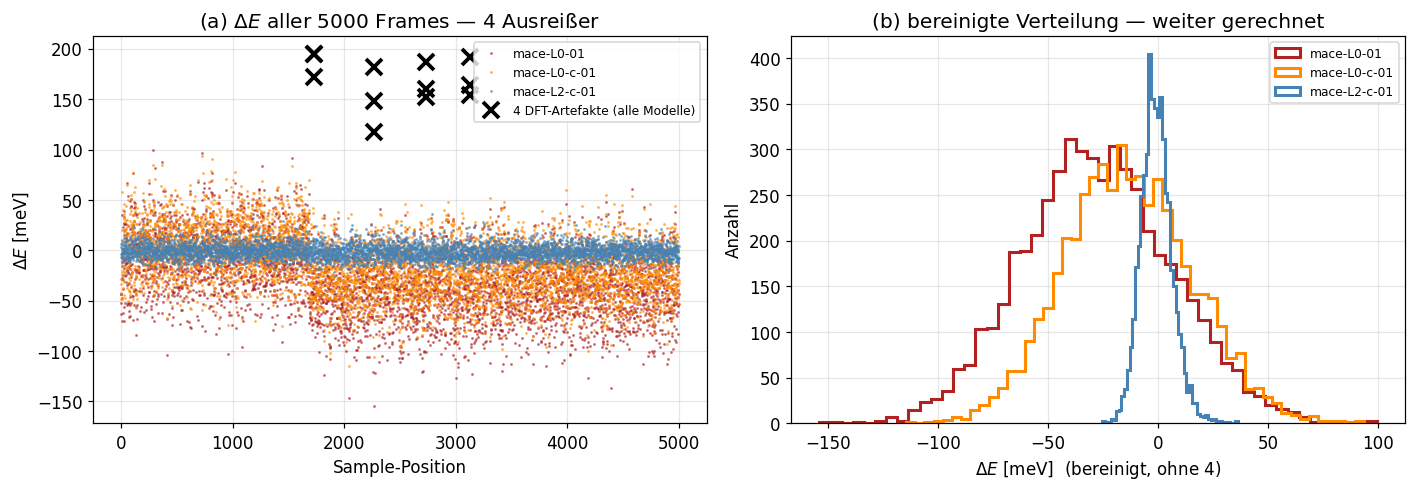

In [3]:
# --- Grosser Datensatz n=5000 (dieselben Strukturen fuer alle Modelle) ---
MODELS_FULL = {
    "mace-L0-01":   "single_mace-L0-01_testfull_n5000.npz",
    "mace-L0-c-01": "single_mace-L0-c-01_testfull_n5000.npz",
    "mace-L2-c-01": "single_mace-L2-c-01_testfull_n5000.npz",
}
COL_FULL = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "mace-L2-c-01": "steelblue"}

# 4 fehlerhafte DFT-Frames ueber die praezise L2-Referenz identifizieren (dE > 0.1 eV,
# klar abgesetzt vom Rest). Gilt fuer ALLE Modelle, da gleiche Strukturen.
_e_dft, _e_l2 = load_energies(CACHE / MODELS_FULL["mace-L2-c-01"])
_dE_l2 = _e_dft - _e_l2
BAD = _dE_l2 > 0.10                                  # Maske ueber die 5000
print(f"{BAD.sum()} Ausreisser (dE > 0.1 eV) identifiziert -> ausgeschlossen "
      f"(verbleibend: {(~BAD).sum()} Frames)\n")

# Beleg: an den 4 Frames liegen ALLE Modelle nahezu gleich weit daneben (-> DFT, nicht Modell)
_bad_pos = np.where(BAD)[0]
_idx = np.load(CACHE / MODELS_FULL["mace-L2-c-01"])["idx"][_bad_pos]
print("dE [eV] an den Ausreissern — alle Modelle nahezu gleich falsch:")
print(f"  {'Frame':>7}" + "".join(f"{m:>14}" for m in MODELS_FULL))
for r, fr in enumerate(_idx):
    row = []
    for m in MODELS_FULL:
        ed, em = load_energies(CACHE / MODELS_FULL[m])
        row.append(ed[_bad_pos[r]] - em[_bad_pos[r]])
    print(f"  {fr:>7}" + "".join(f"{v:>14.4f}" for v in row))

def load_full(name, clean=True):
    # e_dft, e_mace des n5000-Satzes; clean=True entfernt die 4 DFT-Artefakte
    e_dft, e_mace = load_energies(CACHE / MODELS_FULL[name])
    m = ~BAD if clean else np.ones(e_dft.size, bool)
    return e_dft[m], e_mace[m]

# --- Ausreisser einmal zeigen ---
import matplotlib.pyplot as plt
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13, 4.6))
for m, col in COL_FULL.items():
    e_dft, e_mace = load_energies(CACHE / MODELS_FULL[m])
    ax.plot(np.arange(e_dft.size), (e_dft - e_mace) * 1000, ".", ms=2, alpha=0.5,
            color=col, label=m)
for k, m in enumerate(MODELS_FULL):                 # Ausreisser ALLER Modelle markieren
    ed, em = load_energies(CACHE / MODELS_FULL[m])
    ax.plot(np.where(BAD)[0], (ed - em)[BAD] * 1000, "x", ms=11, mew=2.5, color="k",
            label=f"{BAD.sum()} DFT-Artefakte (alle Modelle)" if k == 0 else None)
ax.set_xlabel("Sample-Position"); ax.set_ylabel("$\\Delta E$ [meV]")
ax.set_title("(a) $\\Delta E$ aller 5000 Frames — 4 Ausreißer"); ax.legend(fontsize=8)
ax.grid(alpha=0.3)
for m, col in COL_FULL.items():
    e_dft, e_mace = load_full(m)                     # bereinigt
    bx.hist((e_dft - e_mace) * 1000, bins=50, histtype="step", lw=2, color=col, label=m)
bx.set_xlabel("$\\Delta E$ [meV]  (bereinigt, ohne 4)"); bx.set_ylabel("Anzahl")
bx.set_title("(b) bereinigte Verteilung — weiter gerechnet"); bx.legend(fontsize=8)
bx.grid(alpha=0.3)
plt.tight_layout(); plt.show()

<a id="1"></a>
## 1. Fragestellung und Überblick

### 1.1 Der Reweighting-Kontext

Eine MD auf einem MACE-Potential erzeugt Konfigurationen $R_i$. Thermodynamische
Mittelwerte, die man eigentlich auf DFT-Niveau haben will, lassen sich aus dieser MD
per **Reweighting** gewinnen:

$$\langle A\rangle_\text{DFT} \;\approx\; \frac{\sum_i A_i\,w_i}{\sum_i w_i},
\qquad w_i = e^{-\beta\,(E_\text{DFT}(R_i)-E_\text{MACE}(R_i))} = e^{-\beta\,\Delta E_i}.$$

Jedes Gewicht $w_i$ verlangt eine DFT-Einzelpunktrechnung $E_\text{DFT}(R_i)$. Das ist
der teure Schritt.

Wie viel die Reweighting-Summe statistisch wert ist, misst die **effektive
Stichprobengröße** (Kish):

$$N_\text{eff} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}, \qquad 1 \le N_\text{eff} \le n.$$

Sind alle Gewichte gleich, ist $N_\text{eff}=n$; dominiert ein einzelnes Gewicht, ist
$N_\text{eff}=1$ — man hätte $n$ DFT-Rechnungen bezahlt und statistisch den Wert von
*einer*.

### 1.2 Die Qualitätsfrage

Der statistische Fehler eines reweighteten Mittelwerts skaliert wie
$1/\sqrt{N_\text{eff}}$. Das Verhältnis $N_\text{eff}/n$ ist damit direkt der Faktor, um
den das Reweighting die Fehlerbalken aufbläht:

$$\frac{\sigma_\text{reweighted}}{\sigma_\text{ideal}} = \frac{1}{\sqrt{N_\text{eff}/n}}.$$

Das Effizienzkriterium ist eine Schwelle $R$:

$$\frac{N_\text{eff}}{n} \;\ge\; R \qquad (\text{z.B. } R=0.8 \;\Leftrightarrow\; \text{höchstens }12\,\%\text{ breitere Fehlerbalken}).$$

$R$ ist ein **freier Parameter** des Verfahrens — welchen Wert er haben soll, ist nicht
Gegenstand dieses Notebooks.

Die folgende Abbildung zeigt den Unterschied zwischen einem gutartigen und einem
entarteten Reweighting an den realen Gewichtsverteilungen.

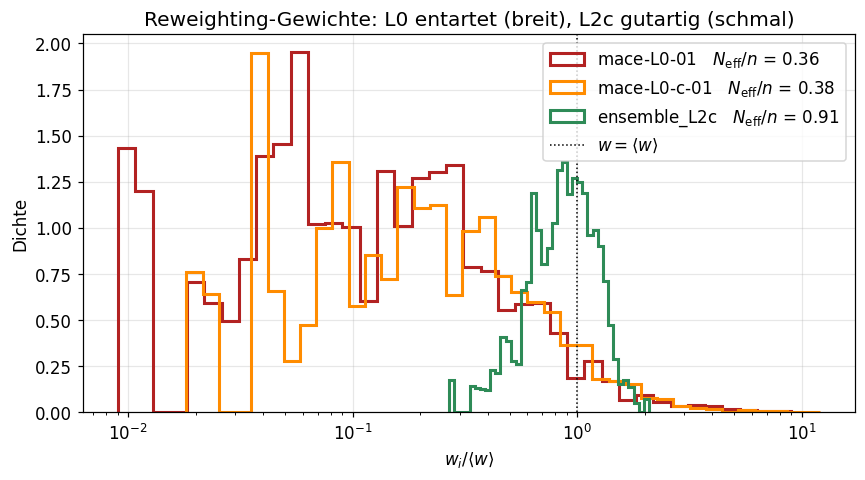

In [4]:
# Motivation: gutartige vs. entartete Gewichtsverteilung (reale Daten)
import numpy as np
import matplotlib.pyplot as plt

show = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange",
        "ensemble_L2c": "seagreen"}
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, col in show.items():
    e_dft, e_mace = load_energies(CACHE / MODELS[m])
    w = reweighting_weights(e_dft, e_mace, beta); w = w / w.mean()
    ne = effective_sample_size(w) / w.size
    wn = w[w > 0]
    bins = np.logspace(np.log10(wn.min()), np.log10(wn.max()), 40)
    ax.hist(wn, bins=bins, density=True, histtype="step", lw=2, color=col,
            label=f"{m}   $N_\\mathrm{{eff}}/n$ = {ne:.2f}")
ax.axvline(1.0, color="k", ls=":", lw=1, label="$w=\\langle w\\rangle$")
ax.set_xscale("log")
ax.set_xlabel("$w_i / \\langle w\\rangle$"); ax.set_ylabel("Dichte")
ax.set_title("Reweighting-Gewichte: L0 entartet (breit), L2c gutartig (schmal)")
ax.legend(); plt.tight_layout(); plt.show()

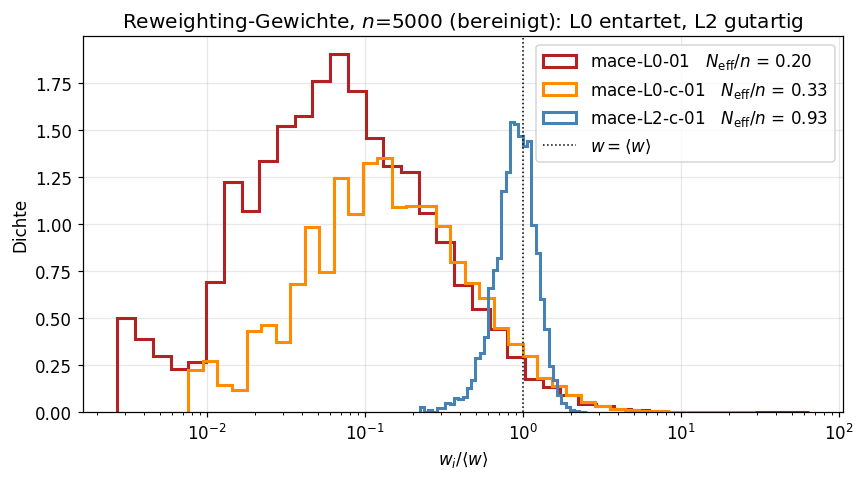

In [5]:
# dasselbe auf dem grossen Satz (n=5000, bereinigt) — SEPARATER Plot neben dem 400er
show_full = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange",
             "mace-L2-c-01": "steelblue"}
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, col in show_full.items():
    e_dft, e_mace = load_full(m)                     # bereinigt (ohne die 4 DFT-Artefakte)
    w = reweighting_weights(e_dft, e_mace, beta); w = w / w.mean()
    ne = effective_sample_size(w) / w.size
    wn = w[w > 0]
    bins = np.logspace(np.log10(wn.min()), np.log10(wn.max()), 40)
    ax.hist(wn, bins=bins, density=True, histtype="step", lw=2, color=col,
            label=f"{m}   $N_\\mathrm{{eff}}/n$ = {ne:.2f}")
ax.axvline(1.0, color="k", ls=":", lw=1, label="$w=\\langle w\\rangle$")
ax.set_xscale("log")
ax.set_xlabel("$w_i / \\langle w\\rangle$"); ax.set_ylabel("Dichte")
ax.set_title("Reweighting-Gewichte, $n$=5000 (bereinigt): L0 entartet, L2 gutartig")
ax.legend(); plt.tight_layout(); plt.show()

Die **L0**-Verteilungen sind über mehrere Größenordnungen gespreizt — wenige Frames
tragen fast das ganze Gewicht, $N_\text{eff}/n \approx 0.36$. Die **L2c**-Referenz ist
scharf um 1 konzentriert, $N_\text{eff}/n \approx 0.91$. Für die L0-Modelle ist das
Reweighting also statistisch schwach — und genau das möchte man **früh** erkennen.

### 1.3 Warum gerade L0 — die Kostenlogik

Entscheidend ist, welcher Teil der Rechnung teuer ist:

| Modell | MD | DFT | teurer Teil | frühes DFT-Abbrechen |
|---|---|---|---|---|
| **L2** (groß, langsam) | hoch | mittel | MD | bringt wenig |
| **L0** (klein, schnell) | niedrig | mittel | **DFT** | **spart real** |

Bei **L0** ist die MD billig, also dominieren die DFT-Einzelpunkte die Kosten. Man rechnet
sie **nacheinander auf Frames der laufenden MACE-MD** und erkennt früh, ob das Reweighting
tragen wird; ist es aussichtslos, bricht man ab und spart den Großteil der DFT-Kampagne. Das
ist der von Tobi genannte Anwendungsfall. Der „Testsatz“ wird dabei nicht separat erzeugt, sondern **Stück für Stück
während der MD gebaut**; die $k$ Frames sind ein wachsender Anfang der Produktionsdaten. Weil sie aus der MD selbst stammen, ist $p_\text{test}=p_\text{MACE}$; ein Reweighting
zwischen Verteilungen entfällt (§3).

> $n=5000$ (die Zahl der Reweighting-Frames) liegt durch das Volumen-Resampling fest.
> Reduziert wird **nicht** dieses finale $n$, sondern der DFT-Aufwand für die
> **Entscheidung**, ob sich der volle Lauf überhaupt lohnt.

### 1.4 Die Kernidee

$N_\text{eff}$ ist eine Funktion der $\Delta E_i$. Ihre Verteilung fasst **ein einziger
dimensionsloser Parameter** zusammen:

$$\boxed{\,c = \beta\cdot\mathrm{std}(\Delta E)\,}$$

Unter mild(en) Annahmen (Abschnitt 2) gilt $N_\text{eff}/n \approx e^{-c^2}$, das
Effizienzkriterium wird also zu einer **harten Schranke an $c$**:

$$\frac{N_\text{eff}}{n} \ge R \quad\Longleftrightarrow\quad c \le c_\text{max} = \sqrt{-\ln R}.$$

$c$ konvergiert schnell mit der Zahl der gerechneten DFT-Punkte $k$. Deshalb steht das
Urteil **PASS / FAIL** oft schon nach wenigen Punkten fest — das ist die Auszahlung für
L0. Die Konvergenz von $c$ (und der Formkorrekturen $\gamma_1,\gamma_2$) bei kleinem $k$
ist damit die zentrale Größe dieses Notebooks.

### 1.5 Was die vorhandenen Daten testen — und was nicht

Der Workflow wird hier auf einem **festen** DFT-Datensatz getestet (Strukturen aus einer
L2-MD, mit DFT-Referenz). Zwei Fragen sind streng zu trennen:

- **Stabilität der Methode** — konvergieren die Schätzer, entscheidet die Regel korrekt und
  früh, wie hoch ist die Fehlentscheidungsrate. Das hängt nur von der Folge der $\Delta E$-Werte
  ab; woher die Strukturen stammen, ist dem Schätzer egal. **Auf diesen Daten voll prüfbar.**
- **Güte eines konkreten L0-Modells** — welches $N_\text{eff}$ ein echter L0-Produktionslauf
  hätte. Das verlangt Strukturen aus der L0-MD ($p_\text{L0}$); die vorliegenden stammen aber
  aus einer L2-MD, die L0-MD hätte andere besucht. **Auf diesen Daten nicht bestimmbar** — und
  auch nicht durch Umgewichtung reparierbar (Fehlerfortpflanzung, §3).

**Konsequenz.** Dieses Notebook validiert die **Methodik** — nicht die Modellgüte eines
bestimmten L0-Laufs. Die $N_\text{eff}$-Zahlen der L0-Modelle hier zeigen, dass die Maschine
sie korrekt und früh als (un)tauglich einstuft; sie sind **keine** Prognose für einen realen
L0-Produktionslauf. Dessen $N_\text{eff}$ ergibt sich erst aus dem Lauf selbst, in dem
Screening und Messung zusammenfallen (§3) — dann ist es eine direkte Messung, keine
Vorhersage über eine Verteilungslücke hinweg.

### 1.6 Fahrplan

- **§2–3** — Formalismus (Kumulantenentwicklung) und die zwei Annahmen A1–A2.
- **§4–5** — die $\Delta E$-Verteilung und die drei Diagnosegrößen $c$, $\hat k$, $N_\text{eff}$.
- **§6** — Konvergenz der Momente und die daraus folgenden Standardfehler.
- **§7** — der sequenzielle Workflow: die einseitige Abbruchregel, wie früh das L0-Urteil
  steht, in welchem Regime sie trägt und wie viel DFT sie spart.
- **§8–10** — Existenz von $N_\text{eff}$, Verifikation gegen bekannte Wahrheit, Grenzen
  (Abdeckung, iid).
- **§11** — Zusammenfassung und offene Fragen.

<a id="2"></a>
## 2. Der Formalismus: $c$ und die Kumulantenentwicklung

Ziel dieses Abschnitts: $N_\text{eff}/n$ auf **einen** dimensionslosen Parameter
zurückführen und die dabei gemachten Annahmen exakt benennen. Der Grundgedanke —
$\beta\,\sigma_{\Delta U}$ als Konvergenzmaß eines exponentiellen Mittels — stammt aus
der Freie-Energie-Störungstheorie [Zwanzig 1954] und der Phasenraum-Überlapp-Analyse
[Wu & Kofke 2005]; neu ist hier die systematische Formkorrektur über die Kumulanten.

### 2.1 $N_\text{eff}$ als Momentverhältnis

Die effektive Stichprobengröße [Kish 1965] ist

$$N_\text{eff} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}.$$

Teilt man Zähler und Nenner durch $n^2$ bzw. $n$ und nutzt das Gesetz der großen Zahlen,
konvergieren die Stichprobenmittel gegen Erwartungswerte:

$$\frac{N_\text{eff}}{n} = \frac{\bar w^{\,2}}{\overline{w^2}}
\;\xrightarrow[n\to\infty]{}\; \frac{E[w]^2}{E[w^2]}. \tag{2.1}$$

> **Annahme (i):** der Grenzübergang $n\to\infty$. Auf endlich vielen vorliegenden
> Gewichten ist $N_\text{eff}/n = (\sum w)^2/(n\sum w^2)$ dagegen **exakt** — eine reine
> Funktion der Gewichte, ohne Modell. Gleichung (2.1) wird nur zum *Extrapolieren*
> gebraucht.

### 2.2 Der Parameter $c$

Schreibe $\Delta E = \mu + \sigma z$ mit standardisiertem $z$ ($E[z]=0$, $\mathrm{Var}(z)=1$)
und definiere

$$c = \beta\,\sigma = \beta\cdot\mathrm{std}(\Delta E).$$

Jedes Gewicht faktorisiert damit in einen **für alle Frames gleichen** Vorfaktor und einen
frame-abhängigen Rest:

$$w_i = e^{-\beta\Delta E_i}
     = \underbrace{e^{-\beta\mu}}_{\text{konstant in }i}\cdot
       \underbrace{e^{-c z_i}}_{=\,v_i,\ \text{trägt Index }i}. \tag{2.2}$$

**Der Offset kürzt sich schon in der endlichen Summenform heraus** — ohne Erwartungswert,
ohne Grenzübergang. In die Kish-Formel eingesetzt:

$$\frac{N_\text{eff}}{n}
= \frac{\left(\sum_i w_i\right)^2}{n\sum_i w_i^2}
= \frac{\left(\sum_i e^{-\beta\mu}\,v_i\right)^2}{n\sum_i e^{-2\beta\mu}\,v_i^2}.$$

Weil $e^{-\beta\mu}$ **nicht von $i$ abhängt**, ist es in jedem Summanden derselbe Faktor
und lässt sich vor die Summe ziehen; $v_i=e^{-cz_i}$ dagegen ist für jeden Frame anders und
bleibt mit seinem Index **in** der Summe:

$$= \frac{\big(e^{-\beta\mu}\big)^2\left(\sum_i v_i\right)^2}{e^{-2\beta\mu}\;n\sum_i v_i^2}
= \frac{e^{-2\beta\mu}}{e^{-2\beta\mu}}\cdot\frac{\left(\sum_i v_i\right)^2}{n\sum_i v_i^2}
= \frac{\left(\sum_i v_i\right)^2}{n\sum_i v_i^2}.$$

Der Faktor $e^{-2\beta\mu}$ steht identisch in Zähler und Nenner und fällt weg — **exakt,
für jede endliche Stichprobe, annahmefrei.**

> **Warum die $v_i$ den Index behalten und $e^{-\beta\mu}$ nicht.**
> $\mu=\langle\Delta E\rangle$ ist eine *einzige Zahl* für den ganzen Datensatz, also in
> $e^{-\beta\mu}$ für jeden Frame gleich — ein gemeinsamer Faktor, der aus der Summe
> herausgezogen werden kann. $z_i=(\Delta E_i-\mu)/\sigma$ ist dagegen der
> *standardisierte Wert des Frames $i$* und variiert von Frame zu Frame; $v_i=e^{-cz_i}$
> trägt diese Variation und muss deshalb mit dem Index **im** Summanden bleiben.

**Prinzip: Skaleninvarianz.** Multipliziert man alle Gewichte mit derselben Konstante
$\lambda$, ändert sich

$$\frac{\big(\sum_i \lambda w_i\big)^2}{\sum_i (\lambda w_i)^2}
= \frac{\lambda^2\big(\sum_i w_i\big)^2}{\lambda^2\sum_i w_i^2}
= \frac{\big(\sum_i w_i\big)^2}{\sum_i w_i^2}$$

nicht — $\lambda^2$ kürzt sich stets. Ein additiver Energie-Offset ist genau so ein Faktor
($\lambda=e^{-\beta\mu}$) und damit für $N_\text{eff}$ unsichtbar. Dasselbe Argument gilt
für den Variationskoeffizienten $\mathrm{CV}=\mathrm{std}(w)/\langle w\rangle$ und den
Tail-Index $\hat k$.

**Im Grenzwert** $n\to\infty$ (Gl. 2.1) werden die Summenmittel zu Erwartungswerten der
standardisierten Variable:

$$\frac{N_\text{eff}}{n} \;\xrightarrow[n\to\infty]{}\; \frac{E[e^{-c z}]^2}{E[e^{-2c z}]}. \tag{2.3}$$

$N_\text{eff}/n$ hängt also nur von der **Form** der Verteilung (über $z$) und der
**Skala** $c$ ab, nicht vom Mittelwert. Dass genau **ein** Parameter $c$ übrig bleibt,
erzwingt schon die Dimensionsanalyse ($\beta\Delta E$ ist dimensionslos).

### 2.3 Die kumulantenerzeugende Funktion

**Warum dieses Werkzeug.** Der Ausdruck (2.3) enthält nur noch Größen der Form
$E[e^{t z}]$ — das ist die **momenterzeugende Funktion** (MGF) $M(t)=E[e^{t z}]$,
ausgewertet an $t=-c$ und $t=-2c$. Ihr Logarithmus,

$$K(t) = \log M(t) = \log E[e^{t z}],$$

heißt **kumulantenerzeugende Funktion** (CGF). Der Logarithmus ist der entscheidende
Schritt: er verwandelt das Verhältnis von Momenten in (2.3) in eine **Differenz**, und
seine Taylor-Koeffizienten sind gerade die Zahlen, die die Form der Verteilung beschreiben.

**Kumulanten statt Momente.** Entwickelt man $K$ um $t=0$,

$$K(t) = \sum_{m\ge 1}\frac{\kappa_m}{m!}\,t^m,$$

so sind die Koeffizienten $\kappa_m$ die **Kumulanten** von $z$ — nicht die (Roh-)Momente.
Die niedrigsten hängen mit den zentralen Momenten zusammen:

$$\kappa_1 = E[z], \quad \kappa_2 = \mathrm{Var}(z), \quad
  \kappa_3 = E[(z-\bar z)^3], \quad \kappa_4 = E[(z-\bar z)^4] - 3\,\kappa_2^2.$$

Für die **standardisierte** Variable $z$ (Mittel 0, Varianz 1, §2.2) wird das besonders
einfach:

$$\kappa_1 = 0,\quad \kappa_2 = 1,\quad \kappa_3 = \gamma_1\ (\text{Schiefe}),\quad
  \kappa_4 = \gamma_2\ (\text{Exzess-Kurtosis}),$$

also

$$K(t) = \tfrac{1}{2}t^2 + \tfrac{\gamma_1}{6}t^3 + \tfrac{\gamma_2}{24}t^4 + \dots$$

**Zwei Eigenschaften, die den Formalismus tragen:**

- Für eine **Normalverteilung** sind alle $\kappa_m$ mit $m\ge 3$ exakt null, d.h.
  $K(t)=\tfrac12 t^2$. Das ist der tiefere Grund, warum der Gauß-Fall gleich nur $-c^2$
  liefert (§2.4): jede Abweichung von Gauß steckt ausschließlich in $\gamma_1,\gamma_2,\dots$
- Kumulanten sind **additiv** für Summen unabhängiger Beiträge. Weil $\Delta E$ eine Summe
  lokaler Beiträge über die Atome/Moleküle ist, steuert diese Eigenschaft später die
  Skalierung mit der Systemgröße (§3).

> **Wessen Verteilung ist das?** $K$ ist die CGF von $z$, also der **standardisierten
> $\Delta E$-Verteilung** — *nicht* der Gewichtsverteilung $w$. Man beachte
> $\log w_i = -\beta\mu - c\,z_i$: $\log w$ ist eine **affine** Funktion von $z$, die
> Kumulanten von $z$ sind also (bis auf Ort und Skala) die von $\log w$ — aber **nicht**
> die von $w$ selbst. Die $w$-Momente entstehen erst durch **Auswertung** von $K$ an festen
> Stellen (gleich unten). Kurz: $\gamma_1,\gamma_2,c$ beschreiben die **Form** von
> $\Delta E$; aus $w$ kommen die **Momente** (hier) und der **Tail** ($\hat k$, §8).

**Einsetzen in (2.3).** Aus der Definition $K(t)=\log E[e^{t z}]$ folgt unmittelbar
$E[e^{t z}] = e^{K(t)}$. An den beiden benötigten Stellen:

$$E[e^{-c z}] = e^{K(-c)}, \qquad E[e^{-2c z}] = e^{K(-2c)}.$$

Damit wird das Verhältnis (2.3) zu einer Differenz von CGF-Werten — der Logarithmus macht
aus dem Quadrat einen Faktor 2 und aus dem Bruch ein Minuszeichen:

$$\log\frac{N_\text{eff}}{n} = \log\frac{E[e^{-c z}]^2}{E[e^{-2c z}]}
= 2\,K(-c) - K(-2c). \tag{2.4}$$

Dieser Ausdruck ist **exakt** — keine Näherung, keine Gauß-Annahme —, solange $K(-c)$ und
$K(-2c)$ **existieren**, d.h. $E[e^{-c z}]$ und $E[e^{-2c z}]$ (äquivalent $E[w]$ und
$E[w^2]$) endlich sind. Genau diese Existenz prüft §8 über den Tail-Index $\hat k$.

### 2.4 Die Entwicklung und der Gauß-Term

Setzt man die Reihe für $K$ in (2.4) ein, so heben sich Zähler- und Nenner-Offset und man
erhält mit $(-2c)^m = (-1)^m 2^m c^m$:

$$\log\frac{N_\text{eff}}{n}
= \sum_{m\ge 2}\frac{\kappa_m}{m!}\,(-1)^m\,(2 - 2^m)\,c^m
= -c^2 + \gamma_1 c^3 - \tfrac{7}{12}\gamma_2 c^4 + O(c^5). \tag{2.5}$$

(Man prüfe die Vorfaktoren: $m=2$ gibt $(2-4)/2!=-1$; $m=3$ gibt $-(2-8)/3!=+1$; $m=4$
gibt $(2-16)/4!=-7/12$.)

**Gauß-Grenzfall.** Behält man nur $m=2$, so ist

$$\frac{N_\text{eff}}{n} \approx e^{-c^2}. \tag{2.6}$$

Für normalverteiltes $\Delta E$ ist (2.6) exakt (alle höheren $\kappa_m=0$). Das ist genau
die Kenngröße $\beta\sigma_{\Delta U}$ der FEP-Konvergenz [Zwanzig 1954] und äquivalent zu
`predicted_neff_gauss` im Code, da $c^2 = \beta^2\mathrm{Var}(\Delta E)$.

### 2.5 Konvergenz — der effektive Parameter ist $2c$

In (2.4) wird $K$ auch an $t=-2c$ ausgewertet. Der $m$-te Term skaliert daher wie
$\sim (2c)^m/m!$, nicht $c^m/m!$ — **der effektive Entwicklungsparameter ist $2c$**. Eine
brauchbare Restabschätzung ist

$$R_5 \approx \frac{(2c)^5}{5!}. \tag{2.7}$$

> **Annahme (ii) — A1 (§3.1):** die Reihe (2.5) konvergiert bei diesem $c$. Prüfbar über (2.7):
> ist $R_5\ll 1$, trägt die Entwicklung; ist $R_5=O(1)$, ist sie wertlos, und man nimmt
> den **exakten** Kish-Wert (der immer existiert, solange $E[w^2]<\infty$).

Die folgende Zelle prüft das an den realen Daten.

In [6]:
# Verifikation der Entwicklung (2.5) gegen den exakten Kish-Wert — 400 und 5000 getrennt
import numpy as np
from math import factorial

def expansion_terms(e_dft, e_mace):
    dE = e_dft - e_mace
    s = dE.std(ddof=1); u = dE - dE.mean()
    c  = beta * s
    g1 = float((u**3).mean() / s**3)
    g2 = float((u**4).mean() / s**4 - 3.0)
    kish  = effective_sample_size(reweighting_weights(e_dft, e_mace, beta)) / dE.size
    gauss = np.exp(-c**2)                                  # (2.6), nur -c^2
    three = np.exp(-c**2 + g1*c**3 - 7/12*g2*c**4)         # (2.5), 3 Terme
    R5    = (2*c)**5 / factorial(5)                        # (2.7)
    return c, g1, g2, kish, gauss, three, R5

def print_table(title, items):
    print(title)
    print(f"{'Modell':<14}{'c':>7}{'gamma1':>8}{'Kish':>8}{'Gauss':>8}"
          f"{'3-Term':>8}{'Rest 2c^5/5!':>14}{'  A2?':>7}")
    print("-" * 74)
    for m, (e_dft, e_mace) in items:
        c, g1, g2, kish, ga, th, R5 = expansion_terms(e_dft, e_mace)
        ok = "traegt" if R5 < 0.05 else "DIVERGENT"
        print(f"{m:<14}{c:>7.3f}{g1:>+8.3f}{kish:>8.3f}{ga:>8.3f}"
              f"{th:>8.3f}{R5:>14.3f}   {ok}")

print_table("n = 400  (testbig):",
            [(m, load_energies(CACHE / MODELS[m])) for m in MODELS])
print()
print_table("n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):",
            [(m, load_full(m)) for m in MODELS_FULL])

n = 400  (testbig):
Modell              c  gamma1    Kish   Gauss  3-Term  Rest 2c^5/5!    A2?
--------------------------------------------------------------------------
mace-L0-01      1.238  +0.247   0.361   0.216   0.304         0.774   DIVERGENT
mace-L0-c-01    1.079  +0.207   0.382   0.312   0.362         0.391   DIVERGENT
ensemble_L2c    0.327  +0.501   0.912   0.899   0.912         0.001   traegt
mace-L2-c-01    0.335  +0.413   0.907   0.894   0.907         0.001   traegt

n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):
Modell              c  gamma1    Kish   Gauss  3-Term  Rest 2c^5/5!    A2?
--------------------------------------------------------------------------
mace-L0-01      1.340  +0.090   0.196   0.166   0.228         1.152   DIVERGENT
mace-L0-c-01    1.146  +0.127   0.327   0.269   0.347         0.527   DIVERGENT
mace-L2-c-01    0.283  +0.422   0.929   0.923   0.929         0.000   traegt


**Lesart.** Für die **L2c**-Referenz ($c=0.33$) ist der Rest $\approx 0.001$: die
Entwicklung trägt, die 3-Term-Prognose trifft den exakten Kish-Wert auf $<0.1\,\%$. Für
die **L0**-Modelle ($c\approx1.1$–$1.2$) ist der Rest $0.4$–$0.8$: die Reihe divergiert,
die Polynomprognose liegt 6–17 % daneben.

Das ist **kein Problem für die Entscheidung** (§7): das FAIL-Urteil hängt an $c$ gegen
die Schwelle, nicht am genauen $N_\text{eff}$-Wert — und $c$ selbst ist robust (§7). Wo
man doch die Zahl braucht, nimmt man den exakten Kish-Wert.

### 2.6 Die Entscheidungsschranke für $c$

Das Effizienzkriterium $N_\text{eff}/n \ge R$ lässt sich mit (2.4)/(2.5) direkt in eine
**obere Schranke an $c$** übersetzen.

**Gauß-Fall.** Mit $N_\text{eff}/n \approx e^{-c^2}$:

$$e^{-c^2} \ge R
\;\Longleftrightarrow\; -c^2 \ge \ln R
\;\Longleftrightarrow\; c^2 \le -\ln R
\;\Longleftrightarrow\; c \le c_\text{max} = \sqrt{-\ln R}. \tag{2.8}$$

($\ln R < 0$ für $R<1$, die Wurzel ist also reell.) Für $R=0.8$ ist $c_\text{max}=0.472$.

**Mit Formkorrektur.** Aus der vollen Entwicklung (2.5), $\log(N_\text{eff}/n) =
-c^2+\gamma_1 c^3-\tfrac{7}{12}\gamma_2 c^4$, wird das Kriterium $\log(N_\text{eff}/n)\ge\ln R$
zu einer **Quartik**:

$$c^2 - \gamma_1 c^3 + \tfrac{7}{12}\gamma_2 c^4 \;\le\; -\ln R. \tag{2.9}$$

Die kleinste positive Lösung $c_\text{max}$ findet man numerisch (Nullstellensuche, `brentq`).
Bei **Rechtsschiefe** ($\gamma_1>0$) liegt sie **höher** als die Gauß-Schranke — man darf mehr
$c$ zulassen. Die Gauß-Version ist also **konservativ** (lehnt im Zweifel eher ab, nie
fälschlich an); bei Linksschiefe kehrt sich das um. Die Konsequenz — die *Falsch-FAIL-Zone*
zwischen beiden Schranken — behandelt §7.

**Selbstkonsistenz — die Schranke erbt A1.** Die Quartik (2.9) stammt aus der *abgeschnittenen*
Reihe (2.5) und setzt daher deren **Konvergenz** voraus (A1, §3.1) — genau an der Stelle
$c_\text{max}$. Sie ist nur gültig, wo der Restterm dort klein ist,
$R_5\approx(2c_\text{max})^5/5!\ll 1$. Für die relevanten $R\in[0.7,0.9]$ liegt $c_\text{max}$
bei $0.35$–$0.68$, der Rest also unter $0.04$ — die schiefe-korrigierte Schranke ist dort
selbstkonsistent. Bei sehr kleinem $R$ (große Toleranz) wächst $c_\text{max}$ so weit, dass die
Reihe nicht mehr trägt; dann braucht man sie auch nicht: das Kriterium $N_\text{eff}/n\ge R$ ist
über den **exakten** Kish-Wert direkt prüfbar (annahmefrei, §2.1), und die exakte Schranke in
$c$ folgt aus $2K(-c)-K(-2c)=\ln R$ ohne jede Reihe. Der reine **Gauß**-Term (2.8) ist davon
unberührt — führender Term, kein Reihenschluss, und immer als (unter Rechtsschiefe konservative)
Formel verfügbar.

In [7]:
# Verifikation der Schranke c_max (Gauss vs. exakte Quartik)
import numpy as np
from scipy.optimize import brentq

e_dft, e_mace = load_energies(CACHE / MODELS["ensemble_L2c"])
dE = e_dft - e_mace
s = dE.std(ddof=1); u = dE - dE.mean()
g1 = float((u**3).mean() / s**3); g2 = float((u**4).mean() / s**4 - 3.0)

cmax_gauss = lambda R: np.sqrt(-np.log(R))                                 # (2.8)
cmax_exact = lambda R: brentq(lambda c: c**2 - g1*c**3 + 7/12*g2*c**4      # (2.9)
                              + np.log(R), 1e-4, 3.0)
R5 = lambda c: (2*c)**5 / 120.0                    # Restterm an c_max (Selbstkonsistenz)

print(f"gamma1 = {g1:+.3f},  gamma2 = {g2:+.3f}\n")
print(f"{'R':>5}{'c_max Gauss':>13}{'c_max exakt':>13}{'R5(c_max)':>12}")
for R in (0.7, 0.8, 0.9):
    ce = cmax_exact(R)
    print(f"{R:>5.1f}{cmax_gauss(R):>13.3f}{ce:>13.3f}{R5(ce):>12.3f}")

gamma1 = +0.501,  gamma2 = +0.390

    R  c_max Gauss  c_max exakt   R5(c_max)
  0.7        0.597        0.683       0.040
  0.8        0.472        0.529       0.011
  0.9        0.325        0.352       0.001


**Zur Nullstellensuche (`brentq`).** Die Quartik (2.9) lässt sich nicht geschlossen nach $c$
auflösen; `brentq` findet die Wurzel numerisch in einem Intervall $[a,b]$, an dessen Rändern
$f(c)=c^2-\gamma_1 c^3+\tfrac{7}{12}\gamma_2 c^4+\ln R$ das **Vorzeichen wechselt** ($f(a)\,f(b)<0$).

*Warum es einen Wechsel gibt.* Man kann $f$ schreiben als

$$f(c) = \ln R - \log\frac{N_\text{eff}}{n} = \log\!\left(\frac{R}{N_\text{eff}/n}\right),$$

also als Log-Quotient aus Ziel $R$ und erreichter Effizienz. Sein Vorzeichen **ist** die
Entscheidung: $f<0 \Leftrightarrow N_\text{eff}/n>R$ (PASS), $f>0 \Leftrightarrow$ FAIL. Bei
$c=0$ ist $N_\text{eff}/n=1$ (PASS, $f=\ln R<0$), bei großem $c$ geht $N_\text{eff}/n\to 0$
(FAIL, $f>0$) — dazwischen genau ein Nulldurchgang, die Schwelle $c_\text{max}$.

*Wie es funktioniert.* `brentq` kombiniert **Bisektion** (halbiert das Intervall und behält die
Hälfte mit dem Vorzeichenwechsel — garantiert, aber linear langsam) mit **Interpolation**
(Sekante bzw. inverse Parabel durch die letzten Punkte — schnell, aber ohne Sicherung riskant).
Eine Schutzregel akzeptiert den schnellen Schritt nur, wenn er im Intervall bleibt und dieses
ausreichend verkleinert; sonst wird bisektiert. So ist die Konvergenz meist superlinear, aber
**nie schlechter als Bisektion** — die Wurzel geht nie aus dem Bracket verloren.

*Das Intervall $[10^{-4}, 3]$* ist das Suchfenster für $c$: die Untergrenze knapp über dem
physikalischen Minimum $0$, die Obergrenze weit jenseits jedes brauchbaren Modells
($c=3 \Leftrightarrow N_\text{eff}/n\approx 10^{-4}$). Für jedes sinnvolle $R$ liegt
$c_\text{max}$ sicher dazwischen, und die Vorzeichen an den Rändern stimmen. Weil das Fenster
nahe $0$ beginnt, wird die **erste** (kleinste) Nullstelle gefunden — genau das obere Ende des
PASS-Intervalls $[0, c_\text{max}]$.

**Lesart.** Rechtsschiefe hebt die Schranke um ~12 % (R=0.8: 0.472 → 0.529), und der
Restterm an $c_\text{max}$ bleibt klein ($\le 0.04$) — die korrigierte Schranke ist
selbstkonsistent. Für die **Entscheidung** genügt schon die Gauß-Schranke, weil die L0-Modelle
mit $c\approx1.1$–$1.2$ ohnehin **weit** darüber liegen; die Korrektur zählt nur bei einem
Modell nahe der Schwelle (§7).

### 2.7 Literatureinordnung

Der $c$-Formalismus ist **nicht neu**, sondern die auf den Modellfehler übertragene Form
etablierter Kriterien:

- **[Zwanzig 1954]** R. W. Zwanzig, *J. Chem. Phys.* **22**, 1420 — Freie-Energie-
  Störungstheorie; $\beta\sigma_{\Delta U}$ als Konvergenzmaß des exponentiellen Mittels.
- **[Kish 1965]** L. Kish, *Survey Sampling*, Wiley — die effektive Stichprobengröße
  $N_\text{eff}=(\sum w)^2/\sum w^2$.
- **[Wu & Kofke 2005]** D. Wu & D. A. Kofke, *J. Chem. Phys.* **123**, 054103 & 084109 —
  Phasenraum-Überlapp, Bias-Maß über $\sigma_{\Delta U}$, **explizit unter Gauß-Annahme**
  (genau die Lücke, die der $\gamma_1 c^3$-Term schließt).
- **[Kofke 2002]** D. A. Kofke, *J. Chem. Phys.* **117**, 6911 — Akzeptanzrate im Replica
  Exchange aus dem Energieverteilungs-Überlapp; strukturell dieselbe Bedingung
  $c\le c_\text{max}$.
- **[Vehtari et al. 2024]** A. Vehtari, D. Simpson, A. Gelman, Y. Yao, J. Gabry, *JMLR*
  **25** — Pareto-Smoothed Importance Sampling; der Tail-Index $\hat k$ (§8).
- **[Ferrenberg & Swendsen 1989]** *Phys. Rev. Lett.* **63**, 1195 — Histogramm-
  Reweighting; Extrapolationsbereich schrumpft wie $1/\sqrt N$.

*Numerisches Werkzeug:* **[Brent 1973]** R. P. Brent, *Algorithms for Minimization without
Derivatives*, Prentice-Hall (Kap. 4) — das in §2.6 verwendete Nullstellenverfahren
`scipy.optimize.brentq` (Bisektion, abgesichert mit Sekante und inverser quadratischer
Interpolation).

**Vermutlich neu — im Projekt entstanden und *nicht* gegen Literatur geprüft:**
$\gamma_1 c^3$ als quantitatives Gültigkeitskriterium des Gauß-$N_\text{eff}$-Prädiktors.
Die Bausteine sind Standard; vor einer Neuheitsbehauptung im Bericht gezielt
nachrecherchieren.

<a id="3"></a>
## 3. Die zwei Annahmen (A1–A2)

Der Kern des Verfahrens ist **exakt**: $N_\text{eff}/n = (\sum_i w_i)^2/(n\sum_i w_i^2)$ ist
eine Funktion der Gewichte, kein Modell (§2.1). Der Workflow ist bewusst für die **iterative
Schätzung auf dem Produktionsstrom selbst** gebaut: die $\Delta E$-Frames sind Teil der
laufenden L0-MD ($p_\text{test}=p_\text{MACE}$, §1.3), Screening und Messung fallen zusammen.

> **Kein Reweighting zwischen Verteilungen.** Man könnte einen fremd-gesampelten Testsatz per
> Umgewichtung auf die Produktionsverteilung umrechnen. Das ist hier **bewusst nicht** der
> Weg: die doppelte Umgewichtung pflanzt Fehler fort und ist statistisch teuer. Weil die
> Frames ohnehin aus der Produktions-MD stammen, entfällt jeder solche Transfer.

Damit ruht das Verfahren auf **genau zwei** Annahmen:

| | Annahme | Status | wo geprüft |
|---|---|---|---|
| **A1** | die Kumulantenreihe konvergiert bei diesem $c$ | prüfbar über den Restterm | §2.5, §3.1 |
| **A2** | der wachsende Frame-Bestand **deckt ab**, wo die MD hinläuft | am endlichen $k$ nicht abschließend prüfbar → überwachen | §3.2, §8 |

### 3.1 A1 — Konvergenz der Kumulantenreihe

Die Prognose $N_\text{eff}/n$ **aus $c$** nutzt die Entwicklung (2.5). Sie konvergiert nur,
wenn $2c$ innerhalb des Konvergenzradius der CGF liegt (§2.5) — prüfbar über den Restterm
$R_5\approx(2c)^5/5!$.

- **L2c** ($c=0.33$): $R_5\approx0.001$, die Reihe trägt, Prognose auf $<0.1\,\%$.
- **L0** ($c\approx1.1$–$1.2$): $R_5\approx0.4$–$0.8$, die Reihe **divergiert**, Prognose 6–17 % daneben.

**Bricht A1, ist das kein Beinbruch.** Auf vorhandenen Gewichten ist der Kish-Wert exakt und
annahmefrei (§2.1) — die Reihe wird nur zum *Extrapolieren* aus $c$ gebraucht. Und die
**Entscheidung** (§7) hängt ohnehin nur an $c$ gegen die Schwelle, nicht am genauen
$N_\text{eff}$-Wert. A1 betrifft also nur die Bequemlichkeit, $N_\text{eff}$ aus $c$
vorherzusagen, nicht die Messbarkeit.

### 3.2 A2 — Abdeckung (Repräsentativität der bisherigen $w_i$)

**Was A2 verlangt.** Die bis zum Punkt $k$ gezogenen Gewichte $w_1,\dots,w_k$ müssen die
**volle Verteilung** der $w_i$ repräsentieren — insbesondere ihren Tail. Denn $N_\text{eff}$
wird von den größten Gewichten bestimmt; fehlt der Tail in der bisherigen Stichprobe, ist die
Schätzung zu optimistisch. Ein sehr großes $w_i$ entsteht aus einer Konfiguration mit stark
negativem $\Delta E$ — einer Struktur, die MACE deutlich zu günstig einschätzt.

**Die Gefahr ist die Reihenfolge.** Ein solches seltenes großes Gewicht kann unter den ersten
$k$ Frames noch fehlen (Metastabilität — die MD hängt anfangs in einem gutartigen Becken) und
bei größerem $k$ nachträglich auftauchen, wodurch $N_\text{eff}$ noch fällt. Die bis $k$
gesehenen $w_i$ könnten den Rand der Verteilung also schlicht noch nicht abgetastet haben.

**Warum an endlichem $k$ nicht abschließend prüfbar.** Die Existenz von $N_\text{eff}$
($E[w^2]<\infty$) ist äquivalent dazu, dass $w$ **beschränkt** ist. Das ist eine Aussage über
den **ungesehenen Rand**: dass die $k$ beobachteten Gewichte ein endliches Maximum haben, ist
**kein** Beweis für die Beschränktheit der Verteilung — das Sample-Maximum ist immer endlich,
egal wie schwer der Tail ist. Ein größeres $w$ kann bei größerem $k$ noch kommen.

**Wo A2 hingehört: ins Weiterbeobachten.** Weil die $w_i$ ein **wachsender Datenstrom** sind,
ist die Prüfung Teil des Verfahrens selbst: laufendes $\hat k$ oder, billiger, CV-Drift und
Max-Einfluss, **während $k$ wächst** — steigt eines systematisch, hat man gerade einen bis
dahin ungesehenen Teil der $w$-Verteilung erreicht (der „Frame-800-Fall"). §8 zeigt die
Nachweisgrenze und die Diagnosen numerisch.

> Die Kernaussage bleibt **konditional**: *unter der Bedingung, dass die bis $k$ gezogenen
> $w_i$ die volle Verteilung repräsentieren*, sind die Schätzer brauchbar. Diese Bedingung
> prüft man durch **Weiterbeobachten** des wachsenden Stroms.

<a id="4"></a>
## 4. Die Verteilung von $\Delta E$

§2 hat $c,\gamma_1,\gamma_2$ als Formparameter der $\Delta E$-Verteilung *formal*
eingeführt. Hier schauen wir sie **empirisch** an: Wie sieht die Verteilung aus, ist sie
gaußisch, und — die entscheidende Frage — wie hängt ihre Form mit der Brauchbarkeit des
Gauß-Terms zusammen.

> **Scope (§1.5).** Die $\Delta E$ sind auf den vorliegenden (L2-gesampelten) Frames gerechnet.
> §4 untersucht damit die **Form der Daten**, mit denen die Schätzer arbeiten — nicht die wahre
> L0-Produktionsverteilung.

### 4.1 Die $\Delta E$-Verteilung (400 vs. 5000)

Die zentrierten $\Delta E$ (der Offset $\mu$ ist bedeutungslos, §2.2) für **beide** Datensätze
nebeneinander. Man sieht die **Skala**: L0 streut breit ($c\approx1.2$–$1.3$), L2 schmal
($c\approx0.3$). Die **Form** ($\gamma_1,\gamma_2$) steht in den Tabellen — sie ist der
Schlüssel zu 4.2/4.3.

n = 400 (testbig):
Modell                c   gamma1   gamma2  std(dE)[meV]
mace-L0-01        1.238   +0.247   +0.094         31.14
mace-L0-c-01      1.079   +0.207   +0.140         27.16
ensemble_L2c      0.327   +0.501   +0.390          8.22

n = 5000 (bereinigt):
Modell                c   gamma1   gamma2  std(dE)[meV]
mace-L0-01        1.340   +0.090   -0.053         33.72
mace-L0-c-01      1.146   +0.127   -0.062         28.84
mace-L2-c-01      0.283   +0.422   +0.821          7.13


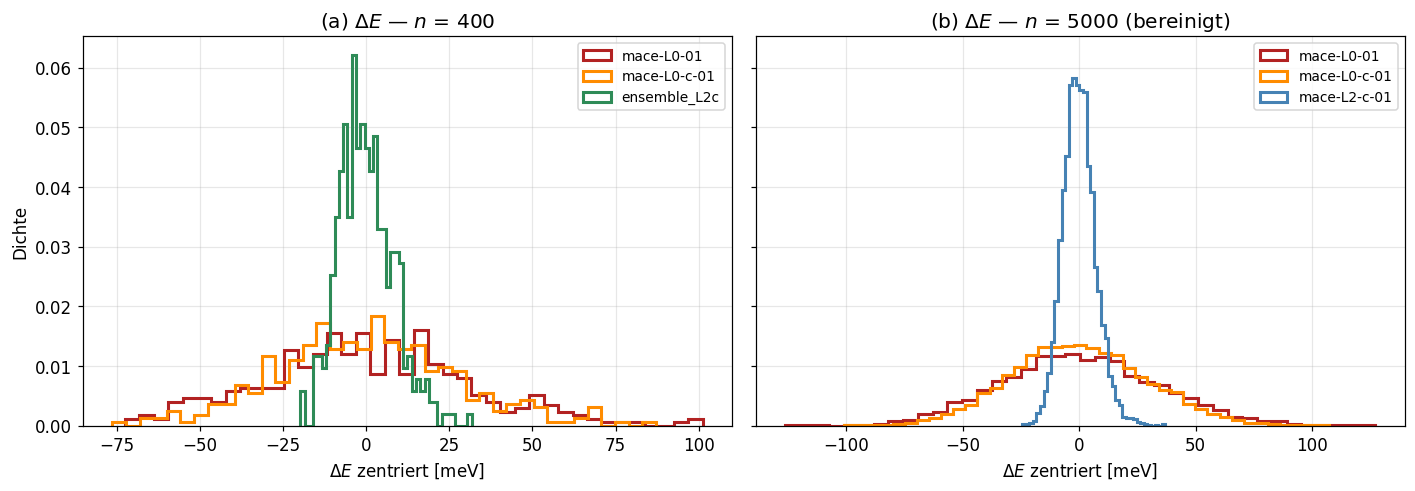

In [8]:
import numpy as np
import matplotlib.pyplot as plt

SHOW_400  = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "ensemble_L2c": "seagreen"}
SHOW_5000 = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "mace-L2-c-01": "steelblue"}
SHOW = SHOW_400          # Alias fuer die 400er-Folgeabschnitte (4.2, 4.3)

def moments_row(m, dE):
    s = dE.std(ddof=1); u = dE - dE.mean()
    g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4 - 3)
    print(f"{m:<15}{beta*s:>8.3f}{g1:>+9.3f}{g2:>+9.3f}{s*1000:>14.2f}")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)

print("n = 400 (testbig):")
print(f"{'Modell':<15}{'c':>8}{'gamma1':>9}{'gamma2':>9}{'std(dE)[meV]':>14}")
for m, col in SHOW_400.items():
    e_dft, e_mace = load_energies(CACHE / MODELS[m]); dE = e_dft - e_mace
    moments_row(m, dE)
    a.hist((dE-dE.mean())*1000, bins=40, density=True, histtype="step", lw=2, color=col, label=m)

print("\nn = 5000 (bereinigt):")
print(f"{'Modell':<15}{'c':>8}{'gamma1':>9}{'gamma2':>9}{'std(dE)[meV]':>14}")
for m, col in SHOW_5000.items():
    e_dft, e_mace = load_full(m); dE = e_dft - e_mace
    moments_row(m, dE)
    b.hist((dE-dE.mean())*1000, bins=40, density=True, histtype="step", lw=2, color=col, label=m)

a.set_xlabel("$\\Delta E$ zentriert [meV]"); a.set_ylabel("Dichte")
a.set_title("(a) $\\Delta E$ — $n$ = 400"); a.legend(fontsize=9); a.grid(alpha=0.3)
b.set_xlabel("$\\Delta E$ zentriert [meV]")
b.set_title("(b) $\\Delta E$ — $n$ = 5000 (bereinigt)"); b.legend(fontsize=9); b.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Ablesbar.** L2 ist **schmal**, aber (Tabelle) deutlich **rechtsschief** ($\gamma_1\approx0.4$–$0.5$).
Die L0-Modelle sind **breit**, ihre Form aber **näher an der Glocke** ($\gamma_1\approx0.1$–$0.2$).
Merke dir diesen Gegensatz — er ist der Schlüssel zu 4.3. Der große Satz (5000) bestätigt die
Skala und zeigt die L0-Verteilung sogar noch etwas breiter (größeres $c$), also die Entartung
klarer als die 400 Frames.

### 4.2 Ist $\Delta E$ gaußisch? — und warum die Frage in die Irre führt

Der QQ-Plot trägt die empirischen Quantile gegen die einer Normalverteilung auf (Gerade =
gaußisch); der Shapiro-Wilk-Test gibt ein $p$ dazu (klein = Normalität verworfen).

n = 400 (testbig):
Modell           Shapiro W      p-Wert      Normalität
mace-L0-01          0.9930    6.09e-02 nicht verworfen
mace-L0-c-01        0.9959    3.80e-01 nicht verworfen
ensemble_L2c        0.9850    3.67e-04       verworfen

n = 5000 (bereinigt):
Modell           Shapiro W      p-Wert      Normalität
mace-L0-01          0.9993    3.97e-02       verworfen
mace-L0-c-01        0.9988    9.62e-04       verworfen
mace-L2-c-01        0.9898    1.47e-18       verworfen


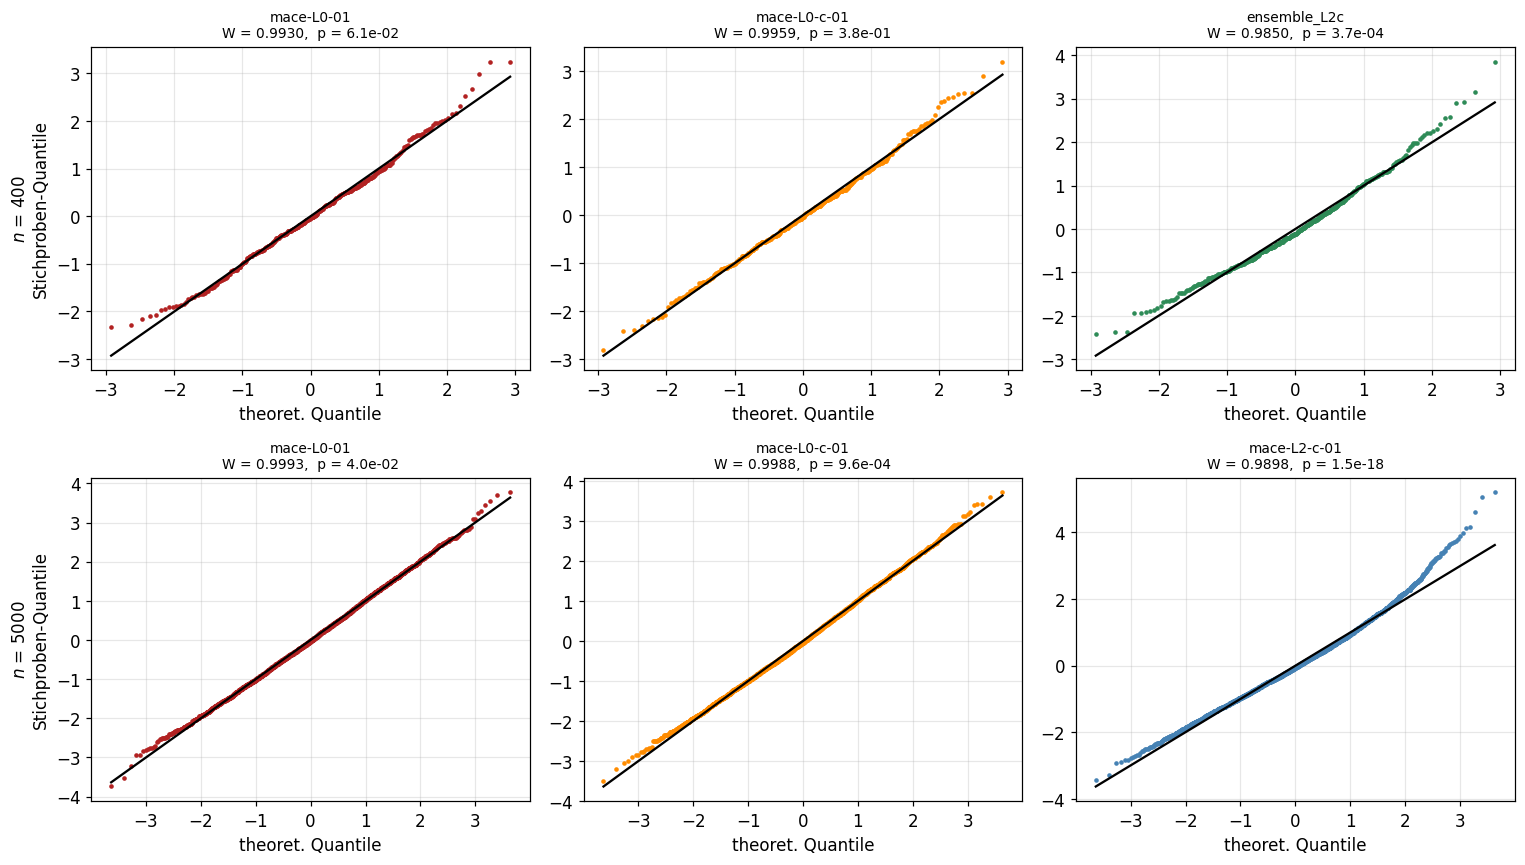

In [9]:
from scipy.stats import shapiro, probplot

def qq_row(axrow, items, loader):
    print(f"{'Modell':<15}{'Shapiro W':>11}{'p-Wert':>12}{'  Normalität':>16}")
    for ax, (m, col) in zip(axrow, items):
        e_dft, e_mace = loader(m); dE = e_dft - e_mace
        z = (dE - dE.mean()) / dE.std(ddof=1)
        probplot(z, dist="norm", plot=ax)
        W, pp = shapiro(dE)
        verdict = "verworfen" if pp < 0.05 else "nicht verworfen"
        print(f"{m:<15}{W:>11.4f}{pp:>12.2e}{verdict:>16}")
        ax.set_title(f"{m}\nW = {W:.4f},  p = {pp:.1e}", fontsize=9)
        ax.get_lines()[0].set_color(col); ax.get_lines()[0].set_markersize(2)
        ax.get_lines()[1].set_color("k")
        ax.set_xlabel("theoret. Quantile"); ax.set_ylabel("")

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
print("n = 400 (testbig):")
qq_row(axs[0], list(SHOW_400.items()),  lambda m: load_energies(CACHE / MODELS[m]))
print("\nn = 5000 (bereinigt):")
qq_row(axs[1], list(SHOW_5000.items()), lambda m: load_full(m))
axs[0, 0].set_ylabel("$n$ = 400\nStichproben-Quantile")
axs[1, 0].set_ylabel("$n$ = 5000\nStichproben-Quantile")
plt.tight_layout(); plt.show()

**Das Paradox — 400 und 5000 direkt gegenübergestellt** (alle L2 = `mace-L2-c-01`):

| Modell | $n$ | $W$ (Nähe zu Gauß) | Shapiro-Urteil | Gauß-Fehler |
|---|---|---|---|---|
| **L2**-c-01 | 400 | 0.988 | verworfen ($p=3\cdot10^{-3}$) | **−1.4 %** |
| | 5000 | 0.990 | verworfen ($p=10^{-18}$) | **−0.7 %** |
| **L0**-c-01 | 400 | 0.996 | *nicht* verworfen ($p=0.38$) | −18.4 % |
| | 5000 | 0.999 | verworfen ($p=10^{-3}$) | −17.7 % |
| **L0**-01 | 400 | 0.993 | *nicht* verworfen ($p=0.06$) | −40.1 % |
| | 5000 | 0.999 | verworfen ($p=0.04$) | −15.3 % |

Zwei Lesarten, beide entlarven den Normalitätstest:

1. **Sein Urteil ist wertlos.** Bei $n=400$ fehlt die Power — L0 wird „bestätigt", L2 verworfen.
   Bei $n=5000$ ist er so mächtig, dass er **alle** verwirft. Keiner der beiden Fälle sagt etwas
   über die Brauchbarkeit des Gauß-Prädiktors.
2. **Sein $W$ ist antikorreliert mit dem, worauf es ankommt.** In *beiden* Datensätzen ist L2 am
   *wenigsten* gaußisch (kleinstes $W$) und hat den *kleinsten* Fehler; die L0-Modelle sind am
   *gaußischsten* ($W\approx0.999$) und haben die *größten*.

Ein Normalitätstest ist hier also nicht nur die falsche Frage, sondern **irreführend**. Der Grund
(4.3): der Gauß-Fehler ist $\gamma_1 c^3$ — Form **mal Skala** —, und die Skala $c$ entscheidet,
nicht die Form.

### 4.3 Kish vs. Gauß — die eigentliche Größe

Wir stellen das **exakte** $N_\text{eff}/n$ (Kish, auf allen Daten, annahmefrei) neben den
**Gauß-Schätzer** $e^{-c^2}$. Die Abweichung ist genau das, was ein Normalitätstest *nicht*
sieht.

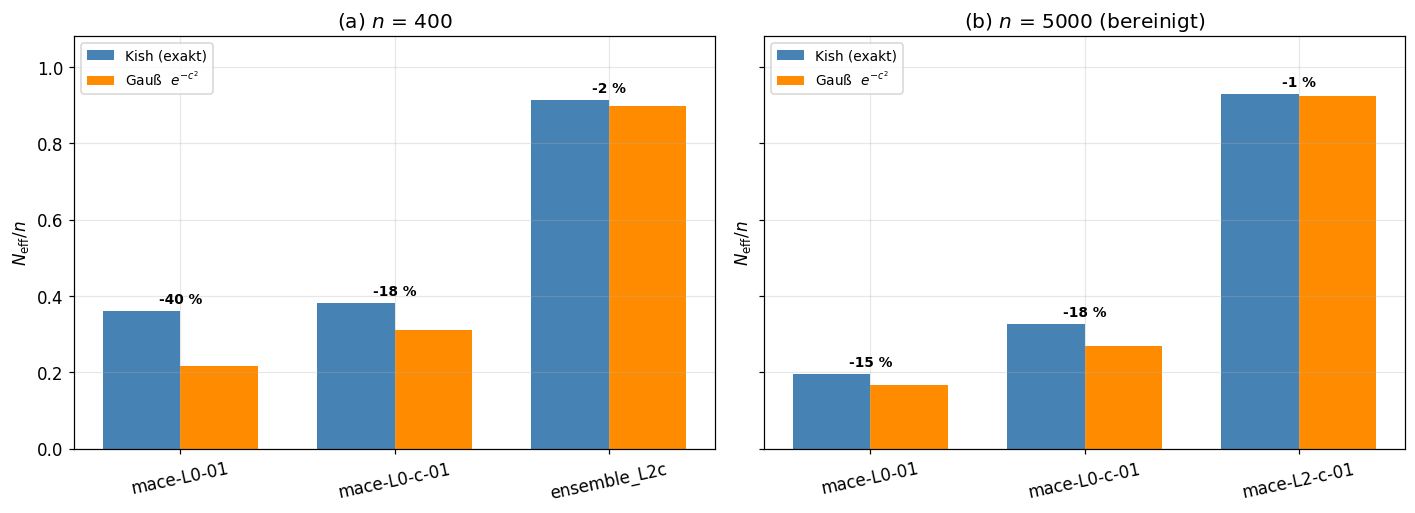

n = 400 (testbig):
Modell               c  gamma1 gamma1*c^3  (2c)^5/5!    Kish   Gauss   Fehler
mace-L0-01       1.238  +0.247      0.469      0.774   0.361   0.216   -40.1%
mace-L0-c-01     1.079  +0.207      0.260      0.391   0.382   0.312   -18.4%
ensemble_L2c     0.327  +0.501      0.017      0.001   0.912   0.899    -1.5%

n = 5000 (bereinigt):
Modell               c  gamma1 gamma1*c^3  (2c)^5/5!    Kish   Gauss   Fehler
mace-L0-01       1.340  +0.090      0.217      1.152   0.196   0.166   -15.3%
mace-L0-c-01     1.146  +0.127      0.192      0.527   0.327   0.269   -17.7%
mace-L2-c-01     0.283  +0.422      0.010      0.000   0.929   0.923    -0.7%


In [10]:
def kish_gauss_panel(ax, items, loader, title):
    ms = list(items); x = np.arange(len(ms)); wd = 0.36
    kish, gauss, rows = [], [], []
    for m in ms:
        e_dft, e_mace = loader(m); dE = e_dft - e_mace
        s = dE.std(ddof=1); u = dE - dE.mean()
        c = beta*s; g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4-3)
        k = effective_sample_size(reweighting_weights(e_dft, e_mace, beta))/dE.size
        kish.append(k); gauss.append(np.exp(-c**2))
        rows.append((m, c, g1, k, np.exp(-c**2), g1*c**3, (2*c)**5/120))
    ax.bar(x-wd/2, kish, wd, label="Kish (exakt)", color="steelblue")
    ax.bar(x+wd/2, gauss, wd, label="Gauß  $e^{-c^2}$", color="darkorange")
    for i in range(len(ms)):
        ax.text(i, max(kish[i], gauss[i])+0.02, f"{100*(gauss[i]/kish[i]-1):+.0f} %",
                ha="center", fontweight="bold", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(ms, rotation=12); ax.set_ylim(0, 1.08)
    ax.set_ylabel("$N_\\mathrm{eff}/n$"); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")
    return rows

def print_decomp(title, rows):
    print(title)
    print(f"{'Modell':<15}{'c':>7}{'gamma1':>8}{'gamma1*c^3':>11}{'(2c)^5/5!':>11}"
          f"{'Kish':>8}{'Gauss':>8}{'Fehler':>9}")
    for m, c, g1, k, ga, t3, R5 in rows:
        print(f"{m:<15}{c:>7.3f}{g1:>+8.3f}{t3:>11.3f}{R5:>11.3f}{k:>8.3f}{ga:>8.3f}"
              f"{100*(ga/k-1):>+8.1f}%")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
rows400  = kish_gauss_panel(a, SHOW_400,  lambda m: load_energies(CACHE / MODELS[m]),
                            "(a) $n$ = 400")
rows5000 = kish_gauss_panel(b, SHOW_5000, lambda m: load_full(m),
                            "(b) $n$ = 5000 (bereinigt)")
plt.tight_layout(); plt.show()

print_decomp("n = 400 (testbig):", rows400); print()
print_decomp("n = 5000 (bereinigt):", rows5000)

**Die Auflösung.** Der Gauß-Fehler hängt nicht davon ab, *wie* gaußisch $\Delta E$ ist,
sondern von $\gamma_1 c^3$ — **Form mal Skala-hoch-drei**. L0 hat sogar die *kleinere* Schiefe
($\gamma_1\approx0.2$ vs. $0.50$), aber sein $c^3$ ist ~50× größer ($1.24^3$ vs. $0.33^3$).
Der Schiefe-Beitrag $\gamma_1 c^3$ ist deshalb bei L0 rund 0.4–0.5, bei L2c nur 0.018 — Faktor
$\sim25$. Ein Normalitätstest misst die **Form**, nicht die $c$-Verstärkung, und geht deshalb
in die Irre. Die richtige Größe ist $\gamma_1 c^3$ (bzw. der Restterm $(2c)^5/5!$) — oder, wenn
man die Zahl braucht, **direkt Kish**.

### 4.4 Was das für L0 bedeutet

Der Gegensatz aus 4.1/4.3 wird jetzt zur Aussage — und beide Datensätze zeigen ihn:

- Bei kleinem $c$ (**L2**, $c\approx0.28$–$0.33$) ist $c^3$ winzig, die Formabweichung wird um
  Faktor $\sim30$–$45$ **gedämpft** — der Gauß-Term trägt, trotz nachgewiesener Nicht-Normalität
  ($\gamma_1 c^3\approx0.01$, Rest $\approx0$). Der Fehler bleibt unter 2 % (400) bzw. 1 % (5000).
- Bei großem $c$ (**L0**, $c\approx1.1$–$1.3$) ist $c^3\approx1.3$–$2.4$ **nicht** mehr gedämpft;
  die Form **dominiert**, und der effektive Entwicklungsparameter $2c\approx2.2$–$2.7$ liegt
  außerhalb des Konvergenzradius (§2.5) — die Reihe **divergiert** (Restterm $(2c)^5/5!\approx
  0.4$–$1.2$, Spalten oben). Der große Satz treibt $c$ sogar noch höher (1.24→1.34) — die
  Divergenz wird also **schärfer**, nicht milder.

**Konsequenz für den Workflow.** Für L0 ist der Gauß-/Kumulanten-*Prädiktor* wertlos — man nimmt
den exakten Kish-Wert (§2.1). Die **Entscheidung** bleibt davon unberührt: sie hängt an $c$
gegen $c_\text{max}$ (§2.6, §7), und $c=\beta\,\mathrm{std}(\Delta E)$ ist selbst dann robust,
wenn die Reihe längst nicht mehr trägt (§6). L0 ist also gerade der Fall, in dem die *Form* die
Prognose sprengt, die *Entscheidung* aber stabil bleibt — auf 400 wie auf 5000 Frames.

<a id="5"></a>
## 5. Die drei Diagnosegrößen: $c$, $\hat k$, $N_\text{eff}$

§2–§4 haben die Größen einzeln benutzt. Hier stellen wir sie **nebeneinander** und
beantworten die Leitfrage: *Warum reicht $c$ allein nicht — und wie wird aus der Kombination
ein verlässlicher Indikator?* Der Abschnitt schließt mit einem Beweis an den echten Daten.

### 5.1 Die drei Größen und ihre Rollen

| Größe | misst | Rolle | Charakter |
|---|---|---|---|
| $c=\beta\,\mathrm{std}(\Delta E)$ | Breite der $\Delta E$-Verteilung | **Skala / Entscheidung** | schnell, aber allein kein Prädiktor |
| $\hat k$ (PSIS-Tail) | Schwere des Gewichts-Tails | **Existenz-Gate** | ja/nein: existiert $N_\text{eff}$? |
| $N_\text{eff}$ (Kish) | $(\sum w)^2/\sum w^2$ | **exakte Wahrheit** | annahmefrei, nur auf vorhandenen Daten |

Die Werte für die realen Modelle als gemeinsamer Startpunkt:

In [11]:
import numpy as np
from uq_mace.reweighting import psis_khat

FOUR = ["ensemble_L2c", "mace-L2-c-01", "mace-L0-c-01", "mace-L0-01"]
print(f"{'Modell':<15}{'c':>8}{'khat':>9}{'N_eff/n (Kish)':>16}")
for m in FOUR:
    e_dft, e_mace = load_energies(CACHE / MODELS[m]); dE = e_dft - e_mace
    w = reweighting_weights(e_dft, e_mace, beta)
    print(f"{m:<15}{beta*dE.std(ddof=1):>8.3f}{psis_khat(w):>+9.3f}"
          f"{effective_sample_size(w)/dE.size:>16.3f}")

Modell                c     khat  N_eff/n (Kish)
ensemble_L2c      0.327   +0.068           0.912
mace-L2-c-01      0.335   -0.086           0.907
mace-L0-c-01      1.079   +0.416           0.382
mace-L0-01        1.238   +0.050           0.361


### 5.2 Warum $c$ allein kein Prädiktor ist

Behauptung: $c$ fixiert nur die **Skala**, nicht den Wert. Beweis durch Konstruktion — wir
bauen Verteilungen mit **identischem $c$** (alle mit $\mathrm{var}(z)=1$, also gleicher
$\mathrm{std}(\Delta E)$), aber verschiedener **Form**, und sehen, wie weit $N_\text{eff}/n$
dabei streut.

Das einfachste Beispiel ist eine **Zweipunkt-Verteilung**: ein häufiger Wert nahe 0 und ein
seltener Ausreißer (Wahrscheinlichkeit $p$), so justiert, dass Mittel 0 und Varianz 1 bleiben.
Ein seltener Ausreißer nach **links** ($\Delta E$ stark negativ) erzeugt ein dominierendes
Gewicht $\to N_\text{eff}\to$ klein; nach **rechts** bleiben die Gewichte fast gleich $\to
N_\text{eff}/n\to 1$ — bei **gleichem $c$**.

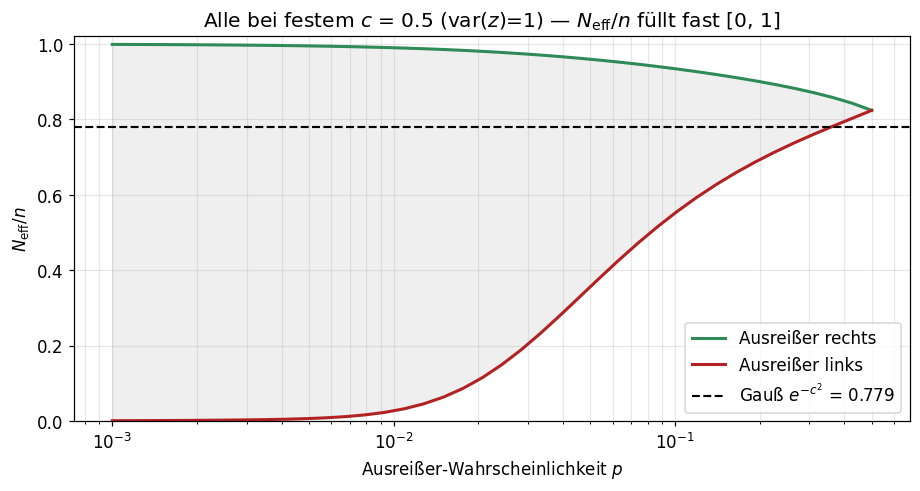

Bei c = 0.5:  N_eff/n von 0.0010 bis 0.9990  — Gauß-Wert 0.7788 liegt nur dazwischen.


In [12]:
c_fix = 0.5
def neff_twopoint(p, sign):
    b = np.sqrt((1-p)/p); a = -np.sqrt(p/(1-p))       # mean 0, var 1
    z = np.array([a, b]) * sign; pr = np.array([1-p, p])
    E1 = (pr*np.exp(-c_fix*z)).sum(); E2 = (pr*np.exp(-2*c_fix*z)).sum()
    return E1**2 / E2

ps = np.logspace(-3, np.log10(0.5), 40)
neff_hi = [neff_twopoint(p, +1) for p in ps]   # Ausreisser rechts -> hoch
neff_lo = [neff_twopoint(p, -1) for p in ps]   # Ausreisser links  -> tief

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.semilogx(ps, neff_hi, "-", color="seagreen", lw=2, label="Ausreißer rechts")
ax.semilogx(ps, neff_lo, "-", color="firebrick", lw=2, label="Ausreißer links")
ax.fill_between(ps, neff_lo, neff_hi, color="gray", alpha=0.12)
ax.axhline(np.exp(-c_fix**2), color="k", ls="--", lw=1.4,
           label=f"Gauß $e^{{-c^2}}$ = {np.exp(-c_fix**2):.3f}")
ax.set_xlabel("Ausreißer-Wahrscheinlichkeit $p$"); ax.set_ylabel("$N_\\mathrm{eff}/n$")
ax.set_ylim(0, 1.02); ax.set_title(f"Alle bei festem $c$ = {c_fix} (var$(z)$=1) — "
                                   f"$N_\\mathrm{{eff}}/n$ füllt fast [0, 1]")
ax.legend(); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

print(f"Bei c = {c_fix}:  N_eff/n von {min(neff_lo):.4f} bis {max(neff_hi):.4f}"
      f"  — Gauß-Wert {np.exp(-c_fix**2):.4f} liegt nur dazwischen.")

**Fazit.** Bei festem $c$ ist $N_\text{eff}/n$ **nicht bestimmt** — es hängt von der Form ab.
$c$ sagt nur, in welcher Größenordnung man sich bewegt. Distributionsfrei gilt allein:
$c\to 0 \Rightarrow N_\text{eff}/n\to 1$. Für eine echte Aussage braucht es die Form
($\gamma_1,\gamma_2$) **und** die Tail-Absicherung ($\hat k$).

### 5.3 Wie die Kombination zum Indikator wird

Der Indikator entsteht in **vier Schichten**, jede schließt eine Lücke, die die vorige offen
lässt:

**Schicht 1 — $c$: die Skala.** $c=\beta\,\mathrm{std}(\Delta E)$ misst die Breite, ist schnell
bestimmt (§6). Aber (5.2) bei festem $c$ ist $N_\text{eff}/n$ unbestimmt — $c$ allein gibt nur
die Größenordnung.

**Schicht 2 — Form ($\gamma_1,\gamma_2$): macht $c$ zur Prognose.** Die Kumulantenentwicklung
$N_\text{eff}/n = \exp(-c^2+\gamma_1 c^3-\tfrac{7}{12}\gamma_2 c^4)$ nutzt Skala **und** Form.
Damit ist die Lücke aus Schicht 1 geschlossen — kennt man beides, ist $N_\text{eff}/n$
festgelegt (wo die Reihe konvergiert, §2.5).

**Schicht 3 — $\hat k$: das Existenz-Gate.** Selbst mit $c$ und Form ist alles bedeutungslos,
falls $N_\text{eff}$ gar nicht existiert ($E[w^2]=\infty$). $\hat k<0.5$ garantiert die Existenz
— eine binäre Vorbedingung, unabhängig von $c$ und Form (Details §8).

**Schicht 4 — Kish: der exakte Anker.** Auf den vorhandenen Gewichten ist
$N_\text{eff}/n=(\sum w)^2/(n\sum w^2)$ exakt und annahmefrei — die Wahrheit, gegen die Schicht 2
geprüft wird, und der **Rückfallwert**, wenn die Reihe (großes $c$) versagt.

> **Der Indikator.** Die Entscheidung läuft über $c$ gegen $c_\text{max}$ (§7), abgesichert
> durch das $\hat k$-Gate und, wo nötig, den exakten Kish-Wert. Jede Größe schließt eine
> spezifische Lücke — Skala, Prognose, Existenz, Wahrheit —, keine ist durch die anderen
> ersetzbar. Das prüfen wir jetzt an den Daten.

### 5.4 Beweis an den echten Daten

Für jedes Modell stellen wir nebeneinander: den Gauß-Schätzer ($c$ **allein**), die
Kumulanten-Prognose ($c$ **+ Form**), und die exakte Kish-Wahrheit — plus das $\hat k$-Gate.
Panel **(a)** zeigt den Testsatz ($n$ = 400), Panel **(b)** den großen Satz
($n$ = 5000, 4 DFT-Artefakte entfernt) im selben Stil.

n = 400  (testbig):
Modell              c   khat   Gate      Reihe |   Gauß(c)  Kumul.(c+Form)    Kish
--------------------------------------------------------------------------------------------
ensemble_L2c    0.327 +0.068     OK konvergent |     0.899           0.912   0.912
mace-L2-c-01    0.335 -0.086     OK konvergent |     0.894           0.907   0.907
mace-L0-c-01    1.079 +0.416     OK  divergent |     0.312         (0.362)   0.382
mace-L0-01      1.238 +0.050     OK  divergent |     0.216         (0.304)   0.361

n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):
Modell              c   khat   Gate      Reihe |   Gauß(c)  Kumul.(c+Form)    Kish
--------------------------------------------------------------------------------------------
mace-L0-01      1.340 +0.314     OK  divergent |     0.166         (0.228)   0.196
mace-L0-c-01    1.146 +0.223     OK  divergent |     0.269         (0.347)   0.327
mace-L2-c-01    0.283 +0.024     OK konvergent |     0.923           0.929   0

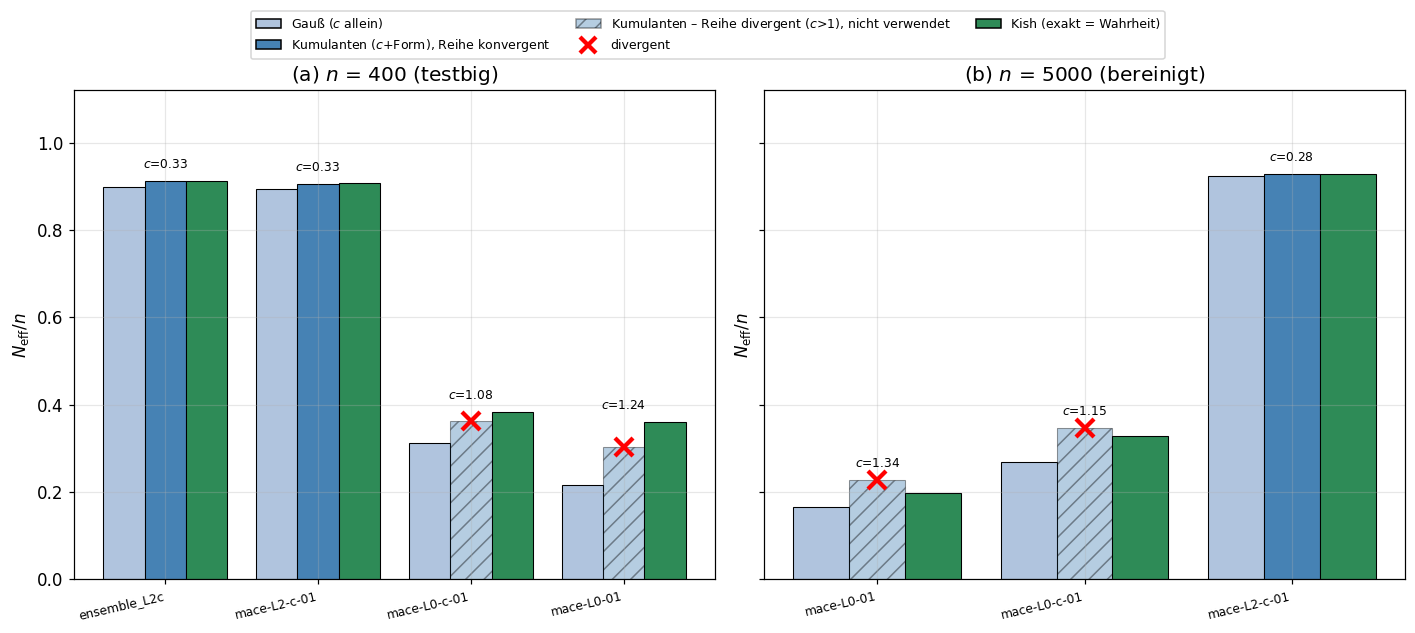

In [13]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def proof_stats(e_dft, e_mace):
    dE = e_dft - e_mace
    s = dE.std(ddof=1); u = dE - dE.mean()
    c = beta*s; g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4-3)
    w = reweighting_weights(e_dft, e_mace, beta)
    kish = effective_sample_size(w)/dE.size; kh = psis_khat(w)
    return c, kh, np.exp(-c**2), np.exp(-c**2 + g1*c**3 - 7/12*g2*c**4), kish

def proof_table(title, items):
    print(title)
    print(f"{'Modell':<14}{'c':>7}{'khat':>7}{'Gate':>7}{'Reihe':>11} | "
          f"{'Gauß(c)':>9}{'Kumul.(c+Form)':>16}{'Kish':>8}")
    print("-"*92)
    for m, (e_dft, e_mace) in items:
        c, kh, gauss, kumul, kish = proof_stats(e_dft, e_mace)
        gate = "OK" if kh < 0.5 else "FAIL"
        div  = "divergent" if (2*c)**5/120 >= 0.05 else "konvergent"
        # bei Divergenz ist die Kumulanten-Zahl formal ungueltig -> als (…) markiert
        kstr = f"({kumul:.3f})" if div == "divergent" else f"{kumul:.3f}"
        print(f"{m:<14}{c:>7.3f}{kh:>+7.3f}{gate:>7}{div:>11} | "
              f"{gauss:>9.3f}{kstr:>16}{kish:>8.3f}")

proof_table("n = 400  (testbig):",
            [(m, load_energies(CACHE / MODELS[m])) for m in FOUR])
print()
proof_table("n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):",
            [(m, load_full(m)) for m in MODELS_FULL])
print("\n(...) = Reihe divergent (c>1), Wert formal ungueltig -> es gilt der exakte Kish-Wert.")

# Drei Balken je Modell: Gauss-Praediktor, Kumulanten-Praediktor, Kish (Wahrheit).
# Divergente Reihe (c>1) -> Kumulanten-Balken schraffiert + rot durchgestrichen (nicht verwendet).
def proof_bars(ax, items, title):
    ms = list(items); x = np.arange(len(ms)); w = 0.27
    for i, m in enumerate(ms):
        c, kh, gauss, kumul, kish = proof_stats(*items[m])
        div = (2*c)**5/120 >= 0.05
        ax.bar(x[i]-w, gauss, w, color="lightsteelblue", edgecolor="k", lw=0.7)
        ax.bar(x[i],   kumul, w, color="steelblue", edgecolor="k", lw=0.7,
               hatch="//" if div else "", alpha=0.4 if div else 1.0)
        ax.bar(x[i]+w, kish,  w, color="seagreen", edgecolor="k", lw=0.7)
        if div:
            ax.plot(x[i], kumul, "x", color="red", ms=12, mew=2.8, zorder=6)
        ax.text(x[i], max(gauss, kumul, kish)+0.03, f"$c$={c:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(ms, rotation=13, ha="right", fontsize=8)
    ax.set_ylabel("$N_\\mathrm{eff}/n$"); ax.set_ylim(0, 1.12); ax.set_title(title)
    ax.grid(alpha=0.3, axis="y")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True)
proof_bars(a, {m: load_energies(CACHE / MODELS[m]) for m in FOUR}, "(a) $n$ = 400 (testbig)")
proof_bars(b, {m: load_full(m) for m in MODELS_FULL},              "(b) $n$ = 5000 (bereinigt)")
handles = [Patch(fc="lightsteelblue", ec="k", label="Gauß ($c$ allein)"),
           Patch(fc="steelblue", ec="k", label="Kumulanten ($c$+Form), Reihe konvergent"),
           Patch(fc="steelblue", ec="k", hatch="//", alpha=0.4,
                 label="Kumulanten – Reihe divergent ($c$>1), nicht verwendet"),
           Line2D([], [], color="red", marker="x", ls="", ms=11, mew=2.8, label="divergent"),
           Patch(fc="seagreen", ec="k", label="Kish (exakt = Wahrheit)")]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=8.2, bbox_to_anchor=(0.5, 1.07))
plt.tight_layout(); plt.show()

**Was der Beweis zeigt** (Panel (a) $n$=400, Panel (b) $n$=5000; je drei Balken pro Modell):

- **$c$ allein (Gauß, hellblau)** trifft für die guten Modelle fast die Kish-Wahrheit, für L0 aber weit daneben (bis $-40\,\%$ bei $n$=400, $-18\,\%$ bei $n$=5000) — bestätigt 5.2: die Skala genügt nicht.
- **$c$ + Form (Kumulanten, dunkelblau)** ist nur dort gezeichnet, wo die **Reihe konvergiert** ($c<1$, Restglied $(2c)^5/5!<0.05$): für **L2c/L2-c-01** trifft sie die Wahrheit exakt ($<0.1\,\%$ in beiden Sätzen). Für **L0** ist $c\approx1.1$–1.34, die Reihe **divergiert** (§2.5) — der Balken ist deshalb **schraffiert und rot durchgestrichen**: er zeigt nur, *was* die divergente Reihe ausspuckt, wird aber **nicht verwendet**. Dort gilt allein der exakte Kish-Wert (grün, Schicht 4).
- **$\hat k$-Gate** ist bei allen bestanden ($<0.5$), $N_\text{eff}$ existiert also überall. L0-c-01 liegt bei $n$=400 mit $0.42$ nahe an der Grenze; auf dem größeren Satz entspannt sich das auf $0.22$ (mehr Frames, stabilerer Schwanz-Schätzer, §8).

Die Rollen bleiben sauber getrennt: bei kleinem $c$ liefert die Reihe die genaue Prognose (hell- und dunkelblau decken den grünen Balken), bei großem $c$ ist sie ungültig und man liest direkt den grünen Kish-Balken. Das **reproduziert sich von 400 auf 5000 Frames** — und **keine der Größen allein leistet es**.

<a id="6"></a>
## 6. Konvergenz der Momente

§5 hat gezeigt: ohne die Form ($\gamma_1,\gamma_2$) ist keine Aussage möglich — sie sind
**essenziell**. Zugleich konvergieren sie **langsam und verzerrt**. Dieser Abschnitt löst die
Spannung auf: Wie schnell konvergieren $c,\gamma_1,\gamma_2$, woher kommen ihre Standardfehler,
und warum ist die langsame Konvergenz für die Entscheidung trotzdem unkritisch.

### 6.1 Woher die Standardfehler kommen

Der Standardfehler von $c=\beta\sigma$ (mit $\sigma=\mathrm{std}(\Delta E)$, §2.2) folgt aus
einer einzigen Beobachtung: **die Stichprobenvarianz ist selbst ein Mittelwert.** Damit ist der
Rest gewöhnliche Fehlerfortpflanzung.

Schreibe den Schätzer $\widehat{\sigma^2}$ als

$$\widehat{\sigma^2} \approx \frac{1}{k}\sum_{i=1}^{k}\underbrace{(\Delta E_i-\mu)^2}_{\equiv\,Y_i},$$

also den Mittelwert von $k$ Zahlen $Y_i=(\Delta E_i-\mu)^2$ mit $E[Y]=\sigma^2$. Für den
Mittelwert von irgendetwas ist die Unsicherheit bekannt:
$\mathrm{Var}(\overline Y)=\mathrm{Var}(Y)/k$ — das ist der Ursprung des $1/k$, dasselbe
Averaging-Argument wie beim Standardfehler des Mittelwerts.

**Schritt 1 — die Varianz von $Y$.** Mit $Y=(\Delta E-\mu)^2$ ist

$$\mathrm{Var}(Y)=E[Y^2]-E[Y]^2=E[(\Delta E-\mu)^4]-\big(E[(\Delta E-\mu)^2]\big)^2=\mu_4-\sigma^4,$$

mit $\mu_4$ dem vierten zentralen Moment. Also

$$\mathrm{Var}(\widehat{\sigma^2})=\frac{\mu_4-\sigma^4}{k}.$$

Anschaulich: die Varianz ist aus *quadrierten* Abweichungen gebaut, ihre Schwankung hängt daher
an *vierten* Potenzen — am vierten Moment. Ausreißer (dicke Flanken) bewegen sie stark.

**Schritt 2 — die Form einsetzen.** Die Exzess-Kurtosis ist $\gamma_2=\mu_4/\sigma^4-3$ (§2.3),
also $\mu_4=(\gamma_2+3)\sigma^4$ und damit $\mu_4-\sigma^4=(\gamma_2+2)\sigma^4$. In
**relativer** Form (teilen durch $\sigma^2$, quadriert also $\sigma^4$):

$$\frac{\mathrm{SE}(\widehat{\sigma^2})}{\sigma^2}=\frac{\sqrt{(\gamma_2+2)\sigma^4/k}}{\sigma^2}=\sqrt{\frac{\gamma_2+2}{k}}.$$

Das $\sigma^4$ kürzt sich weg — die *relative* Präzision der Varianz hängt nur an der Form
($\gamma_2$) und der Stichprobengröße ($k$), nicht an der Skala.

**Schritt 3 — von der Varianz zur Standardabweichung (die Wurzel).** Gebraucht wird
$\sigma=\sqrt{\sigma^2}$. Die Delta-Methode gibt für eine Funktion $g$ den Zusammenhang
$\mathrm{SE}(g(X))\approx|g'|\,\mathrm{SE}(X)$; mit $g(X)=\sqrt X$ und $g'=\tfrac{1}{2\sqrt X}$
wird

$$\frac{\mathrm{SE}(\sqrt X)}{\sqrt X}=\frac{\mathrm{SE}(X)/(2\sqrt X)}{\sqrt X}=\frac12\,\frac{\mathrm{SE}(X)}{X}.$$

Die Wurzel **halbiert den relativen Fehler** (weil $\mathrm{d}\ln\sqrt X=\tfrac12\,\mathrm{d}\ln X$):
ist die Varianz auf ±10 % bekannt, dann $\sigma$ auf ±5 %. Also

$$\frac{\mathrm{SE}(\hat\sigma)}{\sigma}=\frac12\sqrt{\frac{\gamma_2+2}{k}}=\sqrt{\frac{\gamma_2+2}{4k}}.$$

**Schritt 4 — von $\sigma$ zu $c$.** $c=\beta\sigma$ mit der Konstanten $\beta$; eine Konstante
ändert den *relativen* Fehler nicht und kürzt sich in
$\mathrm{SE}(c)/c=\mathrm{SE}(\hat\sigma)/\sigma$ heraus:

$$\boxed{\;\frac{\mathrm{SE}(c)}{c}=\sqrt{\frac{\gamma_2+2}{4k}}\;}$$

Der Grenzfall Gauß ($\gamma_2=0$) gibt $\mathrm{SE}(c)/c=1/\sqrt{2k}$ — die vertraute
$1/\sqrt{k}$-Rate; dicke Flanken ($\gamma_2>0$) vergrößern sie. Invertiert,
$k=(\gamma_2+2)/(4\varepsilon^2)$, ist es genau die „wie viele DFT-Punkte für $\varepsilon$ %
Präzision auf $c$"-Formel aus §6.3. Die einzigen Näherungen sind „die Varianz ist ein
Mittelwert" (exakt bis auf den bei großem $k$ vernachlässigbaren $(k-1)/k$-Bias) und die
Linearisierung der Wurzel — beides **verteilungsallgemein**, nirgends steckt Normalität drin,
nur ein endliches viertes Moment.

**$\gamma_1,\gamma_2$ — Unsicherheit ausschließlich per Bootstrap.** $\gamma_1$ ist die Schiefe,
$\gamma_2$ die Exzess-Kurtosis von $\Delta E$ (§2.3, §5) — die beiden Formkorrekturen der
Kumulantenentwicklung. Geschlossene Standardfehler gibt es für sie nur unter der Nullhypothese
„$\Delta E$ normalverteilt". $\Delta E$ ist aber nachweislich *nicht* normal (§4); dann hängt die
wahre Varianz von $\gamma_1,\gamma_2$ von noch höheren Momenten ab und ist **größer** als die
Normaltheorie — eine analytische Formel würde die Unsicherheit systematisch unterschätzen.
Deshalb schätzen wir $\mathrm{SE}(\gamma_1)$ und $\mathrm{SE}(\gamma_2)$ **ausschließlich per
Bootstrap** (§6.2), ohne analytische Näherung.

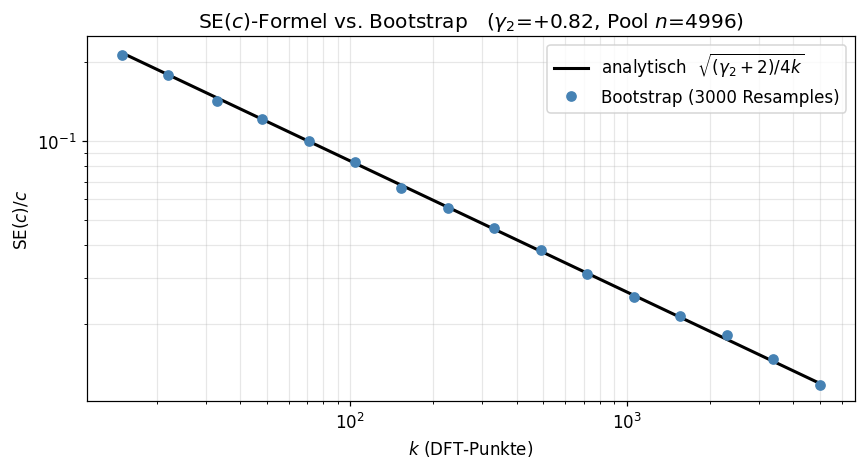

max. Abweichung Bootstrap/analytisch: 3.9 %   (über k = 15…4996)


In [14]:
# Verifikation der SE(c)-Formel gegen den Bootstrap (gut-artiger Pool L2-c-01, n=5000 bereinigt)
import numpy as np
import matplotlib.pyplot as plt

ed_v, em_v = load_full("mace-L2-c-01")                 # bereinigt (ohne die 4 DFT-Artefakte)
dE_v = ed_v - em_v
g2_v = float(((dE_v - dE_v.mean())**4).mean() / dE_v.std(ddof=1)**4 - 3)
c_v  = beta * dE_v.std(ddof=1)

rng = np.random.default_rng(0)
ks_v = np.unique(np.round(np.geomspace(15, dE_v.size, 16)).astype(int))
se_boot, se_ana = [], []
for k in ks_v:
    cb = beta * np.array([dE_v[rng.integers(0, dE_v.size, k)].std(ddof=1) for _ in range(3000)])
    se_boot.append(cb.std(ddof=1) / c_v)               # Bootstrap-SE, relativ
    se_ana.append(np.sqrt((g2_v + 2) / (4 * k)))       # Formel aus 6.1
se_boot, se_ana = np.array(se_boot), np.array(se_ana)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.loglog(ks_v, se_ana,  color="k", lw=2, label=r"analytisch  $\sqrt{(\gamma_2+2)/4k}$")
ax.loglog(ks_v, se_boot, "o", color="steelblue", ms=6, label="Bootstrap (3000 Resamples)")
ax.set_xlabel("$k$ (DFT-Punkte)"); ax.set_ylabel(r"$\mathrm{SE}(c)/c$")
ax.set_title(f"SE($c$)-Formel vs. Bootstrap   ($\\gamma_2$={g2_v:+.2f}, Pool $n$={dE_v.size})")
ax.legend(); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

print(f"max. Abweichung Bootstrap/analytisch: {np.abs(se_boot/se_ana - 1).max()*100:.1f} %"
      f"   (über k = {ks_v.min()}…{ks_v.max()})")

### 6.2 Bootstrap-Konvergenz und Bias

Wir ziehen Bootstrap-Stichproben der Größe $k$ und verfolgen Median und 5–95 %-Band von $c,\gamma_1,\gamma_2$ — **aus den 400 Testframes** (blau, $k$ bis 400) und **aus dem großen Satz** (rot, $k$ bis 5000). Der größere Pool lässt $k$ weiter laufen und zeigt, wie die Bänder über $k=400$ hinaus schrumpfen.

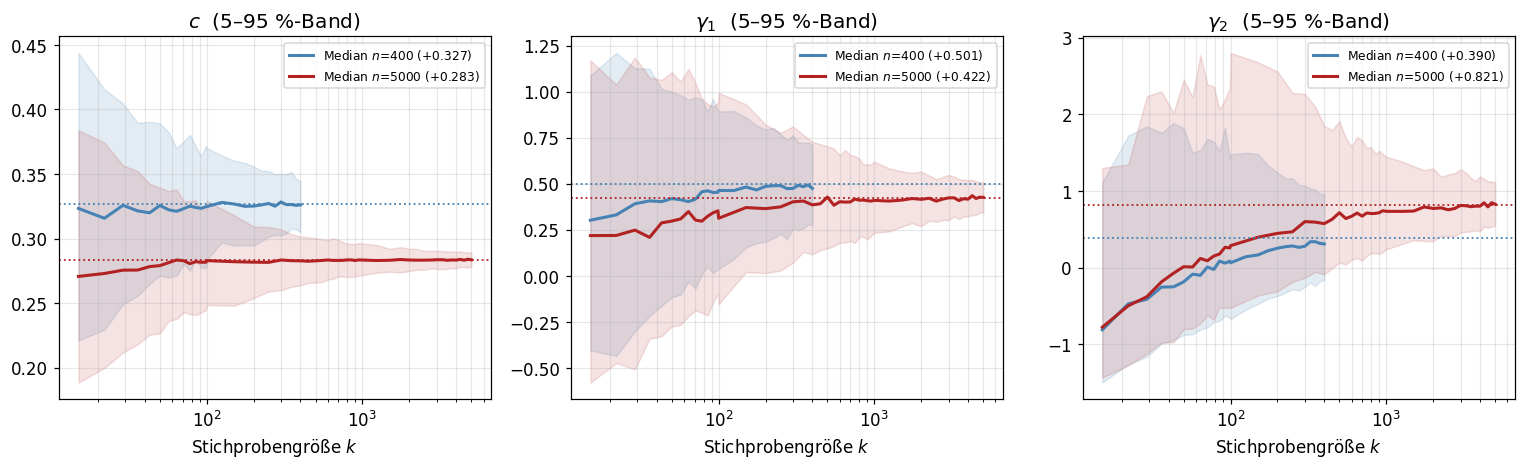

Standardfehler  (Bootstrap  vs.  Normaltheorie-Formel):
  n=400,  k=400 :  c=0.0127 (Formel 0.0126) | g1=0.1355 (sqrt(6/k) 0.1225) | g2=0.3687 (sqrt(24/k) 0.2449)
  n=5000, k=400 :  c=0.0121 (Formel 0.0119) | g1=0.1820 (sqrt(6/k) 0.1225) | g2=0.6087 (sqrt(24/k) 0.2449)


  n=5000, k=5000:  c=0.0034 (Formel 0.0034) | g1=0.0508 (sqrt(6/k) 0.0346) | g2=0.1738 (sqrt(24/k) 0.0693)   <- volle erreichbare Praezision

(g2-Formel unterschaetzt durchweg -> nicht-normale Verteilung, Warnung aus 6.1)


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def moments(d):
    s = d.std(ddof=1); u = d - d.mean()
    return beta*s, float((u**3).mean()/s**3), float((u**4).mean()/s**4-3)

def boot_band(dE, ks, nboot=400, seed=0):
    rng = np.random.default_rng(seed); n = dE.size
    out = {q: {j: [] for j in range(3)} for q in ("med","lo","hi")}
    for k in ks:
        M = np.empty((nboot, 3))
        for b in range(nboot):
            M[b] = moments(dE[rng.integers(0, n, k)])
        for j in range(3):
            out["med"][j].append(np.median(M[:, j]))
            out["lo"][j].append(np.percentile(M[:, j], 5))
            out["hi"][j].append(np.percentile(M[:, j], 95))
    return {q: {j: np.array(v) for j, v in out[q].items()} for q in out}

dE4 = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))          # 400 Frames
dEf = np.subtract(*load_full("mace-L2-c-01"))                             # 5000, bereinigt
t4  = moments(dE4); tf = moments(dEf)
c0, g10, g20 = t4          # 400er-Referenz (ensemble_L2c) fuer 6.3

ks4 = np.unique(np.r_[np.arange(15,100,7), np.arange(100,401,25)])
ksf = np.unique(np.r_[np.arange(15,100,7), np.arange(100,1000,50), np.arange(1000,5001,250)])
b4  = boot_band(dE4, ks4); bf = boot_band(dEf, ksf)

fig, axs = plt.subplots(1, 3, figsize=(14, 4.4))
labs = ["$c$", "$\\gamma_1$", "$\\gamma_2$"]
for j, (ax, lab) in enumerate(zip(axs, labs)):
    ax.semilogx(ks4, b4["med"][j], color="steelblue", lw=2, label=f"Median $n$=400 ({t4[j]:+.3f})")
    ax.fill_between(ks4, b4["lo"][j], b4["hi"][j], color="steelblue", alpha=0.15)
    ax.semilogx(ksf, bf["med"][j], color="firebrick", lw=2, label=f"Median $n$=5000 ({tf[j]:+.3f})")
    ax.fill_between(ksf, bf["lo"][j], bf["hi"][j], color="firebrick", alpha=0.13)
    ax.axhline(t4[j], color="steelblue", ls=":", lw=1.2)
    ax.axhline(tf[j], color="firebrick", ls=":", lw=1.2)
    ax.set_xlabel("Stichprobengröße $k$"); ax.set_title(f"{lab}  (5–95 %-Band)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

# Bootstrap-SE vs. Normaltheorie-Formel
def se_line(dE, k, seed=1):
    rng = np.random.default_rng(seed)
    B = np.array([moments(dE[rng.integers(0, dE.size, k)]) for _ in range(1000)])
    se = B.std(axis=0); c0, g10, g20 = moments(dE)
    return (f"  c={se[0]:.4f} (Formel {c0*np.sqrt((g20+2)/(4*k)):.4f}) | "
            f"g1={se[1]:.4f} (sqrt(6/k) {np.sqrt(6/k):.4f}) | "
            f"g2={se[2]:.4f} (sqrt(24/k) {np.sqrt(24/k):.4f})")
print("Standardfehler  (Bootstrap  vs.  Normaltheorie-Formel):")
print(f"  n=400,  k=400 :{se_line(dE4, 400)}")
print(f"  n=5000, k=400 :{se_line(dEf, 400)}")
print(f"  n=5000, k=5000:{se_line(dEf, 5000)}   <- volle erreichbare Praezision")
print("\n(g2-Formel unterschaetzt durchweg -> nicht-normale Verteilung, Warnung aus 6.1)")

**Drei Beobachtungen:**

- **Konvergenzgeschwindigkeit.** $c$ ist schon bei kleinem $k$ **unverzerrt** (der Median trifft den wahren Wert), seine **Präzision** verbessert sich aber weiter. Die SE-Formel aus §6.1 ist $\mathrm{SE}(c)/c=\sqrt{(\gamma_2+2)/4k}$; nach $k$ aufgelöst (mit $\varepsilon\equiv\mathrm{SE}(c)/c$) wird daraus $k=(\gamma_2+2)/(4\varepsilon^2)$. Damit entspricht $\varepsilon=20\,\%$ gerade $k\approx15$, $\varepsilon=10\,\%$ etwa $k\approx60$, $\varepsilon=5\,\%$ erst $k\approx240$. $\gamma_1$ ($\mathrm{SE}\approx\sqrt{6/k}$) und $\gamma_2$ ($\mathrm{SE}\approx\sqrt{24/k}$) folgen derselben $\sqrt{1/k}$-Rate mit größeren Vorfaktoren.
- **Was der große Satz bringt.** Die roten Bänder laufen bis $k=5000$ und schrumpfen weit unter das, was 400 Frames erlauben — bei $k=5000$ ist $c$ auf rund $\pm2\,\%$ bestimmt, $\gamma_2$ auf etwa $\pm0.2$. Die $k$-Schwellen selbst (15/60/240 für 20/10/5 %) sind aber **skalenfrei**: sie hängen nur an $\gamma_2$, nicht am Pool. Der große Satz senkt also nicht die Schwelle, sondern erlaubt, sie zu **überschreiten**.
- **Bias bei kleinem $k$.** $\gamma_1,\gamma_2$ sind nach unten verzerrt (bei $k=15$ deutlich unter dem Endwert). Das ist die **sichere Richtung**: unterschätzte Schiefe → schwächere Formkorrektur → Schranke näher an Gauß → konservativer, nie fälschlich PASS (§2.6).

Der Bootstrap-SE für $\gamma_2$ liegt in **beiden** Pools über der Normaltheorie-Formel — die Warnung aus 6.1 bestätigt sich unabhängig von $n$.

### 6.3 Fehlerfortpflanzung — warum die langsame Konvergenz unkritisch ist

$\gamma_1,\gamma_2$ gehen nicht direkt in $N_\text{eff}$ ein, sondern gedämpft über $c^3$ bzw.
$c^4$. Ihre Unsicherheit pflanzt sich also als $\mathrm{SE}(\gamma_1)\,c^3$ und
$\mathrm{SE}(\gamma_2)\,c^4$ fort — bei kleinem $c$ winzig.

Beitrag der Terme zu log(N_eff/n) und ihre Unsicherheit (SE bei k=400):

     c      -c^2           +g1 c^3    -7/12 g2 c^4
  0.33    0.1069    0.0175 ± 0.0043        0.0026   (0.4 % auf N_eff)
  0.50    0.2500    0.0626 ± 0.0153        0.0142   (1.5 % auf N_eff)
  0.70    0.4900    0.1718 ± 0.0420        0.0546   (4 % auf N_eff)
  1.00    1.0000    0.5008 ± 0.1225        0.2275   (12 % auf N_eff)


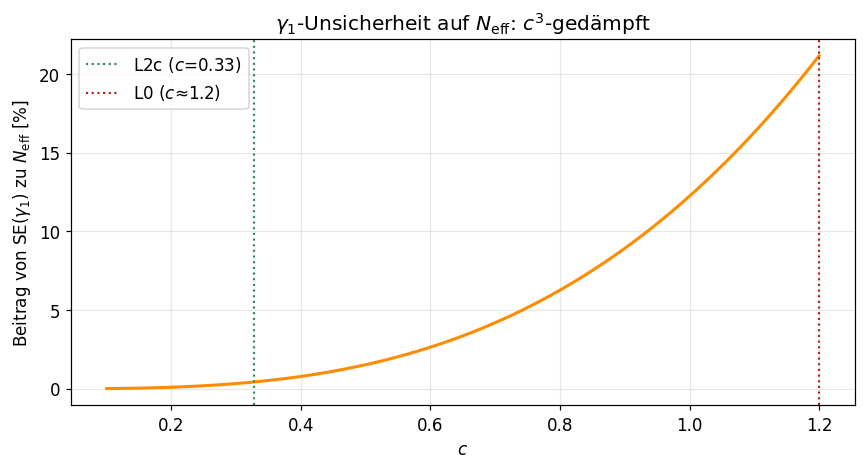

In [16]:
SEc = c0*np.sqrt((g20+2)/1600); SEg1 = np.sqrt(6/400); SEg2 = np.sqrt(24/400)
print(f"Beitrag der Terme zu log(N_eff/n) und ihre Unsicherheit (SE bei k=400):\n")
print(f"{'c':>6}{'-c^2':>10}{'+g1 c^3':>18}{'-7/12 g2 c^4':>16}")
for c in (0.327, 0.5, 0.7, 1.0):
    t2=c**2; t3=g10*c**3; t4=7/12*g20*c**4
    se3=c**3*SEg1                    # dominanter Beitrag der g1-Unsicherheit
    print(f"{c:>6.2f}{t2:>10.4f}{t3:>10.4f} ± {se3:<5.4f}{t4:>14.4f}"
          f"   ({100*se3:.1f} % auf N_eff)" if c<0.6 else
          f"{c:>6.2f}{t2:>10.4f}{t3:>10.4f} ± {se3:<5.4f}{t4:>14.4f}   ({100*se3:.0f} % auf N_eff)")

# g1-Unsicherheit auf N_eff als Funktion von c
cc = np.linspace(0.1, 1.2, 100)
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(cc, 100*cc**3*SEg1, color="darkorange", lw=2)
ax.axvline(0.327, color="seagreen", ls=":", lw=1.4, label="L2c ($c$=0.33)")
ax.axvline(1.2, color="firebrick", ls=":", lw=1.4, label="L0 ($c$≈1.2)")
ax.set_xlabel("$c$"); ax.set_ylabel("Beitrag von SE($\\gamma_1$) zu $N_\\mathrm{eff}$ [%]")
ax.set_title("$\\gamma_1$-Unsicherheit auf $N_\\mathrm{eff}$: $c^3$-gedämpft")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Die Auflösung.** Bei L2c ($c=0.33$) trägt die $\gamma_1$-Unsicherheit nur **0.4 %** zu
$N_\text{eff}$ bei — obwohl $\gamma_1$ selbst auf ~27 % genau ist. Der $c^3$-Faktor (0.036)
dämpft alles weg. Erst bei $c\gtrsim0.7$ wird der Beitrag spürbar (>4 %), und bei $c\approx1$
(L0) sind es 12 % — aber dort divergiert die Reihe ohnehin (§2.5, §4.4), und man nimmt den
exakten Kish-Wert.

$\gamma_1,\gamma_2$ sind also **essenziell für den Wert** (§5), ihre langsame und verzerrte
Konvergenz ist aber für die **Entscheidung folgenlos**: gedämpft bei kleinem $c$, und der Bias
zeigt in die sichere Richtung.

### 6.4 Konsequenz

- **$c$** ist die tragende Größe: unverzerrt ab $k\approx15$ (dort $\pm20\,\%$), auf $\pm10\,\%$
  ab $k\approx60$, mit SE $\sqrt{(\gamma_2+2)/4k}$ — und die einzige, die in die Schranke
  $c\le c_\text{max}$ eingeht. Liegt $c$ weit von $c_\text{max}$ (L0: $1.2$ vs. $0.47$),
  genügen die $\pm20\,\%$ bei $k\approx15$ für ein sicheres Urteil; nahe der Schwelle braucht
  es mehr Punkte.
- **$\gamma_1,\gamma_2$** rechnet man mit, weil ohne sie keine Prognose möglich ist (§5); ihre
  Ungenauigkeit gefährdet weder Prognose (bei kleinem $c$ gedämpft) noch Entscheidung (Bias in
  die sichere Richtung).

Damit steht das Fundament für §7: die Entscheidung ruht auf dem schnell konvergierenden $c$, die
Formkorrekturen verschieben nur die Schranke — kontrolliert und konservativ.

<a id="7"></a>
## 7. Der sequenzielle Workflow

*Iteratives Sammeln, einseitige Abbruchregel, welche Schranke sie braucht, wie früh das
FAIL-Urteil steht und wie viel DFT das spart.*

> **Wegweiser.** Die verwendete Regel steht in §7.1 und wird in §7.4 auf den echten
> Modellen getestet. Die übrigen Abschnitte begründen ihre drei Bestandteile, jeweils an
> dem Fall, an dem die einfachere Alternative scheitert:
>
> - **§7.2** — die naive zweiseitige Regel. Sie funktioniert auf den vorliegenden Modellen,
>   prüft sich aber gar nicht in dem Regime, in dem sie versagen soll.
> - **§7.3** — der synthetische Grenzfall, der das nachholt: dort misfeuert sie in fast der
>   Hälfte der Sequenzen. Begründet die Checkpoints.
> - **§7.5** — welche Schranke die Regel braucht. Begründet die schiefe-korrigierte.
> - **§7.6** — dass auch die Schranke selbst geschätzt ist. Begründet das Bootstrap-Band.
>
> **Alles ist kausal gerechnet:** jede Größe bei Punkt $k$ — auch $\gamma_1,\gamma_2$ und
> die daraus gebildete Schranke — benutzt ausschließlich die ersten $k$ Punkte.

### 7.1 Die Entscheidungsregel

Der Workflow sammelt DFT-Punkte **iterativ** — die $\Delta E$ fallen an, während die MD
läuft — und prüft dabei laufend, ob das spätere Reweighting noch tragen kann. Die Regel ist
**einseitig**:

$$\hat c(k) - q_{1-lpha}\cdot\mathrm{SE} \;>\; \hat c_\text{max}(k)
\;\Longrightarrow\; \text{FAIL, abbrechen}, \qquad
\text{sonst immer} \;\Longrightarrow\; \text{weiterrechnen.}$$

**PASS wird nie behauptet**, und zwar aus einem sachlichen Grund: ein frühes PASS spart
nichts. Das eigentliche Ziel sind die fertigen Gewichte $w_i$ fürs Reweighting, und die
brauchen ohnehin die volle Stichprobe. Nur ein frühes, statistisch abgesichertes FAIL spart
echte Rechenzeit. Damit bleibt genau **eine** Fehlerart übrig: ein Modell abbrechen, das die
Bedingung erfüllt hätte.

Drei Bestandteile, die in diesem Kapitel einzeln begründet werden:

| Bestandteil | was | wo begründet |
|---|---|---|
| **Schranke** $c_\text{max}^\text{schief}$ | aus der Kumulantenentwicklung (2.9), mit $\hat\gamma_1(k),\hat\gamma_2(k)$ | §7.5 |
| **Bandbreite** | gebootstrappt auf $D=\hat c-\hat c_\text{max}$ statt analytisch | §7.6 |
| **Checkpoints** | geometrisches Raster statt Prüfung bei jedem $k$ | §7.3, §7.6 |
| **Untergrenze** $k\ge5$ | darunter ist $c$ nicht sinnvoll definiert | §7.2 |

**Alles ist kausal gerechnet:** jede Größe bei Punkt $k$ — auch die Schranke — benutzt
ausschließlich die ersten $k$ Punkte.

**„Iterativ" heißt hier bootstrap-simuliert.** Es liegt keine zeitlich geordnete
MD-Trajektorie mit laufend neuen DFT-Punkten vor, nur fertige Datensätze. Sequenzen entstehen
deshalb durch Ziehen **mit Zurücklegen** aus den realen $\Delta E$ — mit Zurücklegen, weil
eine echte Produktions-MD faktisch aus einem unendlichen Pool zieht und die Streuung bei
großem $k$ nicht künstlich kollabieren soll. Die Konsequenz dieser Idealisierung
(Unabhängigkeit) steht in §7.7.

In [17]:
# ===========================================================================
# Werkzeugblock fuer Kapitel 7. Alles hier ist KAUSAL: jede Groesse bei Punkt k
# benutzt ausschliesslich dE[:k] -- auch gamma1, gamma2 und die daraus gebildete
# Schranke. Kein Rueckgriff auf die volle Stichprobe.
# ===========================================================================
from scipy.optimize import brentq

R       = 0.8                      # Effizienzziel N_eff/n >= R
LNR     = float(np.log(R))
cmax    = cmax_gauss(R)            # Gauss-Schranke (2.8), als Vergleichsgroesse
K_FLOOR = 5                        # unter 5 Punkten ist die CLT-Naeherung wertlos
Q_ALPHA       = 1.64                     # einseitig nominal 95 %

# --- Schranke aus der Kumulantenentwicklung (2.9) --------------------------
def cmax_skew(R, g1, g2, c_hi=3.0, warn=True):
    """Kleinste positive Nullstelle von c^2 - g1 c^3 + 7/12 g2 c^4 = -ln R.

    Kein naives Bracketing: fuer gamma2 < 0 kippt f(c) bei grossem c wieder unter
    null, ein Bracket [0, 3] hat dann u.U. KEINEN Vorzeichenwechsel, obwohl die
    gesuchte kleinste Wurzel laengst existiert. Deshalb erst das Maximum suchen
    und nur bis dorthin bracketen. Existiert gar keine Wurzel, ist das ein
    Artefakt der Reihendivergenz -> Rueckfall auf Gauss.
    """
    target = -np.log(R)
    f = lambda c: c**2 - g1*c**3 + (7/12)*g2*c**4 - target
    grid = np.linspace(1e-4, c_hi, 2000); fv = f(grid)
    up = np.where((fv[:-1] < 0) & (fv[1:] >= 0))[0]
    if up.size == 0:
        if warn: print(f"    [Hinweis] cmax_skew: keine Wurzel fuer g1={g1:+.3f}, "
                       f"g2={g2:+.3f} -> Rueckfall auf Gauss ({cmax_gauss(R):.3f})")
        return cmax_gauss(R)
    return float(brentq(f, grid[up[0]], grid[up[0]+1]))

def cmax_skew_vec(g1, g2, iters=6):
    """Dasselbe fuer ganze Arrays -- Newton ab der Gauss-Loesung.

    WARUM die Schranke und nicht das Kriterium direkt bei c ausgewertet wird:
    die Kumulantenreihe konvergiert nur nahe der Schranke. Bei c ~ 1.2 (die
    L0-Modelle) ist sie wertlos und kann das Vorzeichen drehen. Die SCHRANKE
    liegt dagegen bei c ~ 0.35-0.68 (§2.6), mitten im konvergenten Bereich.
    """
    g1 = np.asarray(g1, float); g2 = np.asarray(g2, float)
    c = np.full(np.broadcast(g1, g2).shape, cmax_gauss(R), dtype=float)
    for _ in range(iters):
        f  = c**2 - g1*c**3 + (7/12)*g2*c**4 + LNR
        fp = 2*c - 3*g1*c**2 + (7/3)*g2*c**3
        c = np.clip(c - np.where(np.abs(fp) > 1e-12, f/fp, 0.0), 0.05, 3.0)
    resid = c**2 - g1*c**3 + (7/12)*g2*c**4 + LNR
    return np.where(np.abs(resid) < 1e-6, c, cmax_gauss(R))

def log_neff_ratio(c, g1, g2):
    """log(N_eff/n) nach der Kumulantenentwicklung (2.5)."""
    return -c**2 + g1*c**3 - (7/12)*g2*c**4

# --- laufende Momente ------------------------------------------------------
def run_stats(dE):
    """Laufende (k, c, gamma1, gamma2) nach jedem neuen Punkt (Bibliothek)."""
    m = running_moments(np.asarray(dE, float))
    return (m["k"], beta*np.nan_to_num(m["std"]),
            np.nan_to_num(m["skew"]), np.nan_to_num(m["kurtosis"]))

def run_stats_2d(D):
    """Zeilenweises Pendant, ueber Achse 1 vektorisiert (gegen run_stats geprueft)."""
    D = D - D.mean(axis=1, keepdims=True)
    k = np.arange(1, D.shape[1]+1)
    s1 = np.cumsum(D, 1); s2 = np.cumsum(D**2, 1)
    s3 = np.cumsum(D**3, 1); s4 = np.cumsum(D**4, 1)
    mu = s1/k
    m2 = np.maximum(s2/k - mu**2, 0.0)
    m3 = s3/k - 3*mu*(s2/k) + 2*mu**3
    m4 = s4/k - 4*mu*(s3/k) + 6*mu**2*(s2/k) - 3*mu**4
    with np.errstate(invalid="ignore", divide="ignore"):
        std = np.sqrt(np.where(k > 1, m2*k/np.maximum(k-1, 1), np.nan))
        g1  = np.where(m2 > 0, m3/m2**1.5, np.nan)
        g2  = np.where(m2 > 0, m4/m2**2 - 3.0, np.nan)
    return k, beta*np.nan_to_num(std), np.nan_to_num(g1), np.nan_to_num(g2)

def se_c(c, g2, k):
    """SE(c) nach §6.1; gamma2 >= -2 ist eine Verteilungsschranke, hier gesichert."""
    return c * np.sqrt(np.maximum(g2 + 2.0, 0.0) / (4.0*np.maximum(k, 2)))

# --- Entscheidungsregeln ---------------------------------------------------
def decide_naive(c, k, g1, g2, q=Q_ALPHA, schranke="skew"):
    """Zweiseitig, bei jedem k: das q-Band um c gegen die Schranke (§7.2)."""
    se = se_c(c, g2, k)
    cm = cmax_skew_vec(g1, g2) if schranke == "skew" else cmax
    out = np.full(np.shape(c), "WEITER", dtype=object)
    out[c + q*se < cm] = "PASS"
    out[c - q*se > cm] = "FAIL"
    return out

def fail_only_2d(D, q=Q_ALPHA, schranke="skew", k_floor=K_FLOOR):
    """Einseitig, bei jedem k, analytisches Band (§7.5-Vergleichsvariante)."""
    k, c, g1, g2 = run_stats_2d(D)
    c_lo = c - q*se_c(c, g2, k)
    cm = cmax if schranke == "gauss" else cmax_skew_vec(g1, g2)
    fail = (c_lo > cm) & (k >= k_floor)
    a = fail.any(1)
    return a, np.where(a, k[np.argmax(fail, 1)], -1)

# --- die verwendete Regel: Checkpoints + gebootstrapptes Band (§7.6) --------
CHECKPOINTS = np.array([5, 8, 12, 18, 27, 40, 60, 90, 135, 200, 300, 400, 500])

def stat_D(X):
    """Entscheidungsgroesse D = c - c_max je Zeile von X (n, k), plus c, g1, g2."""
    k = X.shape[1]
    Y = X - X.mean(1, keepdims=True)
    m2 = (Y**2).mean(1); m3 = (Y**3).mean(1); m4 = (Y**4).mean(1)
    with np.errstate(invalid="ignore", divide="ignore"):
        c  = beta*np.sqrt(np.maximum(m2*k/max(k-1, 1), 0.0))
        g1 = np.where(m2 > 0, m3/m2**1.5, 0.0)
        g2 = np.where(m2 > 0, m4/m2**2 - 3.0, 0.0)
    return c - cmax_skew_vec(g1, g2), c, g1, g2

def monitor_boot(D_seq, q=Q_ALPHA, B=100, rng=None, chunk=250, checkpoints=None):
    """FAIL sobald D(k) > q*SE_boot(D(k)) an einem Checkpoint. Nie PASS.
    Gibt (gefeuert, k_bei_dem_gefeuert) zurueck; k = -1 heisst 'nie'."""
    if rng is None: rng = np.random.default_rng(0)
    ck = CHECKPOINTS if checkpoints is None else np.asarray(checkpoints)
    ck = ck[ck <= D_seq.shape[1]]
    n = D_seq.shape[0]
    fired = np.zeros(n, bool); kfire = np.full(n, -1)
    for k in ck:
        todo = np.where(~fired)[0]
        if todo.size == 0: break
        Dk = stat_D(D_seq[todo, :k])[0]
        se = np.empty(todo.size)
        for a in range(0, todo.size, chunk):              # gechunkt, sonst Speicher
            b = min(a+chunk, todo.size)
            sub = D_seq[todo[a:b], :k]
            idx = rng.integers(0, k, (b-a, B, k))
            boot = np.take_along_axis(sub[:, None, :], idx, axis=2)
            se[a:b] = stat_D(boot.reshape(-1, k))[0].reshape(b-a, B).std(1)
        sel = todo[Dk > q*se]
        fired[sel] = True; kfire[sel] = k
    return fired, kfire

# --------------------------- Verifikationen --------------------------------
_g1t = np.array([0.501, 0.413, 0.207, 0.247, 0.0, -0.5, 0.9])
_g2t = np.array([0.390, 0.186, 0.140, 0.094, 0.0,  0.4, 1.5])
_ref = np.array([cmax_skew(R, a, b, warn=False) for a, b in zip(_g1t, _g2t)])
print(f"cmax_skew_vec vs. brentq : max. Abweichung {np.abs(_ref-cmax_skew_vec(_g1t,_g2t)).max():.2e}"
      f"  (7 Testpaare)")

_d = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))[:200]
_k1, _c1, _a1, _b1 = run_stats(_d)
_k2, _c2, _a2, _b2 = run_stats_2d(_d[None, :])
_m = _k1 >= K_FLOOR
print(f"run_stats_2d vs. run_stats: c {np.nanmax(np.abs(_c1-_c2[0])[_m]):.1e}, "
      f"g1 {np.nanmax(np.abs(_a1-_a2[0])[_m]):.1e}, "
      f"g2 {np.nanmax(np.abs(_b1-_b2[0])[_m]):.1e}   (k>={K_FLOOR})")

print(f"\nR = {R};  c_max(Gauss) = {cmax:.4f};  Checkpoints = {list(CHECKPOINTS)}")
print("Die Schranke c_max^schief haengt von gamma1, gamma2 ab und wird je Lauf neu bestimmt.")

cmax_skew_vec vs. brentq : max. Abweichung 2.24e-13  (7 Testpaare)
run_stats_2d vs. run_stats: c 0.0e+00, g1 0.0e+00, g2 0.0e+00   (k>=5)

R = 0.8;  c_max(Gauss) = 0.4724;  Checkpoints = [np.int64(5), np.int64(8), np.int64(12), np.int64(18), np.int64(27), np.int64(40), np.int64(60), np.int64(90), np.int64(135), np.int64(200), np.int64(300), np.int64(400), np.int64(500)]
Die Schranke c_max^schief haengt von gamma1, gamma2 ab und wird je Lauf neu bestimmt.


### 7.2 Test an den vier echten Modellen — die naive zweiseitige Regel

Zunächst die einfachste denkbare Fassung: zweiseitig, $q_{1-lpha}=1{,}64$, bei **jedem** $k=1,\dots,400$ neu geprüft, ohne jede Korrektur für die Mehrfachprüfung. Sie ist nicht die Endfassung, liefert aber den Referenzpunkt, gegen den alles Weitere gemessen wird.

In [18]:
# ------------------------- §7.2: die naive zweiseitige Regel -------------------------
rng = np.random.default_rng(0)
perms, kmax, K_FLOOR = 800, 400, 5
print(f"R = {R:.2f} -> c_max(Gauss) = {cmax:.3f};  Entscheidung gegen die "
      f"schiefe-korrigierte Schranke, kausal geschaetzt")
print(f"{perms} Bootstrap-Sequenzen je Modell, q=1.64, k>={K_FLOOR}\n")
print(f"{'Modell':<15}{'c(400)':>8}{'N_eff/n':>9}{'khat':>7}{'Urteil':>8}"
      f"{'k_med':>7}{'k95':>6}{'DFT gespart':>13}{'Fehlrate':>10}")
print("-"*84)
for m in FOUR:
    e_dft, e_mace = load_energies(CACHE / MODELS[m])
    dE = e_dft - e_mace; n = dE.size
    s = dE.std(ddof=1); u = dE - dE.mean()
    c_fin = beta*s
    g1_fin = float((u**3).mean()/s**3); g2_fin = float((u**4).mean()/s**4 - 3.0)
    w = reweighting_weights(e_dft, e_mace, beta)
    neff_fin = effective_sample_size(w)/n; khat_fin = psis_khat(w)
    final = "PASS" if neff_fin >= R else "FAIL"          # schrankenfreie Wahrheit (Kish)
    wrong_verdict = "FAIL" if final == "PASS" else "PASS"
    stop_k = np.empty(perms, dtype=int); stop_wrong = np.zeros(perms, dtype=bool)
    for j in range(perms):
        d = dE[rng.integers(0, n, size=kmax)]
        k, c, g1, g2 = run_stats(d)
        dec = decide_naive(c, k, g1, g2)
        hit   = np.where((dec == final)         & (k >= K_FLOOR))[0]
        wrong = np.where((dec == wrong_verdict) & (k >= K_FLOOR))[0]
        k_correct = k[hit[0]]   if hit.size   else kmax
        k_wrong   = k[wrong[0]] if wrong.size else kmax + 1
        stop_k[j] = min(k_correct, k_wrong); stop_wrong[j] = k_wrong < k_correct
    k_med = int(np.median(stop_k)); k95 = int(np.percentile(stop_k, 95))
    misfire = 100*stop_wrong.mean()
    # Ersparnis nur ueber die KORREKT gestoppten Sequenzen, und nur wo FAIL (§7.1):
    ok = ~stop_wrong
    saved = (100*(1 - stop_k[ok].mean()/n)) if (final == "FAIL" and ok.any()) else 0.0
    saved_str = f"{saved:>11.0f} %" if final == "FAIL" else f"{'0 % (PASS)':>13}"
    print(f"{m:<15}{c_fin:>8.3f}{neff_fin:>9.3f}{khat_fin:>7.3f}{final:>8}"
          f"{k_med:>7d}{k95:>6d}{saved_str}{misfire:>9.1f} %")
print("-"*84)
print("Urteil/Wahrheit = exaktes Kish auf allen 400 Punkten (keine Schranke, §2.1).")
print("DFT gespart: nur fuer FAIL-Modelle definiert -- ein frühes PASS spart nichts,")
print("weil die vollen Gewichte ohnehin gebraucht werden (§7.1).")

R = 0.80 -> c_max(Gauss) = 0.472;  Entscheidung gegen die schiefe-korrigierte Schranke, kausal geschaetzt
800 Bootstrap-Sequenzen je Modell, q=1.64, k>=5

Modell           c(400)  N_eff/n   khat  Urteil  k_med   k95  DFT gespart  Fehlrate
------------------------------------------------------------------------------------


ensemble_L2c      0.327    0.912  0.068    PASS      5    12   0 % (PASS)      0.4 %


mace-L2-c-01      0.335    0.907 -0.086    PASS      5    15   0 % (PASS)      0.8 %


mace-L0-c-01      1.079    0.382  0.416    FAIL      5    10         99 %      4.0 %


mace-L0-01        1.238    0.361  0.050    FAIL      5     8         99 %      2.5 %
------------------------------------------------------------------------------------
Urteil/Wahrheit = exaktes Kish auf allen 400 Punkten (keine Schranke, §2.1).
DFT gespart: nur fuer FAIL-Modelle definiert -- ein frühes PASS spart nichts,
weil die vollen Gewichte ohnehin gebraucht werden (§7.1).


**Lesart.** Für alle vier Modelle steht das gesicherte Urteil im Median schon bei $k=5$
Punkten, spätestens bei $k_{95}=8$–$15$. Für die beiden FAIL-Modelle sind das **99 %**
gesparte DFT-Punkte gegenüber dem 400er-Pool — für die PASS-Modelle dagegen **null**, und
das ist keine Schwäche der Regel, sondern der Grund für die Umstellung in §7.5: die
Gewichte werden am Ende ohnehin alle gebraucht.

Die Fehlrate liegt bei $0{,}4$–$4{,}0\,\%$, also unter dem nominalen $5\,\%$-Ziel, obwohl
bei jedem einzelnen $k$ neu geprüft wird — genau die naive, unkorrigierte Variante, vor der
die Mehrfachtest-Überlegung warnt. Das ist **kein Freispruch für die naive Regel**: alle
vier Modelle liegen weit von ihrer Schranke entfernt (L2/L2c bei $c\approx0{,}33$ gegen
$c_\text{max}^\text{schief}\approx0{,}53$, L0/L0c bei $c\approx1{,}1$–$1{,}2$ gegen
$\approx0{,}50$). Die Mehrfachtest-Inflation trifft dort, wo $c$ **nahe** an der Schranke
liegt; weit weg davon bräuchte die laufende Schätzung enorme Ausreißer, um überhaupt in die
Nähe zu geraten. Diese vier Tests prüfen die naive Regel also gar nicht in dem Regime, in
dem sie versagen soll — dafür braucht es einen Grenzfall (§7.3).

### 7.3 Der Stresstest: ein synthetischer Grenzfall

Um die Mehrfachtest-Frage tatsächlich zu prüfen, brauchen wir ein Modell mit $c$ **nahe** $c_\text{max}$ — genau das liefern die vier echten Modelle nicht. Wir bauen es künstlich: $\gamma_1,\gamma_2$ sind orts-/skaleninvariant, also ändert eine lineare Reskalierung $\Delta E \to \mu + s\,(\Delta E-\mu)$ die **Form** nicht, nur die Skala $c=\beta\,\mathrm{std}(\Delta E)$. Wir reskalieren `ensemble_L2c` ($\gamma_1=+0{,}501$, $\gamma_2=+0{,}390$) auf Zielwerte knapp unter bzw. über der Schwelle.

**Korrektur gegenüber einer ersten Version dieses Abschnitts.** Hier lag zunächst genau der Fehler, den §2.6 selbst beschreibt: die "Wahrheit" für Fall B war über die **Gauß**-Schranke definiert ($c_\text{true}=0{,}520 <c_\text{max}^\text{Gauß}=0{,}472$? nein, $0{,}520>0{,}472$, also als FAIL gewertet) — obwohl $0{,}520$ **unter** der genaueren Schranke $c_\text{max}^\text{schief}=0{,}529$ liegt und eine direkte Kish-Berechnung mit $N=300\,000$ Stichproben dort tatsächlich $N_\text{eff}/n=0{,}806\ge R$ ergibt — **PASS**, nicht FAIL. Die "Wahrheit" war also mit derselben Schranke definiert, die §2.6 in genau diesem Bereich als unzuverlässig identifiziert — ein Zirkelschluss.

**Deshalb jetzt:** Entscheidungsschranke **und** Wahrheitsreferenz beide über die schiefe-korrigierte Quartik $c_\text{max}^\text{schief}$ (§2.6, mit den wahren $\gamma_1,\gamma_2$ der Konstruktion), zusätzlich gegengeprüft durch eine direkte, schrankenfreie Kish-Berechnung auf $N=300\,000$ Stichproben. Verglichen werden weiterhin zwei Regeln:

- **naiv** — $q_{1-lpha}=1{,}64$, bei jedem $k$ geprüft;
- **Checkpoints** — nur an sechs vorab fixierten Stellen $k\in\{15,30,60,120,240,400\}$ geprüft, mit Bonferroni-korrigiertem $q_{1-lpha}$ für ein Gesamtniveau von 95 % über alle sechs Blicke.

cmax_gauss=0.4724  cmax_skew=0.5286

Checkpoints: [np.int64(15), np.int64(30), np.int64(60), np.int64(120), np.int64(240), np.int64(400)]  (m=6)
q (naiv, unkorrigiert)      = 1.64  (pro Blick 95%)
q (Bonferroni-korrigiert)   = 2.39  (pro Blick 99.17%, Gesamtniveau 95% ueber 6 Blicke)



A: c_true knapp UNTER c_max^schief (PASS)   (c_true=0.476, N_eff/n@N=300000=0.8323, wahres Urteil=PASS)
  naiv (jedes k, q=1.64):        Fehl =  13.4 %   k_med=7  k95=123
  Checkpoints (m=6, q=2.39):     Fehl =   0.6 %   k_med=120  k95=400   (unentschieden bis k=400: 18.9 %)



B: c_true knapp UEBER c_max^schief (FAIL)   (c_true=0.581, N_eff/n@N=300000=0.7682, wahres Urteil=FAIL)
  naiv (jedes k, q=1.64):        Fehl =  47.6 %   k_med=7  k95=169
  Checkpoints (m=6, q=2.39):     Fehl =  11.5 %   k_med=400  k95=400   (unentschieden bis k=400: 39.5 %)



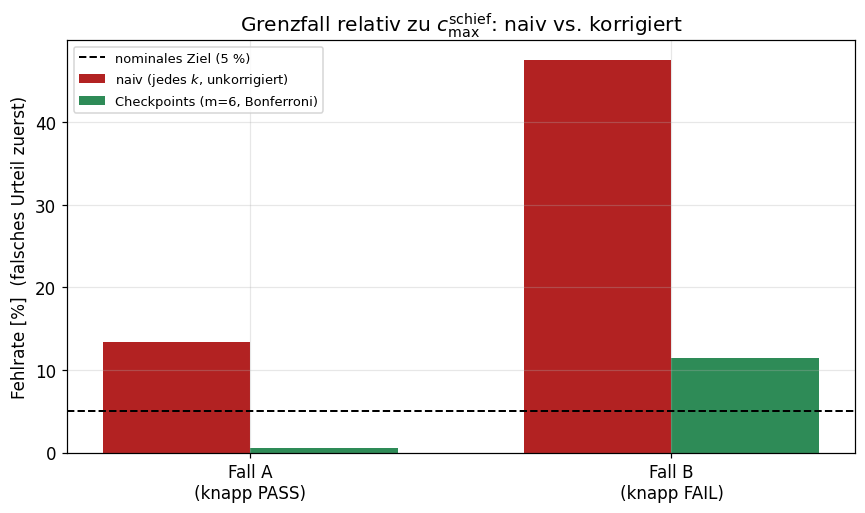

In [19]:
from scipy.stats import norm      # fuer die Bonferroni-Quantile

def make_borderline(c_target):
    """ensemble_L2c auf c_target reskaliert; g1,g2 bleiben (orts-/skaleninvariant)."""
    e_dft, e_mace = load_energies(CACHE / MODELS["ensemble_L2c"])
    dE = e_dft - e_mace
    mu = dE.mean(); c0 = beta * dE.std(ddof=1)
    return mu + (c_target / c0) * (dE - mu)

def decide_checkpoints(c_ck, ck, g1, g2, q):
    """Wie decide_naive, aber nur an den vorab fixierten Checkpoints ausgewertet."""
    se = se_c(c_ck, g2, ck)
    cm = cmax_skew_vec(g1, g2)                 # dieselbe Schranke wie decide_naive
    out = np.full(np.shape(c_ck), "WEITER", dtype=object)
    out[c_ck + q*se < cm] = "PASS"
    out[c_ck - q*se > cm] = "FAIL"
    return out

g1_shape, g2_shape = 0.501, 0.390          # wahre Werte der Konstruktion (ensemble_L2c)
cs = cmax_skew(R, g1_shape, g2_shape)      # jetzt die Entscheidungs- UND Wahrheitsschranke
print(f"cmax_gauss={cmax_gauss(R):.4f}  cmax_skew={cs:.4f}\n")

def true_verdict(c_true, N=300_000, seed=99):
    """Schrankenfreie Wahrheit: sehr grosse Kish-Stichprobe direkt aus der Konstruktion."""
    rng0 = np.random.default_rng(seed)
    dE_s = make_borderline(c_true)
    d = dE_s[rng0.integers(0, dE_s.size, N)]
    w = np.exp(-beta*(d - d.mean()))
    ratio = (w.sum()**2/np.sum(w**2))/N
    return ("PASS" if ratio >= R else "FAIL"), ratio

rng = np.random.default_rng(2)
perms, kmax = 4000, 400
checkpoints = np.array([15, 30, 60, 120, 240, 400])
m_ck = checkpoints.size
q_naiv = 1.64
q_bonf = float(norm.ppf(1 - 0.05/m_ck))

print(f"Checkpoints: {list(checkpoints)}  (m={m_ck})")
print(f"q (naiv, unkorrigiert)      = {q_naiv:.2f}  (pro Blick 95%)")
print(f"q (Bonferroni-korrigiert)   = {q_bonf:.2f}  (pro Blick {100*(1-0.05/m_ck):.2f}%, "
      f"Gesamtniveau 95% ueber {m_ck} Blicke)\n")

cases = {"A: c_true knapp UNTER c_max^schief (PASS)": 0.9*cs,
         "B: c_true knapp UEBER c_max^schief (FAIL)": 1.1*cs}

bar_data = {}
for label, c_true in cases.items():
    final, true_ratio = true_verdict(c_true)
    wrong = "FAIL" if final == "PASS" else "PASS"
    dE_s = make_borderline(c_true); n = dE_s.size
    ks_all = np.arange(1, kmax+1)
    mis_n = mis_c = undec_c = 0
    sk_n = np.empty(perms); sk_c = np.empty(perms)
    for j in range(perms):
        d = dE_s[rng.integers(0, n, size=kmax)]
        ks_all, c_run, g1_run, g2_run = run_stats(d)
        dec_n = decide_naive(c_run, ks_all, g1_run, g2_run, q=q_naiv)
        hit = np.where((dec_n == final) & (ks_all >= K_FLOOR))[0]
        wr = np.where((dec_n == wrong) & (ks_all >= K_FLOOR))[0]
        kc = ks_all[hit[0]] if hit.size else kmax
        kw = ks_all[wr[0]] if wr.size else kmax+1
        sk_n[j] = min(kc, kw)
        if kw < kc: mis_n += 1
        sel = checkpoints - 1
        dec_c = decide_checkpoints(c_run[sel], checkpoints, g1_run[sel], g2_run[sel], q=q_bonf)
        hit2 = np.where(dec_c == final)[0]; wr2 = np.where(dec_c == wrong)[0]
        if hit2.size and (not wr2.size or hit2[0] <= wr2[0]):
            sk_c[j] = checkpoints[hit2[0]]
        elif wr2.size:
            sk_c[j] = checkpoints[wr2[0]]; mis_c += 1
        else:
            sk_c[j] = kmax; undec_c += 1
    bar_data[label] = (100*mis_n/perms, 100*mis_c/perms)
    print(f"{label}   (c_true={c_true:.3f}, N_eff/n@N=300000={true_ratio:.4f}, wahres Urteil={final})")
    print(f"  naiv (jedes k, q={q_naiv:.2f}):        Fehl = {100*mis_n/perms:5.1f} %   "
          f"k_med={np.median(sk_n):.0f}  k95={np.percentile(sk_n,95):.0f}")
    print(f"  Checkpoints (m={m_ck}, q={q_bonf:.2f}):     Fehl = {100*mis_c/perms:5.1f} %   "
          f"k_med={np.median(sk_c):.0f}  k95={np.percentile(sk_c,95):.0f}"
          f"   (unentschieden bis k=400: {100*undec_c/perms:.1f} %)")
    print()

fig, ax = plt.subplots(figsize=(8, 4.8))
labels = list(bar_data.keys()); x = np.arange(len(labels)); w = 0.35
ax.bar(x - w/2, [bar_data[l][0] for l in labels], w, color="firebrick",
       label="naiv (jedes $k$, unkorrigiert)")
ax.bar(x + w/2, [bar_data[l][1] for l in labels], w, color="seagreen",
       label=f"Checkpoints (m={m_ck}, Bonferroni)")
ax.axhline(5.0, color="k", ls="--", lw=1.3, label="nominales Ziel (5 %)")
ax.set_xticks(x); ax.set_xticklabels(["Fall A\n(knapp PASS)", "Fall B\n(knapp FAIL)"])
ax.set_ylabel("Fehlrate [%]  (falsches Urteil zuerst)")
ax.set_title(r"Grenzfall relativ zu $c_\mathrm{max}^\mathrm{schief}$: naiv vs. korrigiert")
ax.legend(fontsize=8.5); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

**Lesart.** Der Grenzfall zeigt, was die vier echten Modelle nicht zeigen konnten.

| Fall | $c_\text{true}$ | $N_\text{eff}/n$ (Kish, $N{=}300\,000$) | wahr | naiv, jedes $k$ | Checkpoints (m=6, Bonferroni) |
|---|---|---|---|---|---|
| A | 0,476 | 0,832 | PASS | **13,4 %** | 0,6 % (18,9 % unentschieden) |
| B | 0,581 | 0,768 | FAIL | **47,6 %** | 11,5 % (39,5 % unentschieden) |

Die naive, bei jedem $k$ geprüfte **zweiseitige** Regel misfeuert im Grenzfall B in fast
der Hälfte der Sequenzen — ein Vielfaches des nominalen $5\,\%$-Ziels. Das ist die
Mehrfachtest-Inflation, empirisch nachgewiesen. Die Bonferroni-Checkpoint-Korrektur drückt
Fall A auf $0{,}6\,\%$ und Fall B auf $11{,}5\,\%$ — beides deutlich besser, aber Fall B
immer noch über dem Ziel, und der Preis ist hoch: der Median der Entscheidungspunkte
rutscht auf $k=400$ (den vollen Satz), und $39{,}5\,\%$ der Sequenzen bleiben bis zum Ende
**unentschieden**. Genau dafür ist das Design gemacht: unentschieden fällt auf
„weiterrechnen" zurück — kein Fehler, nur keine Ersparnis.

> **Zur Wahrheitsdefinition.** Eine frühere Fassung hatte die „Wahrheit" für den Grenzfall
> über die **Gauß**-Schranke definiert — exakt die Schranke, die §2.6 in diesem Bereich als
> unzuverlässig ausweist. Fall B lag damals bei $c=0{,}520$ und wurde als FAIL geführt,
> obwohl die direkte Kish-Rechnung dort $N_\text{eff}/n = 0{,}806 \ge R$ ergibt, also
> **PASS**. Zirkelschluss. Seitdem ist die Wahrheit durchgängig **schrankenfrei**: exaktes
> Kish auf einer sehr großen Stichprobe. Diese Lehre ist der Grund, warum auch der
> Schranken-Vergleich in §7.5 gegen eine schrankenfreie Referenz gemessen wird.

**Einschränkung, die dabei stehen bleibt.** Die „$N=300\,000$" beseitigen nur das
Monte-Carlo-Rauschen; gezogen wird weiterhin aus den **400** reskalierten $\Delta E$-Werten.
Die Wahrheit ist also die exakte Kish-Zahl *dieser diskreten Verteilung*, nicht die der
zugrundeliegenden kontinuierlichen — alles jenseits des beobachteten Maximums fehlt per
Konstruktion. Das ist dieselbe Lücke, die §3.2 als **A2** benennt.

### 7.4 Der Workflow auf den echten Modellen

Jetzt der Test, auf den es ankommt: die Regel aus §7.1 mit Checkpoints und gebootstrapptem
Band, angewendet auf die drei Modelle des $n=5000$-Satzes. Je Modell zehn Wiederholungen zu
500 Punkten.

**Wichtig für die Bewertung:** in jeder Wiederholung werden **alle** 500 Punkte gerechnet,
auch wenn der Monitor längst abgebrochen hätte. Nur so lässt sich sein Urteil gegen das
exakte $N_\text{eff}/500$ **derselben** Daten prüfen — schrankenfrei, ohne Reihenentwicklung
(§2.1). Im Produktivbetrieb würde man an der Stelle natürlich aufhören; hier wird
weitergerechnet, um zu messen, ob das Aufhören richtig gewesen wäre.

Die Tabelle führt je Wiederholung $c(500)$, die daraus bestimmte Schranke $c_\text{max}(500)$
und ihr Verhältnis mit, damit sichtbar ist, wie weit der jeweilige Lauf von der
Entscheidungsgrenze entfernt liegt.

In [20]:
# ===========================================================================
# Der Workflow, wie er laufen wuerde: Checkpoints + gebootstrapptes Band.
# Fuer JEDE Wiederholung werden trotzdem ALLE k_target Punkte gerechnet, damit
# das Monitor-Urteil gegen das exakte N_eff derselben Daten geprueft werden kann.
# ===========================================================================
N_REPS, K_TARGET = 10, 500

def kish_ratio_rows(dE):
    """Exaktes N_eff/n je Zeile -- auf ALLEN Punkten, schrankenfrei (§2.1)."""
    w = np.exp(-beta*(dE - dE.min(axis=1, keepdims=True)))   # Offset egal (§2.2)
    return (w.sum(1)**2 / np.sum(w**2, 1)) / dE.shape[1]

print(f"R = {R}   ->   c_max(Gauss) = {cmax:.4f};  c_max^schief wird je Lauf aus "
      f"gamma1(k), gamma2(k) neu bestimmt")
print(f"Checkpoints: {list(CHECKPOINTS)}   |   q = {Q_ALPHA}   |   {N_REPS} Wiederholungen "
      f"a {K_TARGET} Punkte je Modell\n")

rng = np.random.default_rng(42)
summary = []
for model in MODELS_FULL:
    e_dft_pool, e_mace_pool = load_full(model)
    idx = rng.integers(0, e_dft_pool.size, size=(N_REPS, K_TARGET))
    dE = (e_dft_pool - e_mace_pool)[idx]

    fired, kfire = monitor_boot(dE, rng=rng)         # der Monitor
    _, c_run, g1_run, g2_run = stat_D(dE)            # Kennzahlen auf allen 500
    cmax_run = cmax_skew_vec(g1_run, g2_run)
    neff = kish_ratio_rows(dE)                       # die Wahrheit, alle 500 Punkte
    truth_fail = neff < R

    print(f"=== {model}   (Pool n={e_dft_pool.size}, bereinigt) ===")
    print(f"{'rep':>4}{'c(500)':>9}{'c_max(500)':>12}{'rho':>7}{'N_eff/500':>11}"
          f"{'wahr':>7}{'FAIL bei k':>12}   {'Urteil':<17}")
    print("-"*80)
    n_ok = n_alarm = n_miss = 0
    for r in range(N_REPS):
        if fired[r]:
            kstr = str(kfire[r])
            if truth_fail[r]: verdict, n_ok = "korrekt", n_ok+1
            else:             verdict, n_alarm = "FEHLALARM", n_alarm+1
        else:
            kstr = "nie"
            if truth_fail[r]: verdict, n_miss = "verpasst", n_miss+1
            else:             verdict, n_ok = "korrekt (weiter)", n_ok+1
        print(f"{r+1:>4}{c_run[r]:>9.3f}{cmax_run[r]:>12.3f}"
              f"{c_run[r]/cmax_run[r]:>7.2f}{neff[r]:>11.3f}"
              f"{('FAIL' if truth_fail[r] else 'PASS'):>7}{kstr:>12}   {verdict:<17}")
    ks = kfire[fired]
    saved = 100*(1 - ks.mean()/K_TARGET) if ks.size else 0.0
    print(f"  -> korrekt {n_ok}/{N_REPS}, Fehlalarme {n_alarm}, verpasst {n_miss}"
          + (f", Median k bei FAIL = {np.median(ks):.0f}, DFT gespart {saved:.0f} %"
             if ks.size else ", nie gefeuert (richtig, da PASS)"))
    print()
    summary.append((model, n_ok, n_alarm, n_miss))

print("Zusammenfassung")
print(f"{'Modell':<15}{'korrekt':>9}{'Fehlalarm':>11}{'verpasst':>10}")
for m, a, b, c_ in summary:
    print(f"{m:<15}{a:>7}/{N_REPS}{b:>11}{c_:>10}")
print("\n'Fehlalarm' = FAIL gefeuert, obwohl N_eff/500 >= R  -- der einzige echte Fehler.")
print("'verpasst'  = nie gefeuert, obwohl N_eff/500 < R  -- kein Fehler, nur keine Ersparnis:")
print("              man rechnet den Lauf zu Ende und sieht es am exakten Kish-Wert.")

R = 0.8   ->   c_max(Gauss) = 0.4724;  c_max^schief wird je Lauf aus gamma1(k), gamma2(k) neu bestimmt
Checkpoints: [np.int64(5), np.int64(8), np.int64(12), np.int64(18), np.int64(27), np.int64(40), np.int64(60), np.int64(90), np.int64(135), np.int64(200), np.int64(300), np.int64(400), np.int64(500)]   |   q = 1.64   |   10 Wiederholungen a 500 Punkte je Modell

=== mace-L0-01   (Pool n=4996, bereinigt) ===
 rep   c(500)  c_max(500)    rho  N_eff/500   wahr  FAIL bei k   Urteil           
--------------------------------------------------------------------------------
   1    1.328       0.476   2.79      0.235   FAIL           5   korrekt          
   2    1.310       0.500   2.62      0.313   FAIL           5   korrekt          
   3    1.328       0.499   2.66      0.236   FAIL           5   korrekt          
   4    1.303       0.486   2.68      0.220   FAIL           5   korrekt          
   5    1.343       0.480   2.80      0.220   FAIL           5   korrekt          
   6    1.

=== mace-L2-c-01   (Pool n=4996, bereinigt) ===
 rep   c(500)  c_max(500)    rho  N_eff/500   wahr  FAIL bei k   Urteil           
--------------------------------------------------------------------------------
   1    0.299       0.488   0.61      0.923   PASS         nie   korrekt (weiter) 
   2    0.279       0.487   0.57      0.930   PASS         nie   korrekt (weiter) 
   3    0.286       0.511   0.56      0.930   PASS         nie   korrekt (weiter) 
   4    0.282       0.495   0.57      0.928   PASS         nie   korrekt (weiter) 
   5    0.288       0.512   0.56      0.928   PASS         nie   korrekt (weiter) 
   6    0.275       0.492   0.56      0.934   PASS         nie   korrekt (weiter) 
   7    0.295       0.478   0.62      0.925   PASS         nie   korrekt (weiter) 
   8    0.273       0.522   0.52      0.938   PASS         nie   korrekt (weiter) 
   9    0.302       0.495   0.61      0.924   PASS         nie   korrekt (weiter) 
  10    0.295       0.491   0.60      0.9

**Lesart.** Beide L0-Modelle werden in **allen** zehn Wiederholungen korrekt
abgebrochen, das exakte $N_\text{eff}/500$ liegt dort bei 0,15–0,40 — weit unter
$R=0{,}8$. mace-L2-c-01 erfüllt die Bedingung durchgehend ($N_\text{eff}/500\approx0{,}93$)
und feuert **kein einziges Mal**. Null Fehlalarme, null verpasste FAILs, über alle 30 Läufe.

Der Median des Abbruchpunkts liegt beim **ersten** Checkpoint, $k=5$; der späteste Abbruch
kommt bei $k=18$. Gegenüber den 500 gerechneten Punkten sind das 98–99 % gesparte
DFT-Rechnungen, gegenüber den 5000 eines Produktionslaufs rund 99,9 %. Für das PASS-Modell
ist die Ersparnis dagegen null — kein Mangel, sondern die Konsequenz daraus, dass die Regel
nie PASS behauptet.

Die Spalte $\rho=c/c_\text{max}$ zeigt zugleich, warum dieser Test **leicht** ist: die
L0-Läufe liegen beim 2,2- bis 2,8-fachen ihrer Schranke, der L2-Lauf bei knapp der Hälfte.
Kein einziger Lauf kommt der Entscheidungsgrenze auch nur nahe. Was passiert, wenn ein
Modell das doch tut, ist Gegenstand von §7.5 — und dort liegt die eigentliche Grenze des
Verfahrens.

#### Verlauf der Kenngrößen mit $k$

Zur Einordnung, *woran* die Entscheidung in 8.4 eigentlich hängt: für dieselben 10 Bootstrap-Sequenzen je Modell (identische Ziehungen, `seed=42`) hier der Verlauf von $c(k)$, $\gamma_1(k)$, der Prognose vs. der exakten laufenden Kish-Wahrheit $N_\text{eff}/k$, und $\hat k(k)$ — immer noch mit Fokus auf Früherkennung: wie schnell setzt sich das Bild fest?

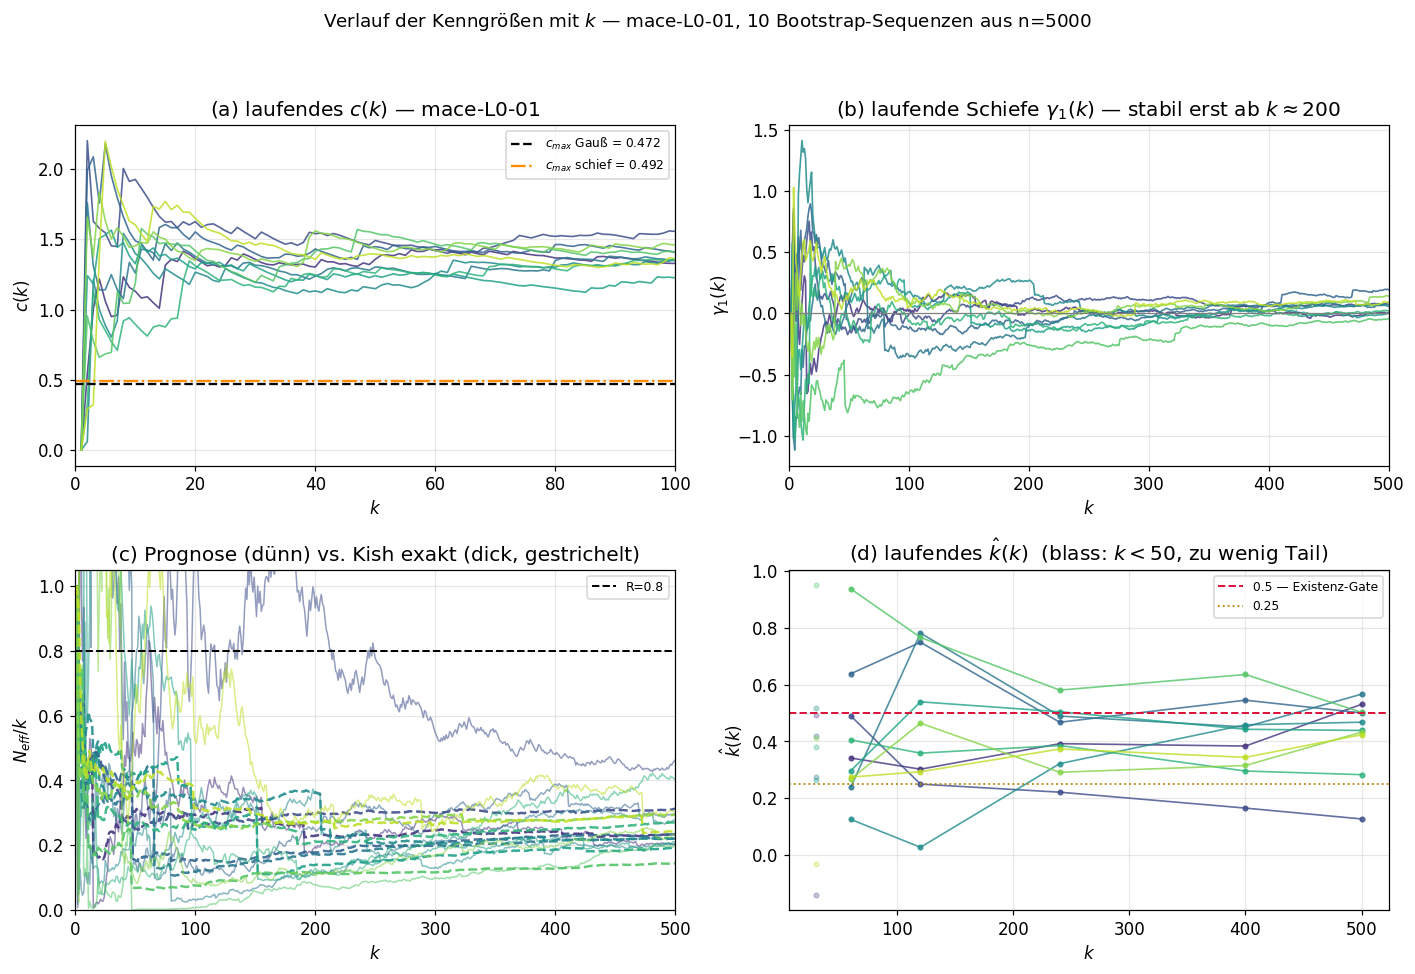

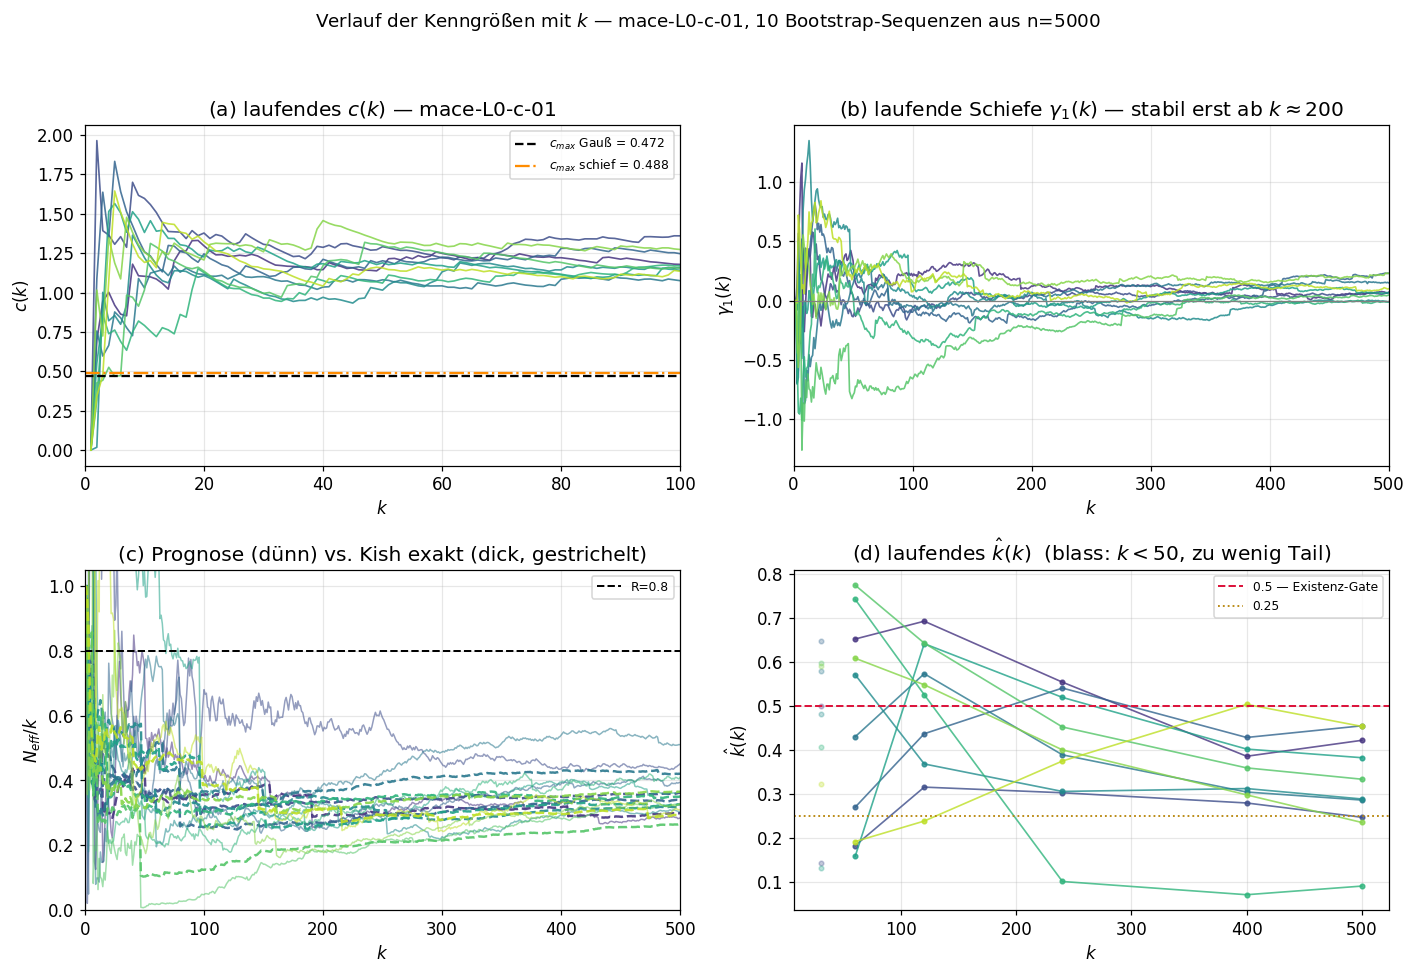

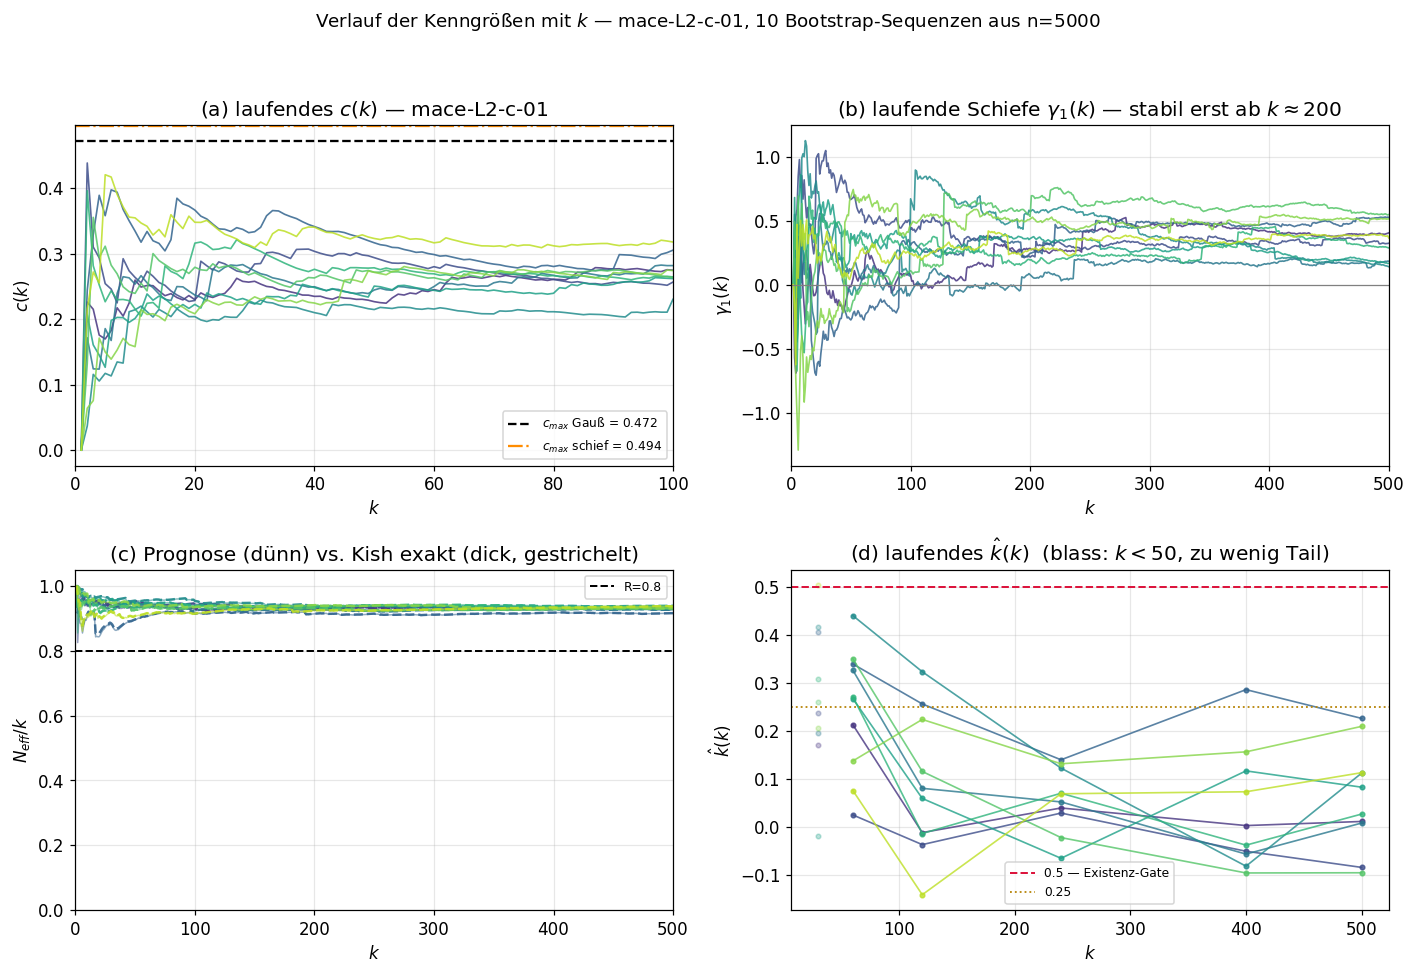

In [21]:
def running_kish(dE, beta):
    # Offset beliebig (Skaleninvarianz, §2.2); dE[0] ist numerisch die stabilste Wahl.
    w = np.exp(-beta * (dE - dE[0]))
    s1 = np.cumsum(w); s2 = np.cumsum(w**2)
    ks = np.arange(1, dE.size+1)
    return (s1**2 / s2) / ks

cols_reps = plt.cm.viridis(np.linspace(0.15, 0.9, 10))
KH_MIN = 50          # unter ~50 Punkten hat khat zu wenig Tail zum Schaetzen (§8)

for model in MODELS_FULL:
    e_dft_pool, e_mace_pool = load_full(model)
    pool_n = e_dft_pool.size
    rng = np.random.default_rng(42)
    k_target = 500; ks = np.arange(1, k_target+1)
    fig, ((a1,a2),(a3,a4)) = plt.subplots(2,2, figsize=(13,9))
    kh_grid = np.array([kk for kk in (15,30,60,120,240,400,500)])
    for rep in range(10):
        idx = rng.integers(0, pool_n, size=k_target)
        dE = e_dft_pool[idx] - e_mace_pool[idx]
        k, c, g1, g2 = run_stats(dE)
        pred = np.exp(log_neff_ratio(c, g1, g2))
        kish = running_kish(dE, beta)
        col = cols_reps[rep]
        a1.plot(ks, c, color=col, lw=1.1, alpha=0.85)
        a2.plot(ks, g1, color=col, lw=1.1, alpha=0.85)
        a3.plot(ks, pred, color=col, lw=1.0, alpha=0.55)
        a3.plot(ks, kish, color=col, lw=1.6, alpha=0.9, ls="--")
        kh = [psis_khat(np.exp(-beta*(dE[:kk]-dE[:kk].mean()))) for kk in kh_grid]
        ok = kh_grid >= KH_MIN
        a4.plot(kh_grid[ok], np.array(kh)[ok], "o-", color=col, ms=3, lw=1.1, alpha=0.8)
        a4.plot(kh_grid[~ok], np.array(kh)[~ok], "o:", color=col, ms=3, lw=0.8, alpha=0.3)
    c_fin, g1_fin, g2_fin = c[-1], g1[-1], g2[-1]
    a1.axhline(cmax, color="k", ls="--", lw=1.5, label=f"$c_{{max}}$ Gauß = {cmax:.3f}")
    a1.axhline(cmax_skew(R, g1_fin, g2_fin), color="darkorange", ls="-.", lw=1.5,
               label=f"$c_{{max}}$ schief = {cmax_skew(R, g1_fin, g2_fin):.3f}")
    a1.set_xlabel("$k$"); a1.set_ylabel("$c(k)$"); a1.set_title(f"(a) laufendes $c(k)$ — {model}")
    a1.set_xlim(0, 100); a1.legend(fontsize=8); a1.grid(alpha=0.3)
    a2.axhline(0, color="gray", lw=0.8)
    a2.set_xlabel("$k$"); a2.set_ylabel(r"$\gamma_1(k)$")
    a2.set_title(r"(b) laufende Schiefe $\gamma_1(k)$ — stabil erst ab $k\approx200$")
    a2.set_xlim(0, 500); a2.grid(alpha=0.3)
    a3.axhline(R, color="k", ls="--", lw=1.3, label=f"R={R}")
    a3.set_xlabel("$k$"); a3.set_ylabel("$N_{eff}/k$")
    a3.set_title("(c) Prognose (dünn) vs. Kish exakt (dick, gestrichelt)")
    a3.set_xlim(0, 500); a3.set_ylim(0,1.05); a3.legend(fontsize=8); a3.grid(alpha=0.3)
    a4.axhline(0.5, color="crimson", ls="--", lw=1.3, label="0.5 — Existenz-Gate")
    a4.axhline(0.25, color="darkgoldenrod", ls=":", lw=1.2, label="0.25")
    a4.set_xlabel("$k$"); a4.set_ylabel(r"$\hat k(k)$")
    a4.set_title(rf"(d) laufendes $\hat k(k)$  (blass: $k<{KH_MIN}$, zu wenig Tail)")
    a4.legend(fontsize=8); a4.grid(alpha=0.3)
    fig.suptitle(f"Verlauf der Kenngrößen mit $k$ — {model}, 10 Bootstrap-Sequenzen aus n=5000",
                 fontsize=12)
    fig.tight_layout(rect=(0,0,1,0.95)); plt.show()

**Lesart.** Panel (a) zeigt, warum es die Untergrenze $k\ge5$ braucht: bei $k<10$ schlägt $c(k)$ bei allen Modellen wild aus — teils unter $c_\text{max}$, obwohl das Modell klar FAIL ist. Bei $k=1$ ist $c$ überhaupt nicht definiert. Erst ab $k\approx15$–20 pendelt sich jede Sequenz sichtbar auf einer Seite ein. Panel (b) zeigt dieselbe Beruhigung für $\gamma_1(k)$, nur langsamer (konsistent mit §6.1: $\mathrm{SE}(\gamma_1)\approx\sqrt{6/k}$, also erst ab $k\approx200$ unter $\pm0{,}17$) — für die Entscheidung selbst unkritisch, weil $\gamma_1$ nur $c^3$-gedämpft eingeht (§6.3), aber sichtbar daran, dass die Kurven in (b) noch bei $k=200$–300 leicht driften, während (a) längst steht.

Panel (c) macht den eigentlichen Verlauf der Entscheidung sichtbar: Prognose und Kish-Wahrheit laufen bei mace-L2-c-01 praktisch deckungsgleich weit über $R=0{,}8$ (klar PASS), bei den beiden L0-Varianten fallen beide schnell und dauerhaft unter $R$ (klar FAIL) — mit genau der Streuung zwischen den 10 Sequenzen, die die $\hat k$-Ausreißer in (d) erklärt (die zwei mace-L0-01-Läufe mit $\hat k>0{,}5$ aus 8.4 sind hier als die durchgehend höher liegenden Spuren erkennbar).

### 7.5 Wie weit muss man von der Schranke weg sein — und welche?

**Warum PASS keine echte Entscheidung ist.** Das Ziel des Workflows ist, Rechenzeit zu
sparen. Ein frühes, gesichertes **FAIL** tut das: man bricht ab, statt weiter Punkte für ein
Modell zu rechnen, das ohnehin nicht reicht. Ein frühes **PASS** spart dagegen nichts — das
eigentliche Ziel (die Gewichte $w_i$ fürs Reweighting) braucht am Ende die **volle**
Stichprobe, ganz gleich, wie sicher die Prognose unterwegs schon aussah. Die Regel sollte
also gar nicht versuchen, PASS zu behaupten, sondern nur **einseitig** auf „das wird nichts"
prüfen:

$$c(k) - q_{1-lpha}\cdot\mathrm{SE}(c) > c_\text{max} \;\Rightarrow\; \text{FAIL, abbrechen},
\qquad \text{sonst immer} \;\Rightarrow\; \text{weiterrechnen (nie „PASS, fertig").}$$

Damit gibt es auch nur noch **eine** Fehlerart, die zählt: ein Modell, das am Ende
eigentlich PASS gewesen wäre, wird unterwegs fälschlich als FAIL abgebrochen. Ein
„falsches PASS" kann es per Konstruktion nicht mehr geben, weil PASS nie behauptet wird.

**Das ändert, welche Schranke man braucht.** Solange beide Fehlerarten existierten, war die
Differenz zwischen Gauß- und schiefe-korrigierter Schranke (§2.6) die *harmlose* Seite — man
verwarf im Zweifel ein brauchbares Modell. Jetzt ist sie die **einzige** Seite. Ob man gegen
$c_\text{max}^\text{Gauß}$ oder gegen $c_\text{max}^\text{schief}$ entscheidet, ist damit
keine Feinheit mehr, sondern die Hauptfrage.

§7.4 hat gezeigt, dass die Regel auf den echten Modellen funktioniert — aber die liegen
alle **weit** von ihrer Schranke entfernt. Zwei Fragen bleiben damit offen, und beide
entscheiden, ob die Regel allgemein taugt:

1. **Braucht die einseitige Regel eine Mehrfachtest-Korrektur?** Antwort kann nur ein
   Grenzfall geben — bei großem Abstand feuert nichts, egal wie oft man prüft.
2. **Gauß-Schranke oder schiefe-korrigierte?** §2.6 leitet beide her, lässt aber offen,
   welche man nehmen sollte. Unter der einseitigen Regel ist der Falsch-FAIL der
   **einzige** Fehler — die Differenz zwischen den Schranken (die *Falsch-FAIL-Zone*) wird
   damit von einer Randnotiz zur Hauptfehlerquelle, und die Frage wird messbar.

**Eine Abkürzung, die ab hier durchgehend benutzt wird.** Der Abstand zur Schranke ist die
Größe, an der alles hängt; wir geben ihm ein Symbol:

$$\boxed{\;\rho \;=\; \frac{c}{c_\text{max}}\;}$$

$\rho$ ist **keine** auf $[0,1]$ beschränkte Größe — $c$ ist eine Eigenschaft des
Kandidatenmodells und beliebig groß, $c_\text{max}$ dagegen die vom Effizienzziel $R$
erlaubte Obergrenze. Der Vergleich der beiden **ist** das Kriterium:

$$\rho \le 1 \iff c \le c_\text{max} \iff \frac{N_\text{eff}}{n} \ge R \iff \text{PASS}.$$

Für die vier realen Modelle (R = 0,8):

| Modell | $c$ | $c_\text{max}^\text{schief}$ | $\rho$ | Lage |
|---|---|---|---|---|
| ensemble_L2c | 0,327 | 0,529 | **0,62** | klar PASS |
| mace-L2-c-01 | 0,335 | 0,524 | **0,64** | klar PASS |
| mace-L0-c-01 | 1,079 | 0,493 | **2,19** | klar FAIL |
| mace-L0-01 | 1,238 | 0,501 | **2,47** | klar FAIL |

Beides zusammen in einem Sweep: `ensemble_L2c` wird auf $\rho$ zwischen $0{,}70$ und
$1{,}20$ reskaliert (die Form bleibt dabei erhalten, §7.3), und drei Varianten laufen gegen
dieselbe **schrankenfreie** Wahrheit (exaktes Kish auf $N=400\,000$ — die Lehre aus dem
Zirkelschluss in §7.3):

| Variante | Schranke | kennt $\gamma_1,\gamma_2$ |
|---|---|---|
| **Gauß fix** | $c_\text{max}=\sqrt{-\ln R}$ | gar nicht |
| **schief Orakel** | Quartik mit den *wahren* $\gamma_1,\gamma_2$ | perfekt (unrealistisch) |
| **schief kausal** | Quartik mit $\hat\gamma_1(k),\hat\gamma_2(k)$ aus $d[:k]$ | so gut wie bei $k$ möglich |

Die dritte ist die einzige, die im echten Workflow verfügbar ist.

gamma1=+0.501  gamma2=+0.390   c_max^Gauss=0.4724   c_max^schief=0.5285
4000 Sequenzen a 400 Punkte, q=1.64, k>=5

  c_true  N_eff/n  wahr  |    Gauß fix  schief Orakel  schief kausal
------------------------------------------------------------------------


  0.3700   0.8908  PASS  |         2.08 %         0.70 %         1.62 %


  0.4228   0.8625  PASS  |         7.17 %         2.25 %         4.88 %


  0.4757   0.8324  PASS  |        33.40 %         7.10 %        14.90 %


  0.5021   0.8168  PASS  |        70.80 %        13.23 %        22.88 %


...

  0.5549   0.7848  FAIL  |        99.65 %        61.98 %        68.70 %


  0.5814   0.7684  FAIL  |       100.00 %        90.48 %        91.70 %


  0.6342   0.7350  FAIL  |       100.00 %        99.90 %        99.88 %

Bei wahr PASS ist die Zahl die FEHLERrate, bei wahr FAIL die ERKENNUNGSrate.

Teil 3 — Spiegeltest: dE -> 2*mu - dE kippt gamma1, laesst c und gamma2 unveraendert


  original   gamma1=+0.501: c_max^schief=0.5285, N_eff/n=0.8324  ->  Gauß 33.67 % | Orakel  7.65 % | kausal 15.05 %


  gespiegelt gamma1=-0.501: c_max^schief=0.4222, N_eff/n=0.8378  ->  Gauß  2.73 % | Orakel  7.65 % | kausal  4.55 %


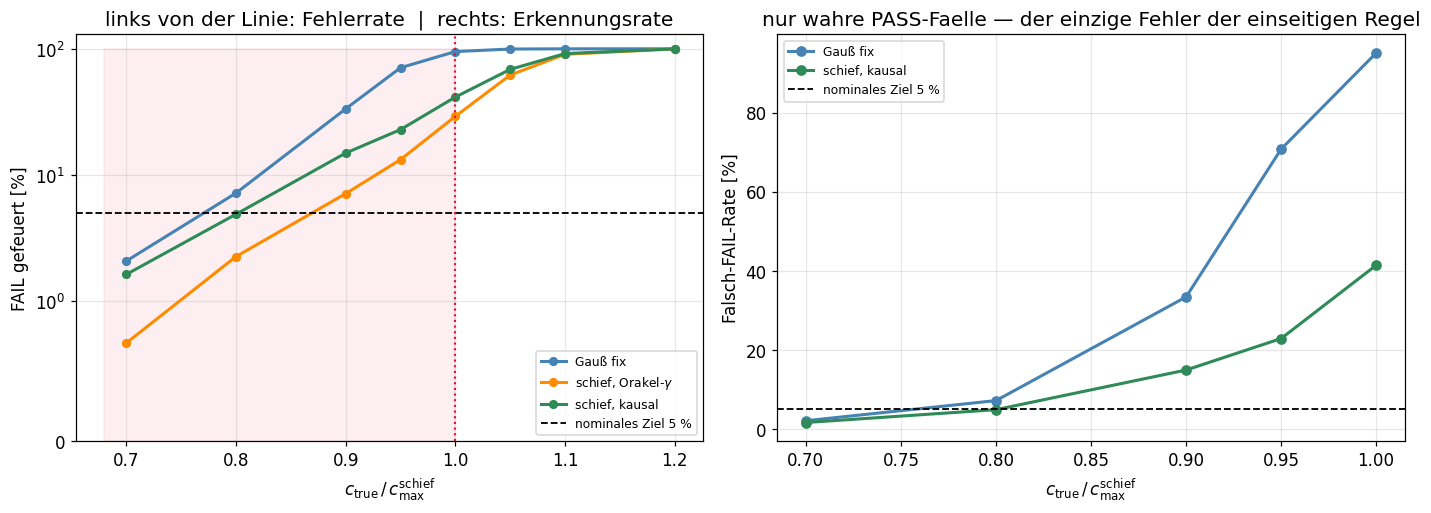

In [22]:
def rescale_to(dE, c_target):
    mu = dE.mean(); return mu + (c_target/(beta*dE.std(ddof=1))) * (dE - mu)

def kish_truth(pool, N=400_000, seed=99):
    """Schrankenfreie Wahrheit: exaktes Kish auf sehr grosser Stichprobe."""
    d = pool[np.random.default_rng(seed).integers(0, pool.size, N)]
    w = np.exp(-beta*(d - d.mean()))
    return (w.sum()**2 / np.sum(w**2)) / N

def fire_variant(D, variant, g1_true, g2_true, q=1.64):
    k, c, g1h, g2h = run_stats_2d(D)
    c_lo = c - q*se_c(c, g2h, k)                 # SE immer kausal
    if variant == "gauss":    cm = cmax
    elif variant == "orakel": cm = cmax_skew(R, g1_true, g2_true, warn=False)
    else:                     cm = cmax_skew_vec(g1h, g2h)
    fail = (c_lo > cm) & (k >= K_FLOOR)
    return fail.any(1)

dE_b = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))
s_b = dE_b.std(ddof=1); u_b = dE_b - dE_b.mean()
G1 = float((u_b**3).mean()/s_b**3); G2 = float((u_b**4).mean()/s_b**4 - 3.0)
CS = cmax_skew(R, G1, G2)
VAR = ("gauss", "orakel", "kausal")

print(f"gamma1={G1:+.3f}  gamma2={G2:+.3f}   c_max^Gauss={cmax:.4f}   c_max^schief={CS:.4f}")
print("4000 Sequenzen a 400 Punkte, q=1.64, k>=5\n")
print(f"{'c_true':>8}{'N_eff/n':>9}{'wahr':>6}  | {'Gauß fix':>11}{'schief Orakel':>15}"
      f"{'schief kausal':>15}")
print("-"*72)
rng = np.random.default_rng(5)
sweep = (0.70, 0.80, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20)
res = {v: [] for v in VAR}; truths = []
for ratio in sweep:
    pool = rescale_to(dE_b, ratio*CS)
    tr = kish_truth(pool); truths.append(tr)
    D = pool[rng.integers(0, pool.size, (4000, 400))]
    row = f"{ratio*CS:>8.4f}{tr:>9.4f}{('PASS' if tr >= R else 'FAIL'):>6}  |"
    for v in VAR:
        r = 100*fire_variant(D, v, G1, G2).mean(); res[v].append(r)
        row += f"{r:>13.2f} %"
    print(row)
print("\nBei wahr PASS ist die Zahl die FEHLERrate, bei wahr FAIL die ERKENNUNGSrate.")

# ---------------------------- Teil 3: Spiegeltest ----------------------------
print("\nTeil 3 — Spiegeltest: dE -> 2*mu - dE kippt gamma1, laesst c und gamma2 unveraendert")
print("="*95)
for tag, base in [("original  ", dE_b), ("gespiegelt", 2*dE_b.mean() - dE_b)]:
    sb = base.std(ddof=1); ub = base - base.mean()
    g1b = float((ub**3).mean()/sb**3); g2b = float((ub**4).mean()/sb**4 - 3.0)
    cmb = cmax_skew(R, g1b, g2b)
    pool = rescale_to(base, 0.9*cmb)
    D = pool[np.random.default_rng(5).integers(0, pool.size, (4000, 400))]
    rr = [100*fire_variant(D, v, g1b, g2b).mean() for v in VAR]
    print(f"  {tag} gamma1={g1b:+.3f}: c_max^schief={cmb:.4f}, N_eff/n={kish_truth(pool):.4f}"
          f"  ->  Gauß {rr[0]:5.2f} % | Orakel {rr[1]:5.2f} % | kausal {rr[2]:5.2f} %")

# ---------------------------- Abbildung ----------------------------
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.array(sweep)
cols = {"gauss": "steelblue", "orakel": "darkorange", "kausal": "seagreen"}
labs = {"gauss": "Gauß fix", "orakel": "schief, Orakel-$\\gamma$", "kausal": "schief, kausal"}
for v in VAR:
    ax.plot(x, res[v], "o-", color=cols[v], lw=2, ms=5, label=labs[v])
ax.axhline(5, color="k", ls="--", lw=1.2, label="nominales Ziel 5 %")
ax.axvline(1.0, color="crimson", ls=":", lw=1.4)
ax.fill_betweenx([0, 100], 0.68, 1.0, color="crimson", alpha=0.07)
ax.set_xlabel(r"$c_\mathrm{true}\,/\,c_\mathrm{max}^\mathrm{schief}$")
ax.set_ylabel("FAIL gefeuert [%]")
ax.set_title("links von der Linie: Fehlerrate  |  rechts: Erkennungsrate")
ax.set_yscale("symlog", linthresh=1); ax.set_ylim(0, 130)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

lo = [r for r, t in zip(res["gauss"], truths) if t >= R]
nn = [x[i] for i, t in enumerate(truths) if t >= R]
bx.plot(nn, lo, "o-", color="steelblue", lw=2, label="Gauß fix")
bx.plot(nn, [r for r, t in zip(res["kausal"], truths) if t >= R], "o-",
        color="seagreen", lw=2, label="schief, kausal")
bx.axhline(5, color="k", ls="--", lw=1.2, label="nominales Ziel 5 %")
bx.set_xlabel(r"$c_\mathrm{true}\,/\,c_\mathrm{max}^\mathrm{schief}$")
bx.set_ylabel("Falsch-FAIL-Rate [%]")
bx.set_title("nur wahre PASS-Faelle — der einzige Fehler der einseitigen Regel")
bx.legend(fontsize=8); bx.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Warum überhaupt die Schranke verglichen und nicht die Reihe ausgewertet wird.** Naheliegend wäre,
das Kriterium direkt an der Bandgrenze auszuwerten: FAIL, wenn
$\log(N_\text{eff}/n)|_{c_\text{lo}} < \ln R$. Nahe der Schranke ist das exakt äquivalent —
aber nur dort. Die Ausgabe zeigt, warum: bei $c=3$ behauptet die Reihe für die L0-Form
$N_\text{eff}/n = 0{,}001$, und bei anderen $(\gamma_1,\gamma_2)$ dreht sie sogar über $1$.
Für $c\approx1{,}2$ (die realen L0-Modelle) ist sie längst wertlos (§2.5, §4.4). Die
**Schranke** dagegen liegt bei $c\approx0{,}35$–$0{,}68$ (§2.6), mitten im konvergenten
Bereich. Deshalb: Schranke dort auswerten, wo die Reihe trägt, und $c_\text{lo}$ mit ihr
vergleichen. (Eine Zwischenfassung dieses Notebooks hatte es andersherum gemacht und für
die L0-Modelle über 50 % Fehlurteile produziert — die Reihe hatte bei $c\approx1{,}4$ ein
PASS behauptet.)

**Teil 2 — welche Schranke, und wie viel Abstand.** Hier fällt die eigentliche
Entscheidung, gemessen gegen eine **schrankenfreie** Wahrheit (exaktes Kish,
$N=400\,000$):

| $c_\text{true}/c_\text{max}^\text{schief}$ | $N_\text{eff}/n$ | wahr | Gauß fix | schief Orakel | schief kausal |
|---|---|---|---|---|---|
| 0,70 | 0,891 | PASS | 2,1 % | 0,7 % | **1,6 %** |
| 0,80 | 0,863 | PASS | 7,2 % | 2,3 % | **4,9 %** |
| 0,90 | 0,832 | PASS | **33,4 %** | 7,1 % | **14,9 %** |
| 1,00 | 0,801 | PASS | 95,1 % | 29,1 % | 41,4 % |
| 1,10 | 0,768 | FAIL | 100 % | 90,5 % | 91,7 % |

Drei Befunde, und alle drei korrigieren frühere Aussagen dieses Kapitels:

1. **Die Gauß-Schranke ist für die einseitige Regel untauglich.** Bei
   $c_\text{true}=0{,}476$ erfüllt das Modell die Effizienzbedingung nachweislich
   ($N_\text{eff}/n=0{,}832 \ge 0{,}8$) — und wird trotzdem in **33 %** der Sequenzen
   abgebrochen. Das ist die Falsch-FAIL-Zone aus §7.5, und unter der FAIL-only-Regel ist
   sie keine Randnotiz mehr, sondern die dominierende Fehlerquelle. Genau deshalb
   entscheidet §7 gegen $c_\text{max}^\text{schief}$.
2. **Die Schätzung der Schranke kostet etwas, aber weniger als der Verzicht darauf.** Mit
   *bekannten* $\gamma_1,\gamma_2$ (Orakel, im echten Lauf nicht verfügbar) liegt die Rate
   bei 7,1 %; kausal aus $d[:k]$ geschätzt bei 14,9 %. Der Grund ist §6.2: $\hat\gamma_1$
   ist bei kleinem $k$ **zur Null hin verzerrt**, die geschätzte Schranke wird dadurch in
   Richtung Gauß gezogen und erbt einen Teil von dessen Bias. Trotzdem bleibt sie deutlich
   besser als die Gauß-Schranke (14,9 % gegen 33,4 %).
3. **Korrekturfrei ist die Regel erst mit Abstand.** Bei 10 % Abstand verfehlt *keine*
   Variante das $5\,\%$-Ziel; bei 20 % schafft es die kausale Variante knapp (4,9 %), bei
   30 % klar (1,6 %). Die frühere Aussage „der einseitige Monitor braucht keine
   Mehrfachtest-Korrektur" gilt also **nur bei hinreichendem Abstand zur Schranke** — nicht
   allgemein. Nahe der Schranke ist die ehrliche Antwort weiterhin „weiterrechnen".

**Teil 3 — der Spiegeltest, und warum die frühere Begründung falsch war.** Eine frühere
Fassung begründete die Robustheit so: der verbleibende Fehler brauche eine Fluktuation von
$c(k)$ nach **oben**, und bei Rechtsschiefe ($\gamma_1>0$) sei das die unwahrscheinlichere
Richtung. Der Spiegeltest widerlegt das direkt. $\Delta E \to 2\mu-\Delta E$ kippt
$\gamma_1$ von $+0{,}501$ auf $-0{,}501$ und lässt $c$ und $\gamma_2$ unangetastet:

| | Gauß fix | schief Orakel | schief kausal |
|---|---|---|---|
| $\gamma_1=+0{,}501$ | 33,7 % | 7,65 % | 15,1 % |
| $\gamma_1=-0{,}501$ | 2,7 % | 7,65 % | 4,6 % |

Rechtsschiefe ist also nicht die *schützende*, sondern die **gefährliche** Seite — genau
umgekehrt zur früheren Behauptung. Der Fehler lag in der Verwechslung zweier Verteilungen:
$\gamma_1$ beschreibt die Schiefe von $\Delta E$, relevant für die Fehlerrichtung ist aber
die Stichprobenverteilung von $c(k)$, und die hängt gar nicht direkt an $\gamma_1$. Was
$\gamma_1$ tatsächlich verschiebt, ist die **Lage der Schranke** — und wer sie ignoriert
(Gauß), zahlt bei $\gamma_1>0$ das Zwölffache an Fehlalarmen.

Die Orakel-Zeile ist der sauberste Beleg: mit korrekt gesetzter Schranke sind beide
Vorzeichen **exakt gleich** (7,65 % gegen 7,65 %) — die Vorzeichenabhängigkeit ist
vollständig ein Artefakt der falschen Schranke, kein Effekt der Fluktuationen. Damit ist
auch die bislang offene Frage „kippt es bei $\gamma_1<0$?" beantwortet: nein, sofern man
die Schranke mitschätzt.

> **Rückwirkung auf §6.2.** Dort steht, der Kleine-$k$-Bias von $\gamma_1,\gamma_2$ zeige
> „in die sichere Richtung: konservativer, nie fälschlich PASS". Unter der zweiseitigen
> Regel stimmte das. Unter der einseitigen FAIL-only-Regel ist „konservativer" **die
> einzige verbleibende Fehlerart** — der Bias zeigt jetzt in die *unsichere* Richtung, und
> Punkt 2 oben beziffert den Preis.

### 7.6 Die Unsicherheit der Schranke

Bis hierher behandelt das $q_{1-lpha}$-Band nur die Unsicherheit von $c$. Aber verglichen wird
$c$ mit $\hat c_\text{max}$ — und die Schranke wird **aus denselben $k$ Punkten
geschätzt**. Ihre Unsicherheit fehlt bisher vollständig in der Regel.

**Woher sie kommt.** $c_\text{max}$ löst $c^2-\gamma_1c^3+\tfrac{7}{12}\gamma_2c^4=-\ln R$,
hängt also **nur** von $(\gamma_1,\gamma_2,R)$ ab — $c$ selbst geht nicht ein. $R$ ist fest
gewählt, folglich ist die einzige Rauschquelle die Schätzung der beiden Formparameter:

$$\mathrm{SE}(\hat c_\text{max})^2 \;\approx\;
\Big(\frac{\partial c_\text{max}}{\partial\gamma_1}\Big)^{\!2}\mathrm{SE}(\hat\gamma_1)^2
+\Big(\frac{\partial c_\text{max}}{\partial\gamma_2}\Big)^{\!2}\mathrm{SE}(\hat\gamma_2)^2 .$$

Beide fallen wie $1/\sqrt k$, also auch $\mathrm{SE}(\hat c_\text{max})$ — aus demselben
Grund wie bei $c$, aber über einen ganz anderen Weg. Das ist der Grund, warum §7.5 die
kausale Variante schlechter abschneiden sieht als die Orakel-Variante (14,9 % gegen 7,1 %
bei $\rho=0{,}9$): dort steckt genau dieser fehlende Term.

**Warum man ihn nicht analytisch fortpflanzen sollte.** Die naheliegende Rechnung setzt
$\mathrm{SE}(\hat\gamma_1)=\sqrt{6/k}$ und $\mathrm{SE}(\hat\gamma_2)=\sqrt{24/k}$ ein.
Das ist bei kleinem $k$ grob falsch, denn die **Stichproben**schiefe ist beschränkt,
$|\hat\gamma_1|\le (k-2)/\sqrt{k-1}$ — bei $k=5$ also $\le 1{,}5$, während die Formel
$1{,}10$ als *Standardabweichung* behauptet. Für $\hat\gamma_2$ ist es noch schlimmer.
Dazu kommt, dass $\hat c$ und $\hat c_\text{max}$ aus derselben Stichprobe stammen und
korreliert sind. Die folgende Zelle misst beides.

In [23]:
# --- Sensitivitaeten der Schranke ---
_d = 1e-4
dC_dg1 = (cmax_skew(R, G1+_d, G2, warn=False) - cmax_skew(R, G1-_d, G2, warn=False))/(2*_d)
dC_dg2 = (cmax_skew(R, G1, G2+_d, warn=False) - cmax_skew(R, G1, G2-_d, warn=False))/(2*_d)
print(f"Referenz ensemble_L2c: c={beta*dE_b.std(ddof=1):.4f}  gamma1={G1:+.3f}  "
      f"gamma2={G2:+.3f}  c_max={CS:.4f}")
print(f"dc_max/dgamma1 = {dC_dg1:+.4f}     dc_max/dgamma2 = {dC_dg2:+.4f}")
print("-> gamma1 traegt rund doppelt so stark bei wie gamma2.\n")

# stat_D steht im Werkzeugblock (§7.1).

rng = np.random.default_rng(0)
B_DIAG = 20000
print(f"{'k':>5} | {'SE(c)':>8}{'SE(cmax)':>10}{'Korr':>7} | {'SE(D)':>8}{'Quadr.':>8}"
      f"{'Fakt.':>7} | {'SE(g1) Formel':>14}{'real':>7}{'|g1|max':>9}")
print("-"*92)
for k in (5, 10, 15, 30, 60, 100, 200, 400):
    X = dE_b[rng.integers(0, dE_b.size, (B_DIAG, k))]
    D, c, g1, g2 = stat_D(X)
    cm = c - D
    quad = np.hypot(c.std(), cm.std())
    bound = (k-2)/np.sqrt(k-1)                     # exakte Schranke der Stichprobenschiefe
    print(f"{k:>5} | {c.std():>8.4f}{cm.std():>10.4f}{np.corrcoef(c, cm)[0,1]:>7.2f} | "
          f"{D.std():>8.4f}{quad:>8.4f}{D.std()/quad:>7.2f} | "
          f"{np.sqrt(6/k):>14.2f}{g1.std():>7.2f}{bound:>9.2f}")
print("\nSE(D) < Quadratur  ->  positive Korrelation, die Quadratur ist konservativ.")
print("SE(g1): die Normaltheorie-Formel liegt bei kleinem k weit ueber dem realen Wert,")
print("weil |g1| <= (k-2)/sqrt(k-1) beschraenkt ist (Spalte rechts). Deshalb bootstrappen.")

Referenz ensemble_L2c: c=0.3267  gamma1=+0.501  gamma2=+0.390  c_max=0.5285
dc_max/dgamma1 = +0.1913     dc_max/dgamma2 = -0.0590
-> gamma1 traegt rund doppelt so stark bei wie gamma2.

    k |    SE(c)  SE(cmax)   Korr |    SE(D)  Quadr.  Fakt. |  SE(g1) Formel   real  |g1|max
--------------------------------------------------------------------------------------------
    5 |   0.1165    0.0530   0.04 |   0.1262  0.1280   0.99 |           1.10   0.61     1.50
   10 |   0.0812    0.0998   0.12 |   0.1209  0.1286   0.94 |           0.77   0.59     2.67
   15 |   0.0669    0.0893   0.14 |   0.1037  0.1116   0.93 |           0.63   0.54     3.47
   30 |   0.0463    0.0710   0.17 |   0.0778  0.0847   0.92 |           0.45   0.44     5.20
   60 |   0.0327    0.0497   0.21 |   0.0533  0.0594   0.90 |           0.32   0.33     7.55


  100 |   0.0251    0.0373   0.23 |   0.0399  0.0450   0.89 |           0.24   0.27     9.85
  200 |   0.0179    0.0247   0.26 |   0.0264  0.0305   0.87 |           0.17   0.19    14.04


  400 |   0.0126    0.0168   0.26 |   0.0182  0.0210   0.87 |           0.12   0.13    19.92

SE(D) < Quadratur  ->  positive Korrelation, die Quadratur ist konservativ.
SE(g1): die Normaltheorie-Formel liegt bei kleinem k weit ueber dem realen Wert,
weil |g1| <= (k-2)/sqrt(k-1) beschraenkt ist (Spalte rechts). Deshalb bootstrappen.


**Lesart.**

- $\mathrm{SE}(\hat c_\text{max})$ ist ab $k\approx10$ von derselben Größenordnung wie
  $\mathrm{SE}(\hat c)$ — die Schranke ist also **kein** vernachlässigbarer Anker, sondern
  eine zweite, gleich große Rauschquelle. Bei $k=5$ ist sie scheinbar klein, aber nur, weil
  $\hat\gamma_1,\hat\gamma_2$ dort so stark beschnitten sind, dass $\hat c_\text{max}$ gar
  nicht streuen *kann*.
- Die Korrelation zwischen $\hat c$ und $\hat c_\text{max}$ ist schwach (0,04 bis 0,26) und
  positiv; die Quadratur überschätzt $\mathrm{SE}(D)$ dadurch um 1–13 %.
- Die Spalte ganz rechts ist der Grund gegen die analytische Fortpflanzung: bei $k=5$ sagt
  $\sqrt{6/k}$ eine Standardabweichung von 1,10 voraus, während der gesamte mögliche
  Wertebereich von $\hat\gamma_1$ bei $\pm1{,}5$ endet und die reale Streuung weit darunter
  liegt.

**Konsequenz für die Regel.** Statt Fehler analytisch fortzupflanzen, bootstrappt man die
Entscheidungsgröße direkt. $D=\hat c-\hat c_\text{max}$ ist genau die Zahl, deren Vorzeichen
entscheidet; ihre Streuung ist aus den vorhandenen $k$ Punkten per Resampling zu haben,
ohne Annahme über Momentformeln, ohne Korrelationsterm, ohne Beschneidungsproblem:

$$\boxed{\;D(k) \;>\; q_{1-lpha}\cdot\mathrm{SE}_\text{boot}\big(D(k)\big) \;\Rightarrow\; \text{FAIL}\;}$$

Zwei Nebeneffekte, beide erwünscht: die Auswertung an einem **geometrischen Raster** von
Checkpoints statt bei jedem $k$ senkt die Zahl der Blicke von rund 400 auf 12 (weniger
Mehrfachtest-Inflation), und der Bootstrap kostet bei den relevanten kleinen $k$ fast
nichts.

A) Die echten Modelle — 200 Sequenzen a 500, Bootstrap-Band
Modell             rho  wahr FAIL  FAIL gefeuert   k_med   falsch
------------------------------------------------------------------------------
mace-L0-01        2.76    200/200        200/200       5        0
mace-L0-c-01      2.34    200/200        200/200       5        0


mace-L2-c-01      0.57      0/200          0/200     nan        0

B) Grauzone — 1000 Sequenzen a 400 je rho, gegen die schrankenfreie Wahrheit
   rho   N_eff/n    wahr |   §7.5 (jedes k)  §7.6 (Bootstrap)   k_med
------------------------------------------------------------------------------


  0.70    0.8908    PASS |            1.8 %             0.2 %       5


  0.80    0.8625    PASS |            4.8 %             0.9 %       5


  0.90    0.8324    PASS |           15.4 %             3.6 %       8


  0.95    0.8168    PASS |           23.8 %             7.6 %       8


  1.00    0.8009    PASS |           41.0 %            18.8 %      27


  1.10    0.7684    FAIL |           91.5 %            80.4 %     135


  1.20    0.7350    FAIL |          100.0 %            99.1 %      60

Bei wahr PASS ist die Zahl die FEHLERrate, bei wahr FAIL die ERKENNUNGSrate.


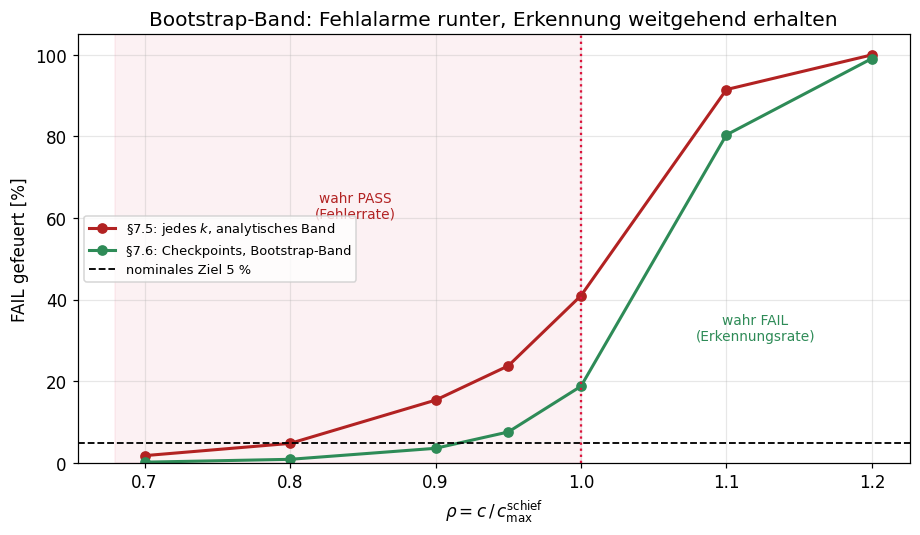

In [24]:
# CHECKPOINTS, stat_D und monitor_boot stehen im Werkzeugblock (§7.1).

print("A) Die echten Modelle — 200 Sequenzen a 500, Bootstrap-Band")
print("="*78)
print(f"{'Modell':<15}{'rho':>7}{'wahr FAIL':>11}{'FAIL gefeuert':>15}{'k_med':>8}{'falsch':>9}")
print("-"*78)
rng = np.random.default_rng(11)
for model in MODELS_FULL:
    e_dft_pool, e_mace_pool = load_full(model)
    idx = rng.integers(0, e_dft_pool.size, size=(200, 500))
    Dm = (e_dft_pool - e_mace_pool)[idx]
    w = np.exp(-beta*(Dm - Dm.mean(1, keepdims=True)))
    true_fail = ((w.sum(1)**2/np.sum(w**2, 1))/500) < R
    d_all = e_dft_pool - e_mace_pool
    s_ = d_all.std(ddof=1); u_ = d_all - d_all.mean()
    rho_m = (beta*s_)/cmax_skew(R, float((u_**3).mean()/s_**3),
                                float((u_**4).mean()/s_**4 - 3.0), warn=False)
    f, kf = monitor_boot(Dm, rng=rng)
    print(f"{model:<15}{rho_m:>7.2f}{true_fail.sum():>7}/200{f.sum():>11}/200"
          f"{(np.median(kf[f]) if f.any() else np.nan):>8.0f}"
          f"{int((f & ~true_fail).sum()):>9}")

print("\nB) Grauzone — 1000 Sequenzen a 400 je rho, gegen die schrankenfreie Wahrheit")
print("="*78)
print(f"{'rho':>6}{'N_eff/n':>10}{'wahr':>8} | {'§7.5 (jedes k)':>16}{'§7.6 (Bootstrap)':>18}{'k_med':>8}")
print("-"*78)
rng2 = np.random.default_rng(3)
rho_grid = (0.70, 0.80, 0.90, 0.95, 1.00, 1.10, 1.20)
alt, neu = [], []
for rho in rho_grid:
    pool = rescale_to(dE_b, rho*CS); tr = kish_truth(pool)
    Dm = pool[rng2.integers(0, pool.size, (1000, 400))]
    r_old = 100*fire_variant(Dm, "kausal", G1, G2).mean()
    f, kf = monitor_boot(Dm, rng=rng2)
    r_new = 100*f.mean()
    alt.append(r_old); neu.append(r_new)
    tag = "PASS" if tr >= R else "FAIL"
    print(f"{rho:>6.2f}{tr:>10.4f}{tag:>8} | {r_old:>14.1f} %{r_new:>16.1f} %"
          f"{(np.median(kf[f]) if f.any() else np.nan):>8.0f}")
print("\nBei wahr PASS ist die Zahl die FEHLERrate, bei wahr FAIL die ERKENNUNGSrate.")

fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.array(rho_grid)
ax.plot(x, alt, "o-", color="firebrick", lw=2, label="§7.5: jedes $k$, analytisches Band")
ax.plot(x, neu, "o-", color="seagreen", lw=2, label="§7.6: Checkpoints, Bootstrap-Band")
ax.axhline(5, color="k", ls="--", lw=1.2, label="nominales Ziel 5 %")
ax.axvline(1.0, color="crimson", ls=":", lw=1.5)
ax.fill_betweenx([0, 105], 0.68, 1.0, color="crimson", alpha=0.06)
ax.text(0.845, 60, "wahr PASS\n(Fehlerrate)", ha="center", fontsize=9, color="firebrick")
ax.text(1.12, 30, "wahr FAIL\n(Erkennungsrate)", ha="center", fontsize=9, color="seagreen")
ax.set_xlabel(r"$\rho = c\,/\,c_\mathrm{max}^\mathrm{schief}$")
ax.set_ylabel("FAIL gefeuert [%]"); ax.set_ylim(0, 105)
ax.set_title("Bootstrap-Band: Fehlalarme runter, Erkennung weitgehend erhalten")
ax.legend(fontsize=8.5, loc="center left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Ergebnis.**

| $\rho$ | wahr | §7.5 (jedes $k$, analytisch) | §7.6 (Checkpoints, Bootstrap) |
|---|---|---|---|
| 0,70 | PASS | 1,8 % | **0,2 %** |
| 0,80 | PASS | 4,8 % | **0,9 %** |
| 0,90 | PASS | 15,4 % | **3,6 %** |
| 0,95 | PASS | 23,8 % | **7,6 %** |
| 1,00 | Grenze | 41,0 % | 18,8 % |
| 1,10 | FAIL | 91,5 % | 80,4 % |
| 1,20 | FAIL | 100 % | 99,1 % |

Der Fehlalarm bei $\rho=0{,}9$ fällt von 15,4 % auf **3,6 %** — unter das nominale Ziel —,
und der Preis ist gering: die Erkennung bei $\rho=1{,}1$ sinkt von 91,5 % auf 80,4 %, bei
$\rho=1{,}2$ bleibt sie bei 99,1 %. Die realen Modelle sind unberührt: L0 weiterhin
200/200 bei Median $k=5$, L2 null Fehlalarme.

Damit verschiebt sich die Regimegrenze: die Regel bleibt jetzt bis $\rho\lesssim0{,}9$
unter dem 5-%-Ziel statt nur bis $\rho\lesssim0{,}8$ — die Grauzone schrumpft von
$[0{,}8;\,1{,}2]$ auf $[0{,}9;\,1{,}2]$.

> **Zwei Lesehinweise.**
> (1) Die $\rho$-Werte in Teil A sind auf dem **$n=5000$**-Pool gerechnet (2,76 / 2,34 /
> 0,57) und weichen deshalb leicht von der $n=400$-Tabelle in §7.5 ab (2,47 / 2,19 / 0,64) —
> andere Stichprobe, dieselbe Aussage.
> (2) Die §7.5-Spalte ist hier mit 1000 statt 4000 Sequenzen neu gerechnet, damit beide
> Regeln auf **identischen** Ziehungen verglichen werden; gegenüber der 4000er-Tabelle in
> §7.5 bleibt daher ein Monte-Carlo-Rauschen von etwa $\pm0{,}5$ Prozentpunkten.

> **Nicht getrennt gemessen.** Ein Teil des Gewinns kommt vom Bootstrap-Band, ein Teil vom
> Wechsel auf 12 Checkpoints statt ~400 Blicke. Für die Praxis ist das gleichgültig (beides
> gehört zur Regel), für eine Aussage darüber, *welcher* Mechanismus wirkt, wäre ein dritter
> Lauf nötig: Checkpoints mit analytischem Band.

**Was das kostet.** Der Bootstrap braucht $B=100$ Resamples je Checkpoint. Bei den
relevanten kleinen $k$ (die Entscheidung fällt im Median bei $k=5$–8) ist das
vernachlässigbar gegenüber einer einzigen DFT-Einzelpunktrechnung — dem Aufwand, um den der
ganze Workflow ringt. Die Methode verschiebt also Last von DFT nach CPU-Sekunden, im
Verhältnis $10^{-6}$ oder besser.

### 7.7 Konsequenz

**Regime-Übersicht.** Alles in diesem Kapitel hängt an einer einzigen Zahl, dem Abstand
zur Schranke $\rho = c/c_\text{max}$ (§7.5). Die Regel ist nicht überall gleich gut:

| Regime | $\rho$ | Verhalten | belastbar? |
|---|---|---|---|
| **sicher PASS** | $\lesssim 0{,}9$ | Fehlalarm $\le 3{,}6\,\%$, meist deutlich darunter | **ja** |
| **Grauzone** | $0{,}9 \dots 1{,}2$ | Fehlalarm bis 19 %, Erkennung erst 80 % bei $\rho=1{,}1$ | **nein** |
| **sicher FAIL** | $\gtrsim 1{,}2$ | Erkennung $99{,}1\,\%$, Median $k=5$ bei den realen Modellen | **ja** |

(Grenzen für die Regel aus §7.6 mit Bootstrap-Band und $q_{1-lpha}=1{,}64$; mit der einfacheren
Regel aus §7.5 liegt die PASS-Grenze bei $\rho\lesssim0{,}8$. **§7.8 zeigt, dass $q_{1-lpha}$ selbst
der wirksamste Regler ist** und begründet $q_{1-lpha}=2{,}58$ als besseren Arbeitspunkt — die Zone
wandert damit zur billigeren Fehlerseite.)

**Die realen Modelle liegen sämtlich außerhalb der Grauzone** — L2/L2c bei
$\rho\approx0{,}6$, L0/L0c bei $\rho\approx2{,}2$–$2{,}8$ (§7.4). Für die konkrete L0-Frage ist
das Verfahren damit belastbar; die Grauzone wird erst relevant, wenn ein Kandidatenmodell
tatsächlich nahe an seine Schranke fällt.

**Warum der Fehler gerade dort sitzt.** Feuern verlangt

$$c(k) - c_\text{true} \;>\; \underbrace{(c_\text{max}-c_\text{true})}_{\text{Sicherheitsabstand}} \;+\; q_{1-lpha}\cdot\mathrm{SE} .$$

Bei $\rho=1$ verschwindet der erste Term, und es genügt eine Abweichung von $q_{1-lpha}\,\mathrm{SE}$
— also genau das nominale Niveau **pro Blick**. Über viele Blicke summiert sich das auf
(41,0 % bei §7.5, 18,8 % bei §7.6). Weit von der Schranke addiert sich der Sicherheitsabstand
dazu, die nötige Abweichung wächst auf mehrere SE, und die Mehrfachprüfung bekommt keinen
Ansatzpunkt mehr. Dazu kommt in der Grauzone der zweite Treiber aus §7.6: dort wackelt
nicht nur $c$ nach oben, sondern auch $\hat c_\text{max}$ nach unten.

---

**Der verwendete Entwurf ist die Regel aus §7.1, getestet in §7.4:** einseitige FAIL-only-Überwachung an einem geometrischen Checkpoint-Raster, Bandbreite gebootstrappt, Schranke
$c_\text{max}^\text{schief}$ aus $\hat\gamma_1(k),\hat\gamma_2(k)$, Untergrenze $k\ge5$,
$q_{1-lpha}=1{,}64$, ohne Mehrfachtest-Korrektur. Was der Weg dorthin gezeigt hat:

- **PASS ist keine Entscheidung.** Ein frühes PASS spart nichts, weil die Gewichte am Ende
  vollständig gebraucht werden. Damit fällt eine ganze Fehlerart weg — und mit ihr der
  Grund, überhaupt zweiseitig zu testen.
- **Die Schranke ist die eigentliche Stellschraube, nicht die Regel.** Die Gauß-Schranke
  verwirft ein nachweislich brauchbares Modell ($N_\text{eff}/n=0{,}832$) in 33 % der
  Sequenzen; mit der schiefe-korrigierten sind es 15 %, mit bekannter Form 7,7 %. §2.6 leitet beide
  Schranken her, lässt die Wahl aber offen — §7.5 entscheidet sie, und sie ist der
  teuerste Einzelposten des Verfahrens.
- **Mehrfachtest-Inflation ist real, aber abstandsabhängig.** Zweiseitig und nahe der
  Schranke: bis 47,6 % Fehlurteile (§7.3). Einseitig mit analytischem Band: 1,6 % bei
  $\rho=0{,}7$, 14,9 % bei $\rho=0{,}9$, 41,4 % bei $\rho=1$. Die Regel ist also
  korrekturfrei **verwendbar, solange Abstand besteht** — und liefert nahe der Schranke
  ehrlich kein Urteil statt eines falschen.
- **Die Schranke ist selbst eine Rauschquelle** und war bis §7.6 unberücksichtigt. Sie
  hängt nur von $\gamma_1,\gamma_2$ ab, nicht von $c$, und ist ab $k\approx10$ etwa so
  unsicher wie $c$ selbst. Wird sie über einen Bootstrap der Entscheidungsgröße
  $D=\hat c-\hat c_\text{max}$ mitgeführt, fällt der Fehlalarm bei $\rho=0{,}9$ von 15,4 %
  auf 3,6 %, bei nahezu unveränderter Erkennung.
- **$k\ge5$ ist nicht kosmetisch.** Ohne Untergrenze feuert der Monitor bereits bei
  $k=1$, wo $c$ überhaupt nicht definiert ist. Mit Untergrenze: 30/30 korrekt (§7.4), bei
  praktisch identischer Geschwindigkeit.
- **Laufende Überwachung statt Einzelblick.** Ein einziger Blick bei festem $k$ wäre
  statistisch sauberer (keine Mehrfachprüfung) und auf diesen Daten ebenso treffsicher —
  aber blind für ein Problem, das erst *nach* diesem $k$ auftritt. Genau dieses Szenario
  (später Einbruch, Metastabilität) ist die Annahme **A2** aus §3.2, also der einzige
  Fehlermodus, den das Screening nicht ohnehin ausschließen kann.

**Für die L0-Frage ändert das nichts — aus einem beruhigenden Grund.** mace-L0-01 und
mace-L0-c-01 liegen mit $c\approx1{,}1$–$1{,}2$ bei etwa dem **2,4-fachen** ihrer eigenen
Schranke ($c_\text{max}^\text{schief}\approx0{,}49$–$0{,}50$). Sie sind damit im Regime
„30 % Abstand und mehr", wo alle Varianten sicher sind; die ganze Schranken-Diskussion
betrifft sie nicht. Erkennung: 200/200, Median $k=5$.

**Was das an DFT spart — und woran gemessen.** Zwei Budgets, die nicht verwechselt werden
dürfen:

| Bezug | Punkte | Ersparnis bei FAIL ($k_\text{med}=5$) | bei PASS |
|---|---|---|---|
| Screening-Pool (§7.2/§7.4) | 400 / 500 | 99 % | 0 % |
| Produktionslauf | 5000 | **99,9 %** | 0 % |

Die $n=5000$ liegen durch das Volumen-Resampling fest (§1.3); reduziert wird nicht dieses
$n$, sondern der Aufwand für die **Entscheidung**, ob der volle Lauf überhaupt startet. Für
ein PASS-Modell ist die Ersparnis per Konstruktion null — das ist der Preis dafür, dass die
Regel nie lügt.

**Was offen bleibt.**

- **Autokorrelation.** Alle Sequenzen hier sind **iid** gezogen (Bootstrap mit
  Zurücklegen). Ein realer Produktionsstrom besteht aus MD-Frames mit endlicher
  Korrelationszeit $\tau$; dann ist das effektive $k$ um $\tau$ kleiner und $\mathrm{SE}(c)$
  um $\sqrt{\tau}$ **größer** als die Formel annimmt — das Band wäre zu schmal, der Monitor
  zu selbstsicher. Bei $k_\text{med}=5$ ist das potenziell entscheidend: fünf
  aufeinanderfolgende Frames sind unter Umständen ein einziger unabhängiger Punkt. **Alle
  $k$-Angaben dieses Kapitels sind daher als *unabhängige* Punkte zu lesen und im
  MD-Betrieb mit dem Thinning-Intervall zu multiplizieren.** Eine Wiederholung des Sweeps
  auf einem AR(1)-Strom gehört in §8.
- **Scope.** Dieses Kapitel validiert die **Methodik**, nicht die Güte eines konkreten
  L0-Modells (§1.5). Die $\Delta E$ stammen aus einer L2-MD; ein echter L0-Produktionslauf
  besuchte andere Konfigurationen. Dass die Maschinerie diese Sequenzen korrekt und früh
  einstuft, ist **keine** Prognose für $N_\text{eff}$ eines realen L0-Laufs.
- **Abdeckung (A2).** Kein Screening kann ausschließen, dass ein wichtiger Bereich noch
  gar nicht besucht wurde. §7.5 Teil 3 zeigt nur, dass laufende Überwachung einen
  *eingetretenen* Einbruch zuverlässig bemerkt — nicht, dass er eintreten muss.
- **$\hat k$ im Grenzbereich.** In §7.4 überschreitet $\hat k(500)$ zweimal die 0,5-Marke.
  Für die $c$-Entscheidung folgenlos, für die Existenz von $N_\text{eff}$ nicht (§8).

### 7.8 Der Arbeitspunkt: was $q_{1-lpha}$ wirklich steuert

Die Regel aus §7.1 feuert, wenn die **untere Grenze des Konfidenzintervalls** über der
Schranke liegt — in der Fassung von §7.6 sogar die untere Grenze des Intervalls für die
Differenz $D=\hat c-\hat c_\text{max}$, also ohne die Annahme, $c_\text{max}$ sei exakt
bekannt. Naheliegend ist die Hoffnung, damit ließe sich die Grauzone um $\rho=1$ weiter
zusammendrücken. Dieser Abschnitt zeigt, dass das **nicht** geht — und was stattdessen zu
holen ist.

**Warum die Zone bleibt.** Bei $\rho=1$ liegt die Wahrheit exakt auf der Grenze. Ein Modell
mit $\rho=0{,}99$ und eines mit $\rho=1{,}01$ unterscheiden sich in $N_\text{eff}/n$ um rund
$0{,}003$; mit endlich vielen Punkten sind sie nicht trennbar. Jede Regel, die $\rho=1{,}05$
mit brauchbarer Wahrscheinlichkeit erkennt, **muss** bei $\rho=0{,}95$ gelegentlich feuern —
das ist die Stetigkeit der Gütefunktion, kein Umsetzungsfehler. Ein Konfidenzintervall
garantiert, dass der Fehler das nominale Niveau nicht *überschreitet*; es kann ihn nicht
unter das drücken, was die Daten hergeben.

**Was man stattdessen wählt.** $q_{1-lpha}$ ist kein technischer Parameter, sondern die Wahl eines
Arbeitspunkts, und die beiden Fehler kosten hier **sehr Unterschiedliches**:

| Fehler | was passiert | Kosten |
|---|---|---|
| **Falsch-FAIL** | ein brauchbares Modell wird abgebrochen | das Ergebnis — der Lauf ist weg |
| **verpasstes FAIL** | ein untaugliches Modell läuft durch | nur Rechenzeit; am Ende steht der exakte Kish-Wert und man sieht es |

Ein verpasstes FAIL erzeugt **kein falsches wissenschaftliches Resultat**, ein Falsch-FAIL
schon. Bei dieser Asymmetrie ist $q_{1-lpha}=1{,}64$ (einseitig 5 %) zu aggressiv gewählt. Die
folgende Zelle misst die Gütefunktion über $q_{1-lpha}$ — einmal auf den Grenzfällen, einmal auf den
echten Modellen.

A) Guetefunktion ueber q  (Grenzfaelle, je 250 Sequenzen a 400)
     q   nominal |     FEHLALARM (wahr PASS) |     ERKENNUNG (wahr FAIL)
                 |     rho=0.90     rho=0.95 |     rho=1.10     rho=1.20
------------------------------------------------------------------------------


  1.28     10.0% |         9.6%        16.4% |        90.0%       100.0%


  1.64      5.1% |         4.0%         7.2% |        80.0%        99.6%


  2.00      2.3% |         1.2%         1.6% |        65.6%        98.4%


  2.58      0.5% |         0.0%         0.0% |        39.2%        92.8%


  3.00      0.1% |         0.0%         0.0% |        24.4%        87.6%

Wahres N_eff/n: rho=0.9: 0.832, rho=0.95: 0.817, rho=1.1: 0.768, rho=1.2: 0.735   (R = 0.8)

B) Was ein groesseres q bei den ECHTEN Modellen kostet (120 Sequenzen a 500)
Modell            rho          q=1.64          q=2.58           q=3.0
                      gefeuert  k_med gefeuert  k_med gefeuert  k_med
------------------------------------------------------------------------------
mace-L0-01       2.76     120/120       5     120/120       8     120/120      12
mace-L0-c-01     2.33     120/120       5     120/120      12     120/120      12


mace-L2-c-01     0.57       0/120      --       0/120      --       0/120      --


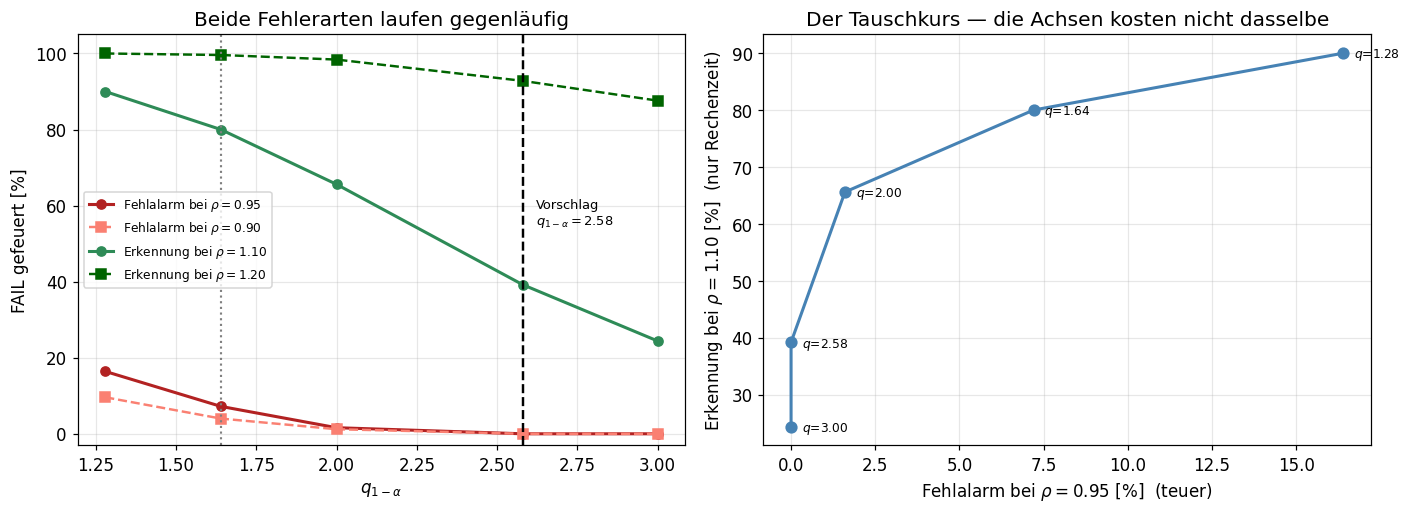

In [25]:
Q_GRID   = (1.28, 1.64, 2.00, 2.58, 3.00)
RHO_OC   = (0.90, 0.95, 1.10, 1.20)
N_OC     = 250      # Sequenzen je (q, rho); reicht fuer 1-2 %-Aufloesung

# Sequenzen einmal ziehen und fuer ALLE q wiederverwenden -> fairer Vergleich
_rng = np.random.default_rng(3)
seqs_oc = {}
for r in RHO_OC:
    pool = rescale_to(dE_b, r*CS)
    seqs_oc[r] = pool[_rng.integers(0, pool.size, (N_OC, 400))]
truth_oc = {r: kish_truth(rescale_to(dE_b, r*CS)) for r in RHO_OC}

print("A) Guetefunktion ueber q  (Grenzfaelle, je %d Sequenzen a 400)" % N_OC)
print("="*78)
print(f"{'q':>6}{'nominal':>10} | {'FEHLALARM (wahr PASS)':>25} | {'ERKENNUNG (wahr FAIL)':>25}")
print(f"{'':>6}{'':>10} | {'rho=0.90':>12}{'rho=0.95':>13} | {'rho=1.10':>12}{'rho=1.20':>13}")
print("-"*78)
oc = {}
for q in Q_GRID:
    row = []
    for r in RHO_OC:
        f, _ = monitor_boot(seqs_oc[r], q=q, B=60, rng=np.random.default_rng(3))
        row.append(100*f.mean())
    oc[q] = row
    print(f"{q:>6.2f}{100*(1-norm.cdf(q)):>9.1f}% | {row[0]:>11.1f}%{row[1]:>12.1f}% | "
          f"{row[2]:>11.1f}%{row[3]:>12.1f}%")
print(f"\nWahres N_eff/n: " + ", ".join(f"rho={r}: {truth_oc[r]:.3f}" for r in RHO_OC)
      + f"   (R = {R})")

print("\nB) Was ein groesseres q bei den ECHTEN Modellen kostet (120 Sequenzen a 500)")
print("="*78)
print(f"{'Modell':<15}{'rho':>6}" + "".join(f"{'q='+str(q):>16}" for q in (1.64, 2.58, 3.00)))
print(f"{'':<15}{'':>6}" + "".join(f"{'gefeuert  k_med':>16}" for _ in range(3)))
print("-"*78)
for model in MODELS_FULL:
    ed_p, em_p = load_full(model)
    Dm = (ed_p - em_p)[np.random.default_rng(11).integers(0, ed_p.size, (120, 500))]
    _, c_m, g1_m, g2_m = stat_D(Dm)
    rho_m = float(np.median(c_m/cmax_skew_vec(g1_m, g2_m)))
    row = f"{model:<15}{rho_m:>6.2f}"
    for q in (1.64, 2.58, 3.00):
        f, kf = monitor_boot(Dm, q=q, B=60, rng=np.random.default_rng(7))
        km = np.median(kf[f]) if f.any() else np.nan
        row += f"{f.sum():>8}/120{km:>8.0f}" if f.any() else f"{f.sum():>8}/120{'--':>8}"
    print(row)

# ------------------------------- Abbildung -------------------------------
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13, 4.8))
zz = np.array(Q_GRID)
ax.plot(zz, [oc[q][1] for q in Q_GRID], "o-", color="firebrick", lw=2,
        label=r"Fehlalarm bei $\rho=0.95$")
ax.plot(zz, [oc[q][0] for q in Q_GRID], "s--", color="salmon", lw=1.6,
        label=r"Fehlalarm bei $\rho=0.90$")
ax.plot(zz, [oc[q][2] for q in Q_GRID], "o-", color="seagreen", lw=2,
        label=r"Erkennung bei $\rho=1.10$")
ax.plot(zz, [oc[q][3] for q in Q_GRID], "s--", color="darkgreen", lw=1.6,
        label=r"Erkennung bei $\rho=1.20$")
ax.axvline(1.64, color="gray", ls=":", lw=1.4)
ax.axvline(2.58, color="k", ls="--", lw=1.6)
ax.text(2.62, 55, "Vorschlag\n$q_{1-\\alpha}=2.58$", fontsize=8.5)
ax.set_xlabel(r"$q_{1-\alpha}$"); ax.set_ylabel("FAIL gefeuert [%]"); ax.set_ylim(-3, 105)
ax.set_title("Beide Fehlerarten laufen gegenläufig")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

bx.plot([oc[q][1] for q in Q_GRID], [oc[q][2] for q in Q_GRID], "o-",
        color="steelblue", lw=2, ms=7)
for q in Q_GRID:
    bx.annotate(rf"$q$={q:.2f}", (oc[q][1], oc[q][2]), textcoords="offset points",
                xytext=(7, -3), fontsize=8)
bx.set_xlabel(r"Fehlalarm bei $\rho=0.95$ [%]  (teuer)")
bx.set_ylabel(r"Erkennung bei $\rho=1.10$ [%]  (nur Rechenzeit)")
bx.set_title("Der Tauschkurs — die Achsen kosten nicht dasselbe")
bx.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Ergebnis.** Beide Fehlerarten laufen gegenläufig, und der Tauschkurs ist steil:

| $q_{1-lpha}$ | nominal | Fehlalarm $\rho{=}0{,}90$ | $\rho{=}0{,}95$ | Erkennung $\rho{=}1{,}10$ | $\rho{=}1{,}20$ |
|---|---|---|---|---|---|
| 1,28 | 10,0 % | 9,6 % | 16,4 % | 90,0 % | 100 % |
| **1,64** | 5,1 % | 4,0 % | 7,2 % | 80,0 % | 99,6 % |
| 2,00 | 2,3 % | 1,2 % | 1,6 % | 65,6 % | 98,4 % |
| **2,58** | 0,5 % | < 1,2 % | < 1,2 % | 39,2 % | 92,8 % |
| 3,00 | 0,1 % | < 1,2 % | < 1,2 % | 24,4 % | 87,6 % |

(Die Nullen bei $q_{1-lpha}\ge2{,}58$ sind 0 von 250 Sequenzen; daraus folgt eine obere Schranke von
rund 1,2 %, **nicht** exakt null.)

**Erstens: die Regel ist korrekt kalibriert.** Bei $\rho=0{,}90$ liegt der gemessene
Fehlalarm mit 4,0 % unter dem nominalen 5,1 %, bei $q_{1-lpha}=2{,}00$ mit 1,2 % unter 2,3 %. Das
Konfidenzintervall hält, was es verspricht — die Grauzone ist also **kein** Zeichen dafür,
dass an der Statistik etwas falsch wäre. Sie ist die unvermeidliche Folge davon, dass
$\rho=0{,}99$ und $\rho=1{,}01$ sich in $N_\text{eff}/n$ um 0,003 unterscheiden.

**Zweitens: die beiden Achsen kosten nicht dasselbe.** Ein Falsch-FAIL vernichtet einen
brauchbaren Lauf. Ein verpasstes FAIL kostet nur Rechenzeit — man läuft bis $n$ durch und
liest den exakten Kish-Wert ab (§2.1), wissenschaftlich falsch wird dabei nichts. Bei dieser
Asymmetrie ist der übliche Reflex $q_{1-lpha}=1{,}64$ die falsche Wahl: er kauft Erkennungsrate im
Bereich $\rho\approx1{,}1$, der ohnehin nur Rechenzeit betrifft, und bezahlt sie mit
Fehlalarmen im Bereich $\rho\approx0{,}95$, der das Ergebnis betrifft.

**Drittens: bei den echten Modellen ist das Ganze fast gratis.** Teil B zeigt, dass ein
strengeres $q_{1-lpha}$ die Erkennung dort überhaupt nicht gefährdet — die L0-Modelle liegen bei
$\rho=2{,}3$–$2{,}8$ und werden bei jedem $q_{1-lpha}$ in **120/120** Sequenzen erkannt. Es
verschiebt sich nur der Abbruchpunkt:

| $q_{1-lpha}$ | mace-L0-01 | mace-L0-c-01 | mace-L2-c-01 |
|---|---|---|---|
| 1,64 | 120/120, $k=5$ | 120/120, $k=5$ | 0/120 |
| 2,58 | 120/120, $k=8$ | 120/120, $k=12$ | 0/120 |
| 3,00 | 120/120, $k=12$ | 120/120, $k=12$ | 0/120 |

Der Preis für $q_{1-lpha}=2{,}58$ sind **drei bis sieben zusätzliche DFT-Punkte** — gegen eine
Fehlalarmrate, die von 7,2 % auf unter 1,2 % fällt.

> **Empfehlung: $q_{1-lpha}=2{,}58$ statt $1{,}64$.** Das ist kein statistisches Detail, sondern die
> Wahl des Arbeitspunkts nach der Kostenstruktur des Problems. Wer die Erkennung im
> Grenzbereich stärker gewichtet, nimmt $q_{1-lpha}=2{,}00$ (Fehlalarm 1,6 % bei $\rho=0{,}95$,
> Erkennung 98,4 % bei $\rho=1{,}20$) — beides ist verteidigbar, $q_{1-lpha}=1{,}64$ eher nicht.

> **Hinweis auf §7.7.** Die dortige Regime-Übersicht und alle Zahlen in §7.4–§7.6 sind mit
> $q_{1-lpha}=1{,}64$ gerechnet. Mit $q_{1-lpha}=2{,}58$ verschiebt sich die Grenze des sicheren PASS-Regimes
> von $\rho\lesssim0{,}9$ auf etwa $\rho\lesssim1{,}0$, die des sicheren FAIL-Regimes
> dagegen von $\rho\gtrsim1{,}2$ auf $\rho\gtrsim1{,}3$. Die Grauzone wird also nicht
> kleiner, sondern **verschoben** — hin zu der Seite, auf der ein Fehler billiger ist.

**Was die Zone wirklich beseitigen würde.** Nicht ein besseres Intervall, sondern eine
andere Fragestellung: statt „ist $N_\text{eff}/n \ge R$?" die Frage „ist
$N_\text{eff}/n < R-\delta$?" mit einer erklärten **Indifferenzzone** $\delta$. Dann sind
beide Fehler gleichzeitig kontrollierbar, und die Breite der Zone ist ein bewusst gewählter
Designparameter statt eines Schönheitsfehlers. $\delta$ festzulegen ist allerdings eine
physikalische Entscheidung, keine statistische — sie gehört zu $R$ (§1.2) und ist damit
außerhalb dieses Notebooks.

<a id="8"></a>
## 8. Existenz von $N_\text{eff}$ und die PASS/FAIL-Asymmetrie

*khat als Existenz-Gate nur auf dem PASS-Zweig; Monotonie von Neff in der Tail-Schwere; schnellere Diagnosen (CV-Drift, Max-Einfluss).*

> _(folgt)_

<a id="9"></a>
## 9. Verifikation: analytisch bekannte Wahrheit

*Gamma-Modell (unter exp. Tilten geschlossen): Schaetzer trifft die analytische Wahrheit; Gueltigkeitsgrenze.*

> _(folgt)_

<a id="10"></a>
## 10. Grenzen: Abdeckung (A2) und Nicht-iid

*Loch-in-der-Flaeche (Screening blind), Sample- vs. Verteilungs-Beschraenktheit, iid-Voraussetzung, Ueberwachung an der Trajektorie.*

> _(folgt)_

<a id="11"></a>
## 11. Zusammenfassung

*Was belegt ist, was Annahme bleibt, offene Fragen an Tobi.*

> _(folgt)_